# Weekend Shape as Top-Down Disaggregation

Forecast task: for each eligible wide/commercial release, forecast the opening-weekend daily revenue allocation across Friday, Saturday, and Sunday using only information available at forecast origin $d$, where $d \in \{-14,\ldots,-1\}$.

The late-regime forecast already supplies the aggregate opening-weekend forecast $\widehat{OW}_{i,d}$. This notebook treats weekend shape as a top-down disaggregation problem:

$$\widehat{Fri}_{i,d} + \widehat{Sat}_{i,d} + \widehat{Sun}_{i,d} = \widehat{OW}_{i,d}$$

The shape target is the daily share vector:

$$\mathbf{s}_i=(s_{Fri,i},s_{Sat,i},s_{Sun,i})$$

where:

$$s_{Fri,i}=\frac{Fri_i}{OW_i}, \qquad s_{Sat,i}=\frac{Sat_i}{OW_i}, \qquad s_{Sun,i}=\frac{Sun_i}{OW_i}$$

and $s_{Fri,i}+s_{Sat,i}+s_{Sun,i}=1$.

The immediate goal is not three independent daily revenue forecasts. It is to forecast the opening-weekend profile conditional on the opening-weekend total forecast. The first model family is deliberately non-parametric: historical profile proportions with chronological validation.

In [110]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "pm-box-office-matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", os.path.join(tempfile.gettempdir(), "pm-box-office-cache"))

repo_root = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

from pm_box_office.db.connection import connect_database

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Parameters

The first pass uses one row per release. Eligibility is intentionally close to the late-forecast universe: clean opening-weekend actuals, positive Friday/Saturday/Sunday grosses, non-pandemic release years, and either a wide release or a published commercial estimate.

In [111]:
DIAGNOSTICS_DIR = repo_root / "data" / "diagnostics"
LATE_CONSENSUS_PATH = DIAGNOSTICS_DIR / "late_forecast_consensus_benchmark.csv"
LATE_BY_ORIGIN_PATH = DIAGNOSTICS_DIR / "late_forecast_by_origin_common_predictions.csv"
LATE_DAILY_ORIGIN_PATH = DIAGNOSTICS_DIR / "late_forecast_daily_origin_panel.csv"

EXCLUDED_RELEASE_YEARS = {2020, 2021}
WIDE_RELEASE_THEATER_THRESHOLD = 600
VERY_LARGE_ESTIMATE_USD = 75_000_000
MIN_TRAIN_MOVIES = 50
MIN_GROUP_N = 20
DOC_CONCERT_MIN_N = 15
ROLLING_TEST_START_YEAR = 2023
PROFILE_DAYS = ["Friday", "Saturday", "Sunday"]

np.random.seed(17)


## Load EDA Opening Table

Run `eda/create_plotting_tables.py` first if `analytics.eda_movie_openings` is stale or missing.

In [112]:
openings_sql = """
SELECT
    release_run_id,
    movie_id,
    title,
    opening_date,
    opening_weekend_start,
    release_year,
    release_month,
    release_week_of_year,
    season_bucket,
    market,
    release_type,
    release_width_bucket,
    is_wide_release,
    is_large_release,
    genre,
    distributor,
    franchise,
    is_franchise,
    mpa_rating,
    opening_weekend_theaters,
    production_budget_usd,
    latest_estimate_mid_usd,
    estimate_count,
    estimate_source_count,
    wiki_views_cume_to_m1,
    rt_fresh_share,
    rt_prerelease_review_count,
    opening_weekend_gross_usd,
    friday_gross_usd,
    saturday_gross_usd,
    sunday_gross_usd,
    opening_weekend_reported_days
FROM analytics.eda_movie_openings
WHERE opening_weekend_gross_usd IS NOT NULL
"""

conn = connect_database()
try:
    openings = pd.read_sql_query(openings_sql, conn.raw)
finally:
    conn.close()

for col in ["opening_date", "opening_weekend_start"]:
    openings[col] = pd.to_datetime(openings[col], errors="coerce")

bool_cols = ["is_wide_release", "is_large_release", "is_franchise"]
for col in bool_cols:
    openings[col] = openings[col].fillna(False).astype(bool)

money_cols = [
    "opening_weekend_gross_usd", "friday_gross_usd", "saturday_gross_usd", "sunday_gross_usd",
    "opening_weekend_theaters", "production_budget_usd", "latest_estimate_mid_usd",
]
for col in money_cols:
    openings[col] = pd.to_numeric(openings[col], errors="coerce")

openings.shape


/var/folders/9w/tkd5myg15nqbl66qxtspnnf80000gn/T/ipykernel_15877/3410382836.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  openings = pd.read_sql_query(openings_sql, conn.raw)


(3087, 32)

## Build `shape_base`

The main representation uses Saturday as the stabilizing denominator:

$$a_i=\log(Fri_i/Sat_i), \qquad b_i=\log(Sun_i/Sat_i)$$

Recovering shares from $(a,b)$ uses a three-part softmax with Saturday as the reference category:

$$\widehat{s}_{Sat}=\frac{1}{1+\exp(\widehat{a})+\exp(\widehat{b})}$$

$$\widehat{s}_{Fri}=\frac{\exp(\widehat{a})}{1+\exp(\widehat{a})+\exp(\widehat{b})}, \qquad
\widehat{s}_{Sun}=\frac{\exp(\widehat{b})}{1+\exp(\widehat{a})+\exp(\widehat{b})}$$

In [113]:
def text_contains(df, columns, pattern):
    text = pd.Series("", index=df.index, dtype="object")
    for col in columns:
        if col in df.columns:
            text = text + " " + df[col].fillna("").astype(str)
    return text.str.contains(pattern, case=False, regex=True, na=False)


def normalize_profile(row_or_series):
    values = np.asarray(row_or_series, dtype=float)
    total = np.nansum(values)
    if not np.isfinite(total) or total <= 0:
        return np.full_like(values, np.nan, dtype=float)
    return values / total


def shares_from_ab(a, b):
    ea = np.exp(a)
    eb = np.exp(b)
    denom = 1.0 + ea + eb
    return pd.Series({
        "pred_friday_share": ea / denom,
        "pred_saturday_share": 1.0 / denom,
        "pred_sunday_share": eb / denom,
    })


def dollars(x):
    return f"${x:,.0f}" if pd.notna(x) else ""

shape_base = openings.loc[
    openings["opening_weekend_gross_usd"].gt(0)
    & openings["friday_gross_usd"].gt(0)
    & openings["saturday_gross_usd"].gt(0)
    & openings["sunday_gross_usd"].gt(0)
    & ~openings["release_year"].isin(EXCLUDED_RELEASE_YEARS)
    & (
        openings["is_wide_release"]
        | openings["latest_estimate_mid_usd"].notna()
        | openings["opening_weekend_theaters"].ge(WIDE_RELEASE_THEATER_THRESHOLD)
    )
].copy()

if "opening_weekend_reported_days" in shape_base.columns:
    shape_base = shape_base.loc[shape_base["opening_weekend_reported_days"].fillna(0).ge(3)].copy()

shape_base["s_fri"] = shape_base["friday_gross_usd"] / shape_base["opening_weekend_gross_usd"]
shape_base["s_sat"] = shape_base["saturday_gross_usd"] / shape_base["opening_weekend_gross_usd"]
shape_base["s_sun"] = shape_base["sunday_gross_usd"] / shape_base["opening_weekend_gross_usd"]
shape_base["share_sum"] = shape_base[["s_fri", "s_sat", "s_sun"]].sum(axis=1)
shape_base["front_loaded"] = shape_base["s_fri"] - shape_base["s_sat"]
shape_base["log_fri_sat"] = np.log(shape_base["friday_gross_usd"] / shape_base["saturday_gross_usd"])
shape_base["log_sun_sat"] = np.log(shape_base["sunday_gross_usd"] / shape_base["saturday_gross_usd"])

text_cols = ["title", "genre", "release_type", "franchise", "distributor"]
shape_base["is_action"] = text_contains(shape_base, ["genre"], r"\baction\b|adventure|superhero")
shape_base["is_horror"] = text_contains(shape_base, ["genre", "title"], r"\bhorror\b|thriller")
shape_base["is_family_animation"] = text_contains(shape_base, ["genre", "title"], r"animation|animated|family|kids")
shape_base["is_doc_concert"] = text_contains(shape_base, text_cols, r"documentary|concert|music documentary|live concert|special event|event cinema|fan event")
shape_base["is_holiday_corridor"] = (
    shape_base["season_bucket"].eq("holiday")
    | shape_base["release_month"].isin([11, 12])
    | shape_base["release_week_of_year"].isin([47, 48, 49, 50, 51, 52, 53, 1])
)
shape_base["is_very_large_estimate"] = shape_base["latest_estimate_mid_usd"].ge(VERY_LARGE_ESTIMATE_USD)
shape_base["is_fan_driven"] = (
    shape_base["is_franchise"]
    | shape_base["is_action"]
    | shape_base["is_horror"]
    | shape_base["is_very_large_estimate"]
)
shape_base["is_holiday_family"] = shape_base["is_holiday_corridor"] & shape_base["is_family_animation"]
shape_base["is_other_wide"] = ~(shape_base["is_doc_concert"] | shape_base["is_holiday_family"] | shape_base["is_fan_driven"])

shape_base["broad_segment"] = np.select(
    [
        shape_base["is_doc_concert"],
        shape_base["is_holiday_family"],
        shape_base["is_fan_driven"],
        shape_base["is_family_animation"] | shape_base["is_holiday_corridor"],
    ],
    ["doc/concert", "holiday family", "fan-driven", "family/holiday"],
    default="other wide",
)

shape_base["estimate_size_group"] = np.where(
    shape_base["is_very_large_estimate"], "very large estimate", "smaller/unknown estimate"
)
shape_base["franchise_group"] = np.where(shape_base["is_franchise"], "franchise/IP", "non-franchise")
shape_base["action_horror_group"] = np.where(shape_base["is_action"] | shape_base["is_horror"], "action/horror", "other")
shape_base["holiday_group"] = np.where(shape_base["is_holiday_corridor"], "holiday corridor", "ordinary weekend")
shape_base["family_group"] = np.where(shape_base["is_family_animation"], "family/animation", "other")
shape_base["doc_concert_group"] = np.where(shape_base["is_doc_concert"], "documentary/concert", "normal theatrical")
shape_base["critic_score_bucket"] = pd.cut(
    shape_base["rt_fresh_share"],
    bins=[-0.01, 0.4, 0.7, 1.0],
    labels=["low critic score", "middle critic score", "high critic score"],
)
shape_base["distributor_tier"] = np.where(
    shape_base["distributor"].fillna("").str.contains(r"Disney|Warner|Universal|Paramount|Sony|Lionsgate|20th|Fox", case=False, regex=True),
    "major distributor",
    "other/unknown distributor",
)

shape_base = shape_base.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["s_fri", "s_sat", "s_sun", "log_fri_sat", "log_sun_sat", "opening_weekend_start"]
).sort_values("opening_weekend_start")

shape_base[[
    "release_run_id", "title", "opening_weekend_start", "opening_weekend_gross_usd",
    "friday_gross_usd", "saturday_gross_usd", "sunday_gross_usd",
    "s_fri", "s_sat", "s_sun", "front_loaded", "log_fri_sat", "log_sun_sat", "broad_segment",
]].head()


,release_run_id,title,opening_weekend_start,opening_weekend_gross_usd,friday_gross_usd,saturday_gross_usd,sunday_gross_usd,s_fri,s_sat,s_sun,front_loaded,log_fri_sat,log_sun_sat,broad_segment
135,142,Back to the Future (1985),1985-07-05,11200000.0,3700000.0,4300000.0,3200000.0,0.330357,0.383929,0.285714,-0.053571,-0.150282,-0.295464,fan-driven
401,421,Terminator 2: Judgment Day (1991),1991-07-05,31765506.0,11226738.0,11203998.0,9334770.0,0.353425,0.352710,0.293865,0.000716,0.002028,-0.182525,fan-driven
1673,1862,Jurassic Park (1993),1993-06-11,47026828.0,15113728.0,17609300.0,14303800.0,0.321385,0.374452,0.304163,-0.053067,-0.152824,-0.207902,fan-driven
2776,3129,Titanic (1997),1997-12-19,28638131.0,8658814.0,10672013.0,9307304.0,0.302353,0.372650,0.324997,-0.070298,-0.209047,-0.136825,family/holiday
1356,1494,Grease (1978),1998-03-27,12425000.0,6140000.0,4155000.0,2130000.0,0.494165,0.334406,0.171429,0.159759,0.390512,-0.668190,fan-driven


In [114]:
coverage = pd.DataFrame({
    "movies": [len(shape_base)],
    "first_opening": [shape_base["opening_weekend_start"].min()],
    "last_opening": [shape_base["opening_weekend_start"].max()],
    "median_ow": [shape_base["opening_weekend_gross_usd"].median()],
    "median_fri_share": [shape_base["s_fri"].median()],
    "median_sat_share": [shape_base["s_sat"].median()],
    "median_sun_share": [shape_base["s_sun"].median()],
    "median_log_fri_sat": [shape_base["log_fri_sat"].median()],
    "median_log_sun_sat": [shape_base["log_sun_sat"].median()],
})
display(coverage)

display(
    shape_base.groupby("broad_segment")
    .agg(
        n=("release_run_id", "count"),
        median_ow=("opening_weekend_gross_usd", "median"),
        median_fri_share=("s_fri", "median"),
        median_sat_share=("s_sat", "median"),
        median_sun_share=("s_sun", "median"),
        median_log_fri_sat=("log_fri_sat", "median"),
        median_log_sun_sat=("log_sun_sat", "median"),
    )
    .sort_values("n", ascending=False)
)


,movies,first_opening,last_opening,median_ow,median_fri_share,median_sat_share,median_sun_share,median_log_fri_sat,median_log_sun_sat
0,1588,1985-07-05,2026-07-03,12905663.0,0.36337,0.377017,0.257018,-0.045419,-0.377378


,n,median_ow,median_fri_share,median_sat_share,median_sun_share,median_log_fri_sat,median_log_sun_sat
broad_segment,,,,,,,
fan-driven,1007,17897419.0,0.367039,0.374109,0.258083,-0.027612,-0.371276
other wide,441,7760205.0,0.355659,0.382347,0.254681,-0.085062,-0.397652
family/holiday,105,9127514.0,0.356408,0.386854,0.253959,-0.062727,-0.414119
doc/concert,34,2966781.5,0.410139,0.344730,0.253430,0.190942,-0.284741
holiday family,1,14504315.0,0.312687,0.404412,0.282901,-0.257229,-0.357337


## Plot 1: Raw Profile and Log-Ratio Distributions

Look for concentration, skew, and extreme profiles caused by previews, holidays, special events, or data quality issues.

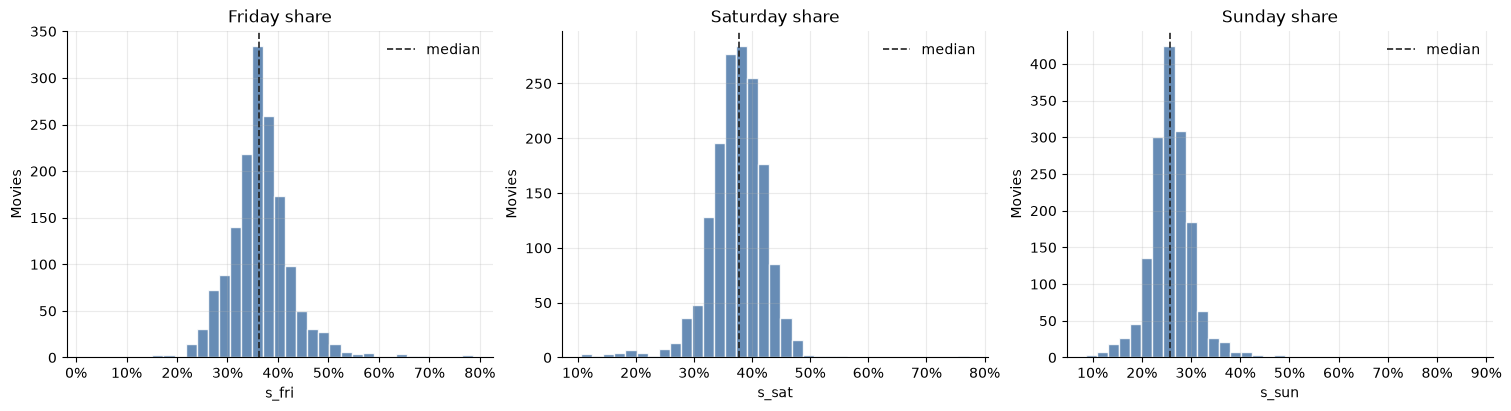

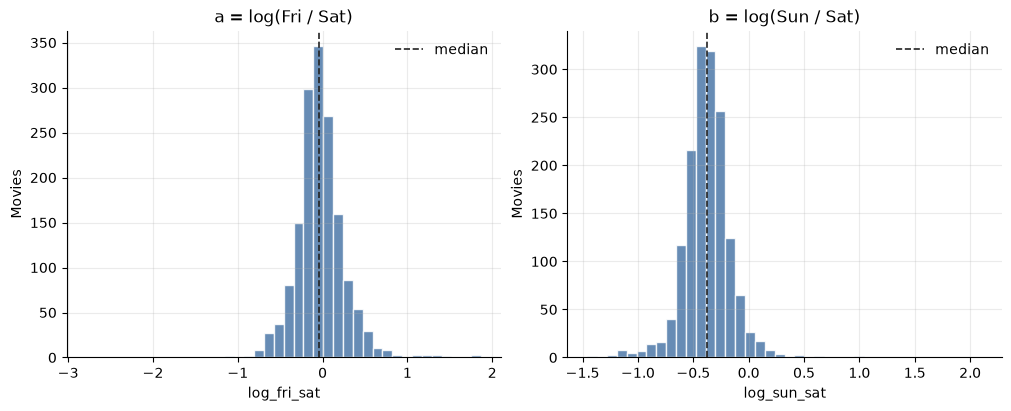

In [115]:
def hist_panel(df, columns, titles, bins=40, percent=False):
    fig, axes = plt.subplots(1, len(columns), figsize=(5 * len(columns), 4), constrained_layout=True)
    if len(columns) == 1:
        axes = [axes]
    for ax, col, title in zip(axes, columns, titles):
        values = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(values, bins=bins, color="#4c78a8", alpha=0.85, edgecolor="white")
        ax.axvline(values.median(), color="#222222", linestyle="--", linewidth=1.2, label="median")
        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel("Movies")
        if percent:
            ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
        ax.legend(frameon=False)
    plt.show()

hist_panel(
    shape_base,
    ["s_fri", "s_sat", "s_sun"],
    ["Friday share", "Saturday share", "Sunday share"],
    bins=35,
    percent=True,
)

hist_panel(
    shape_base,
    ["log_fri_sat", "log_sun_sat"],
    ["a = log(Fri / Sat)", "b = log(Sun / Sat)"],
    bins=40,
)


## Plot 2: Weekend Profile Lines

Each line is one movie's Friday/Saturday/Sunday share profile. The thick black line is the median profile within the panel.

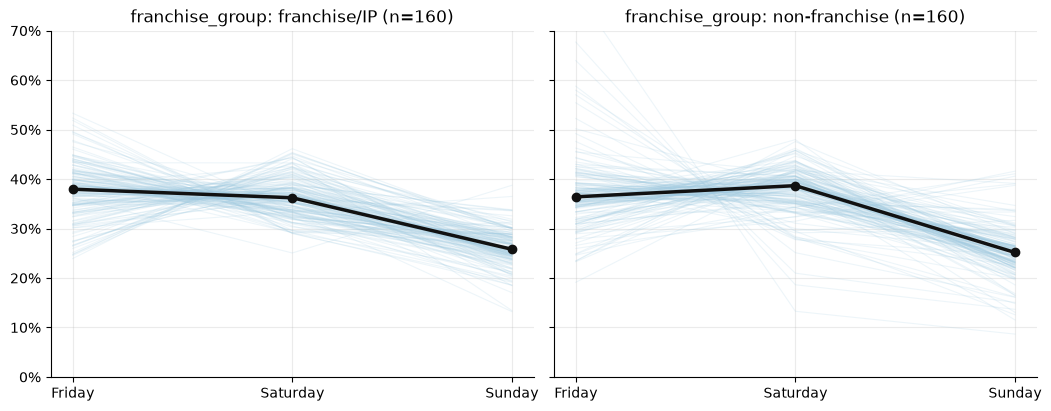

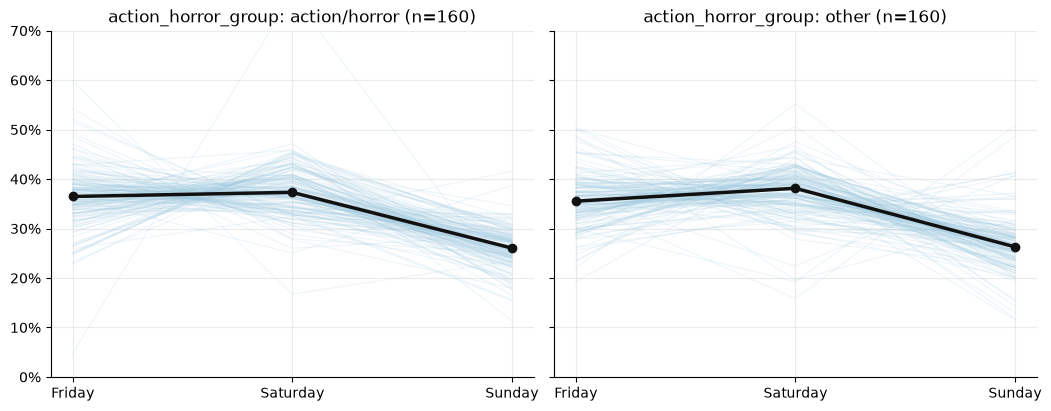

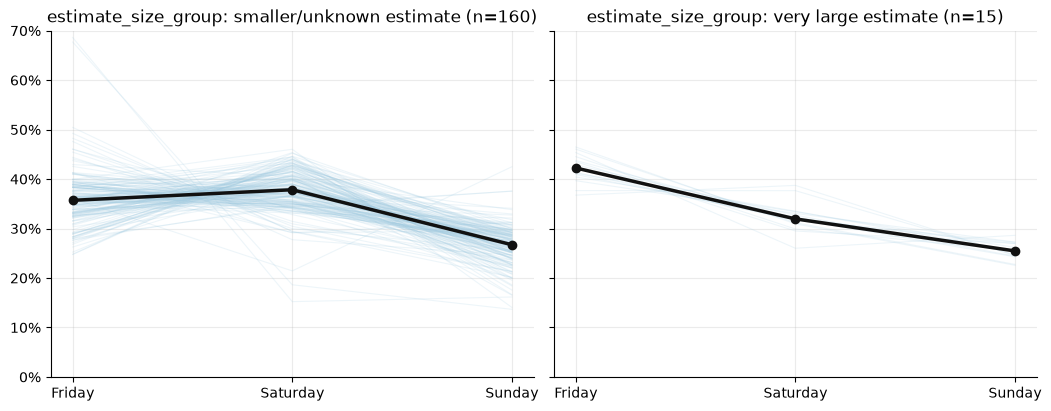

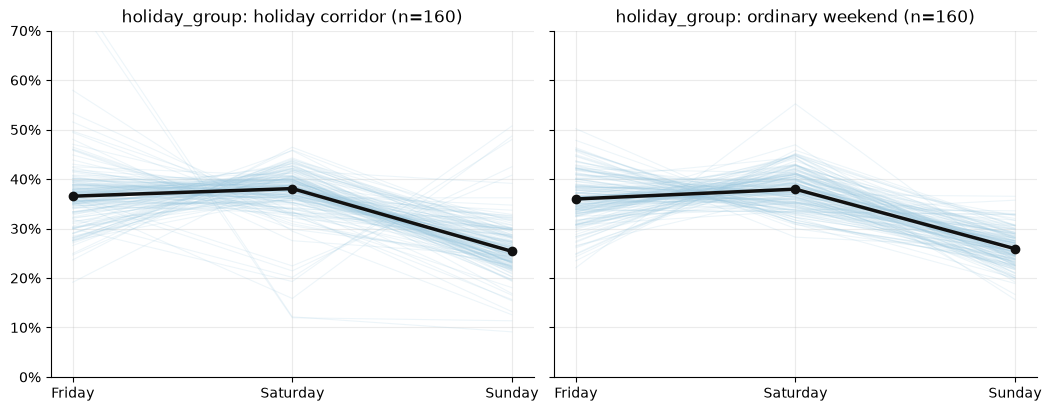

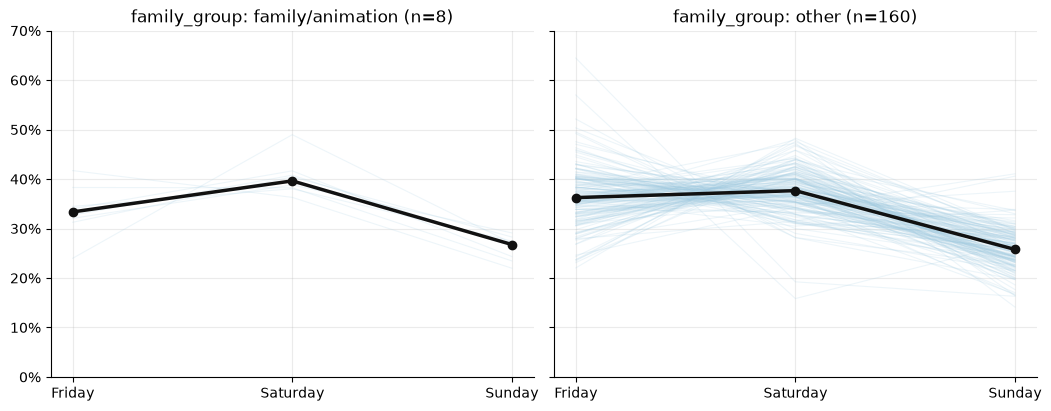

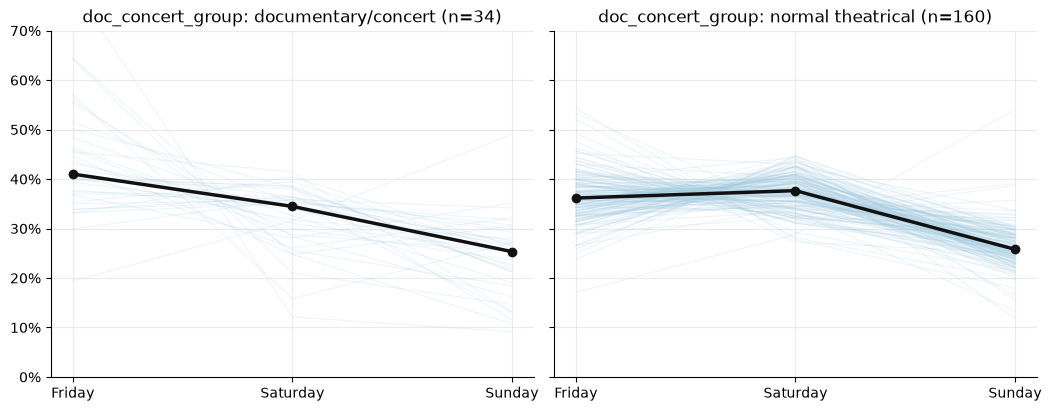

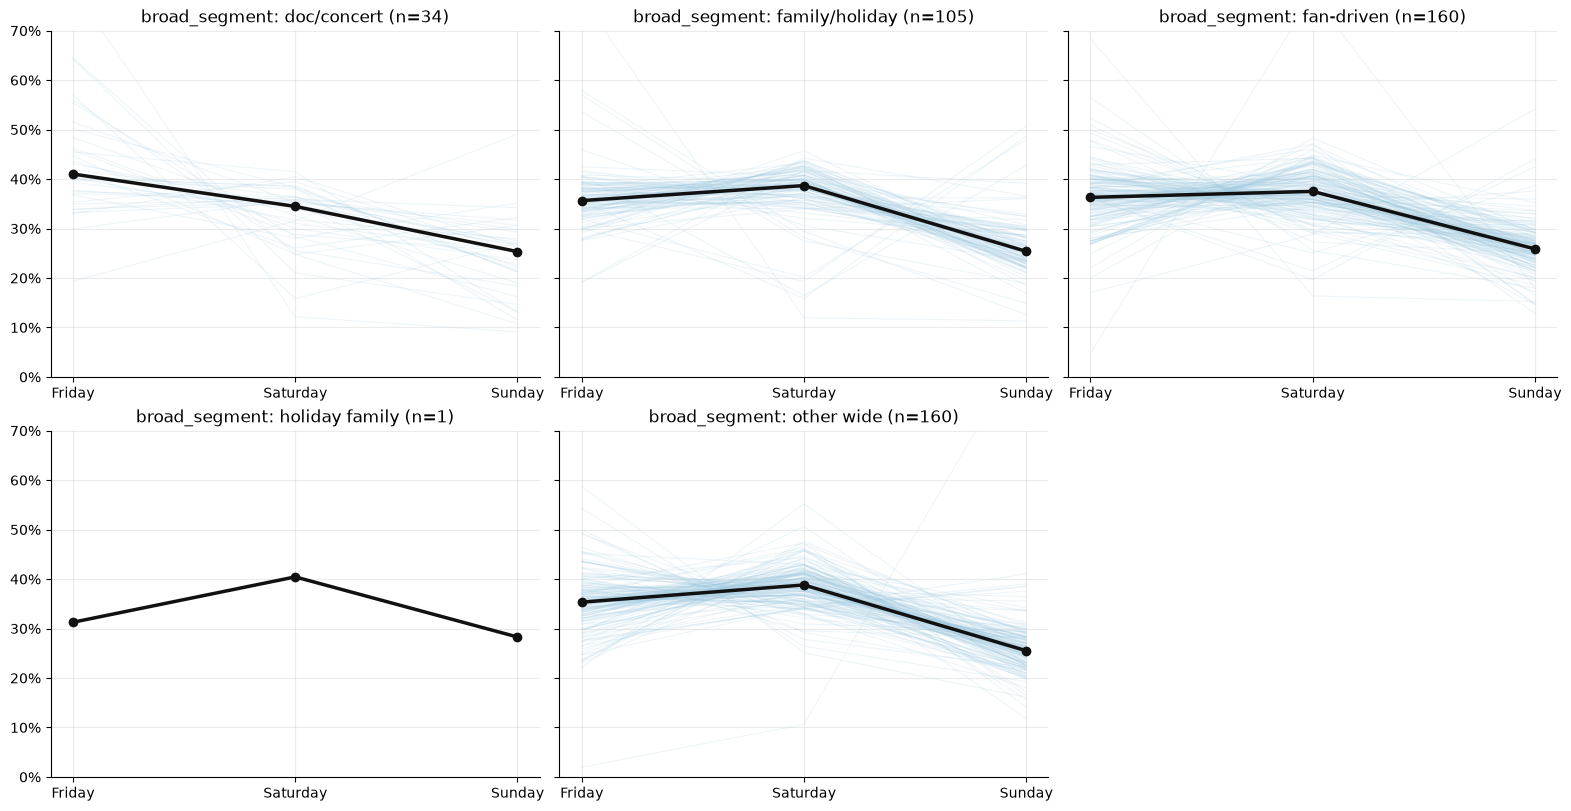

In [116]:
profile_long = shape_base.melt(
    id_vars=[
        "release_run_id", "title", "broad_segment", "franchise_group", "action_horror_group",
        "estimate_size_group", "holiday_group", "family_group", "doc_concert_group",
    ],
    value_vars=["s_fri", "s_sat", "s_sun"],
    var_name="day",
    value_name="share",
)
profile_long["day"] = profile_long["day"].map({"s_fri": "Friday", "s_sat": "Saturday", "s_sun": "Sunday"})
profile_long["day"] = pd.Categorical(profile_long["day"], categories=PROFILE_DAYS, ordered=True)


def plot_profile_lines(df, group_col, max_movies_per_group=160):
    groups = [g for g in df[group_col].dropna().unique()]
    groups = sorted(groups, key=lambda x: str(x))
    ncols = min(3, max(1, len(groups)))
    nrows = int(np.ceil(len(groups) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.0 * nrows), sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    x = np.arange(len(PROFILE_DAYS))
    for ax, group in zip(axes, groups):
        ids = df.loc[df[group_col].eq(group), "release_run_id"].drop_duplicates()
        if len(ids) > max_movies_per_group:
            ids = ids.sample(max_movies_per_group, random_state=17)
        sub = profile_long.loc[profile_long["release_run_id"].isin(ids)].copy()
        for _, movie in sub.pivot(index="release_run_id", columns="day", values="share").iterrows():
            ax.plot(x, movie.reindex(PROFILE_DAYS).values, color="#9ecae1", alpha=0.18, linewidth=0.8)
        med = sub.groupby("day", observed=False)["share"].median().reindex(PROFILE_DAYS)
        ax.plot(x, med.values, color="#111111", linewidth=2.5, marker="o")
        ax.set_title(f"{group_col}: {group} (n={len(ids)})")
        ax.set_xticks(x, PROFILE_DAYS)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
        ax.set_ylim(0, max(0.7, shape_base[["s_fri", "s_sat", "s_sun"]].quantile(0.99).max() + 0.03))
    for ax in axes[len(groups):]:
        ax.axis("off")
    plt.show()

for group_col in [
    "franchise_group", "action_horror_group", "estimate_size_group",
    "holiday_group", "family_group", "doc_concert_group", "broad_segment",
]:
    plot_profile_lines(shape_base, group_col)


## Plots 3 and 4: Log-Ratio Profiles by Segment

`a = log(Fri / Sat)` is the front-loadedness axis. `b = log(Sun / Sat)` is the Sunday-hold axis.

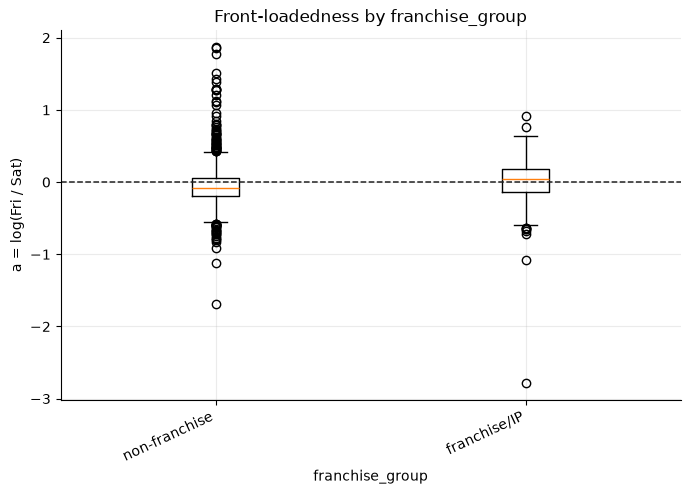

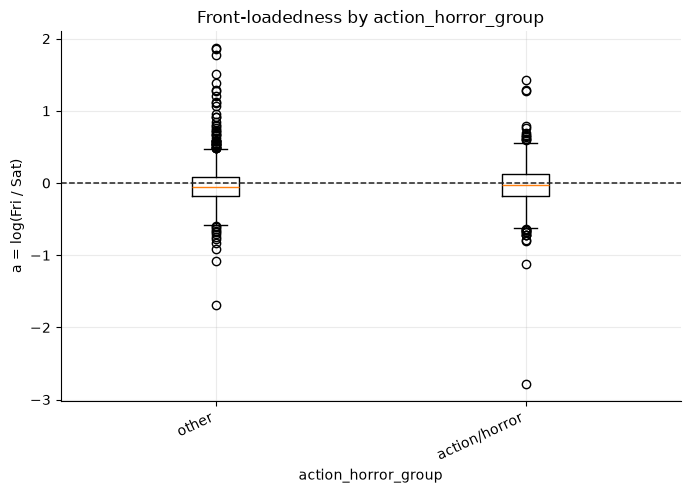

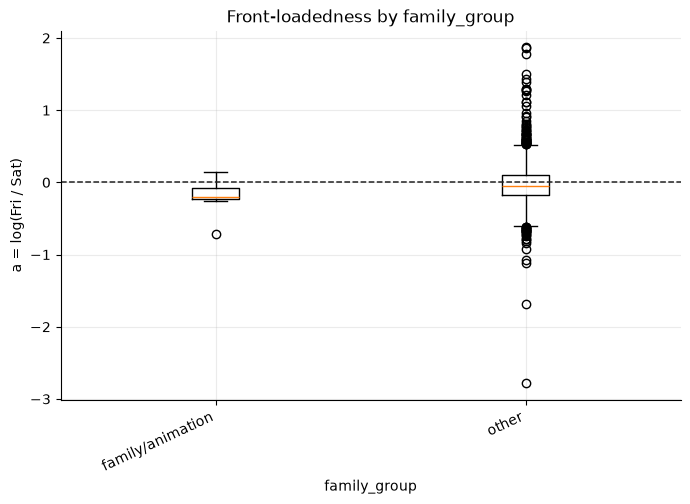

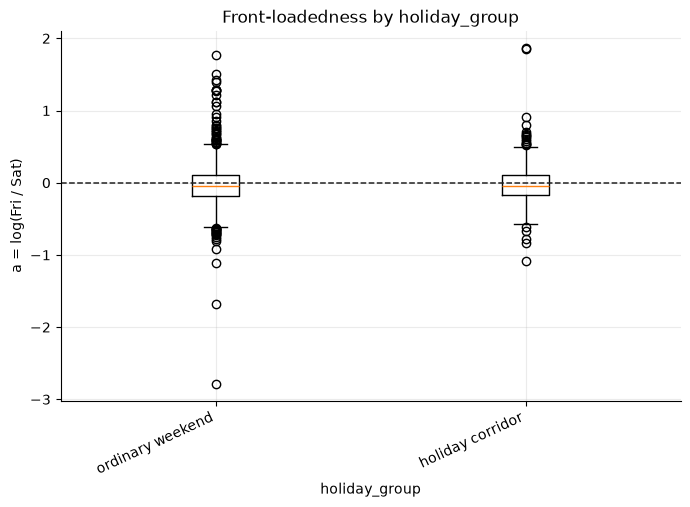

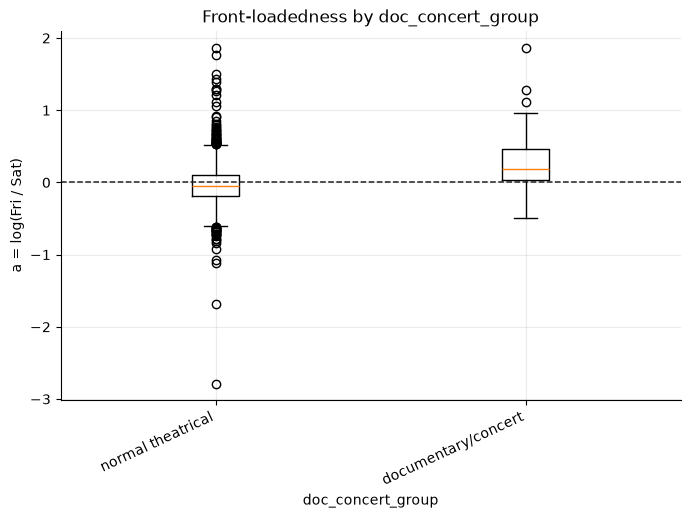

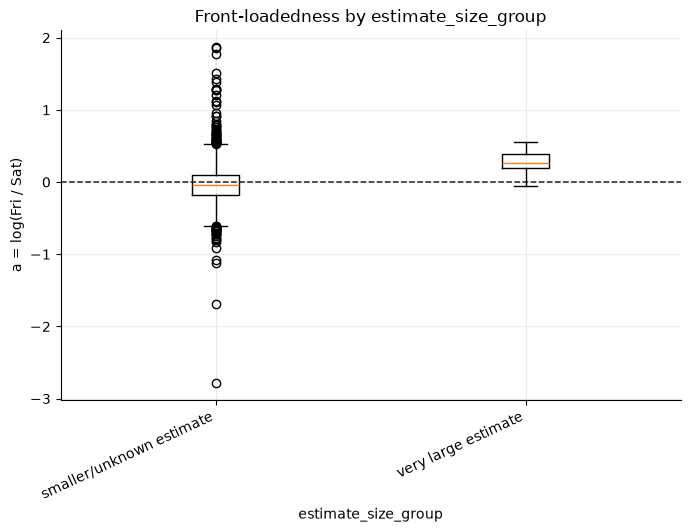

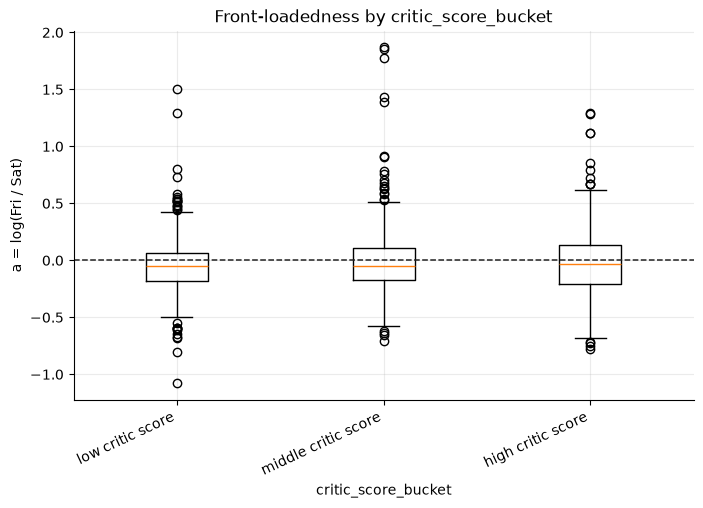

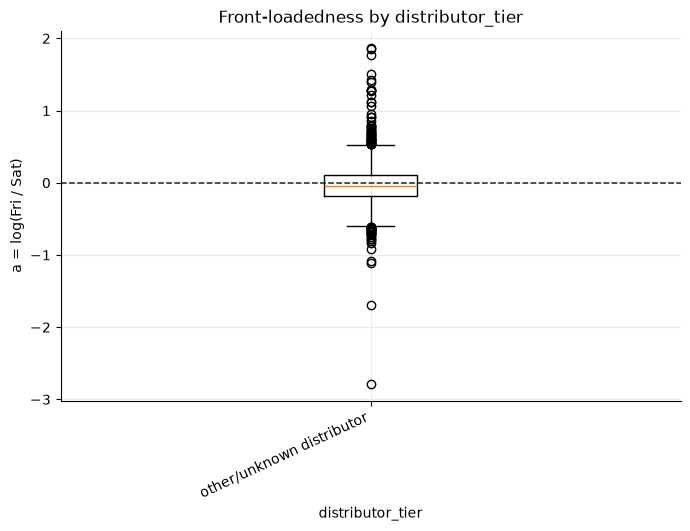

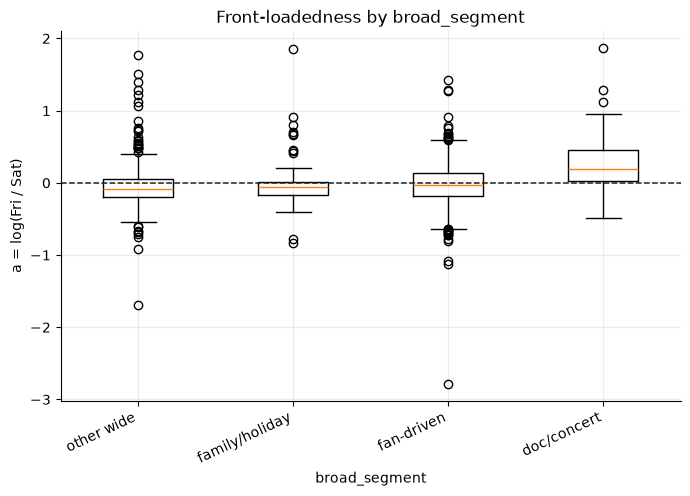

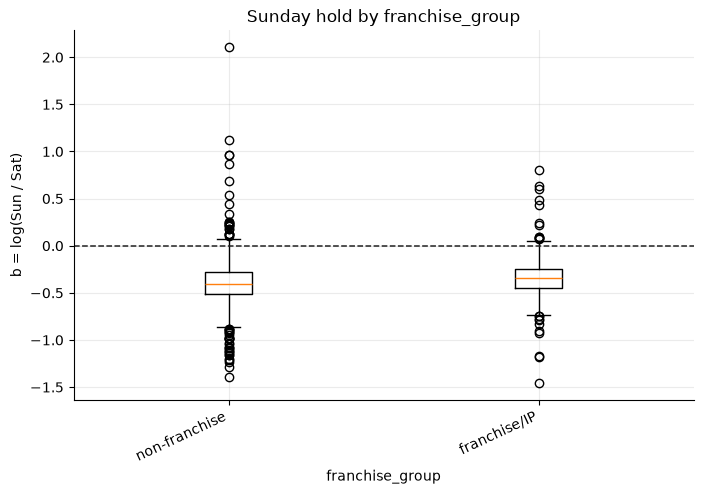

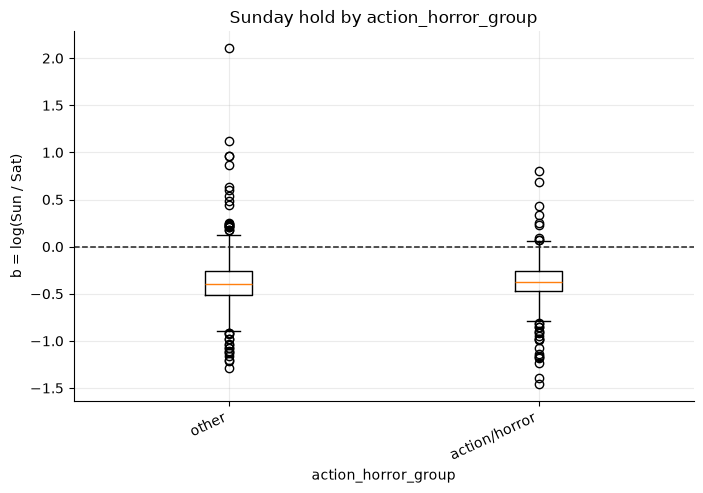

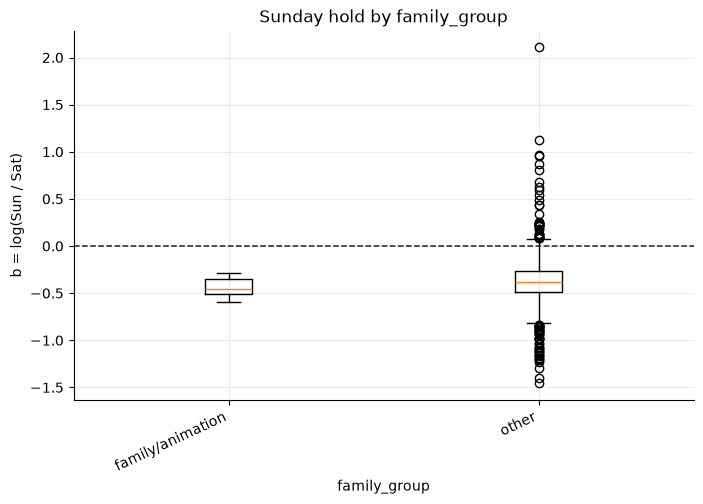

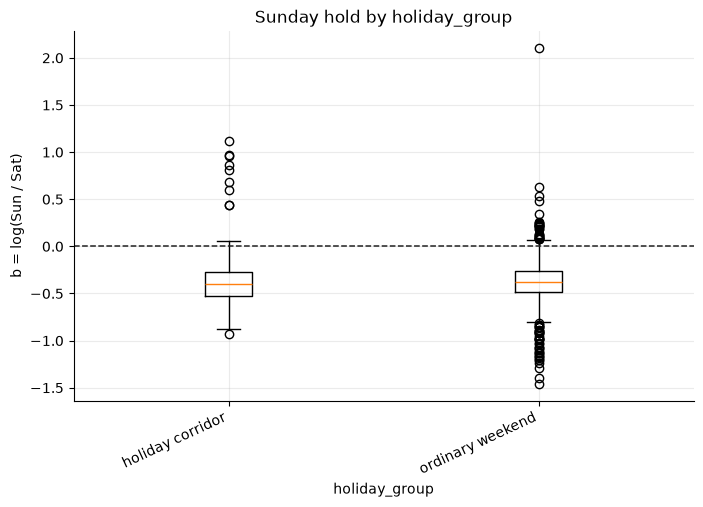

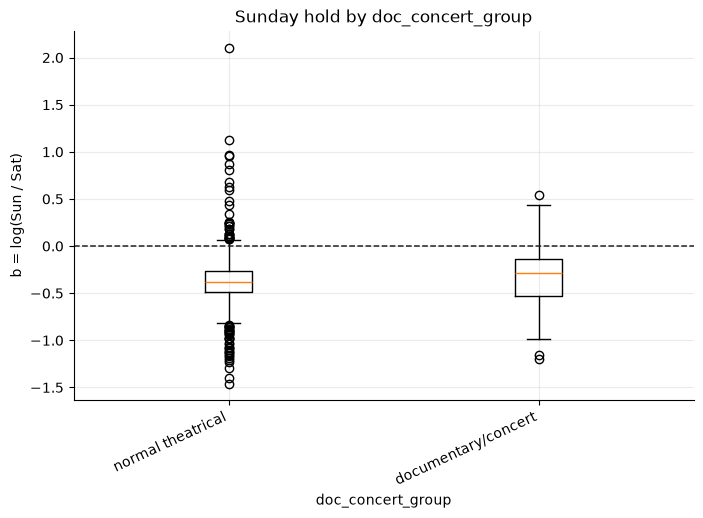

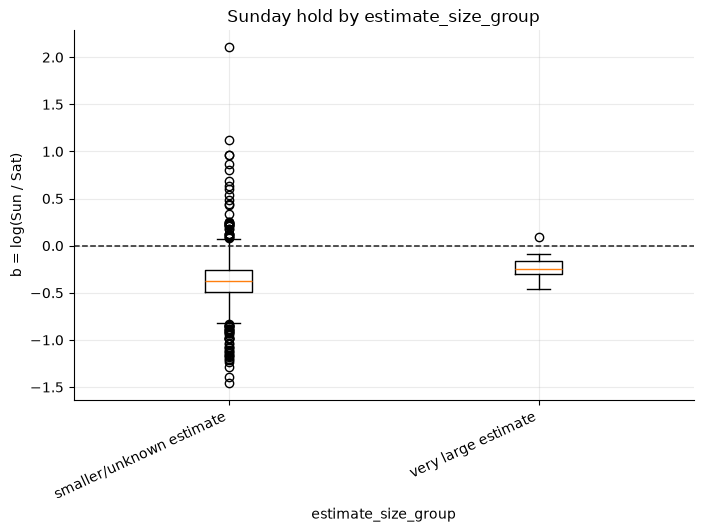

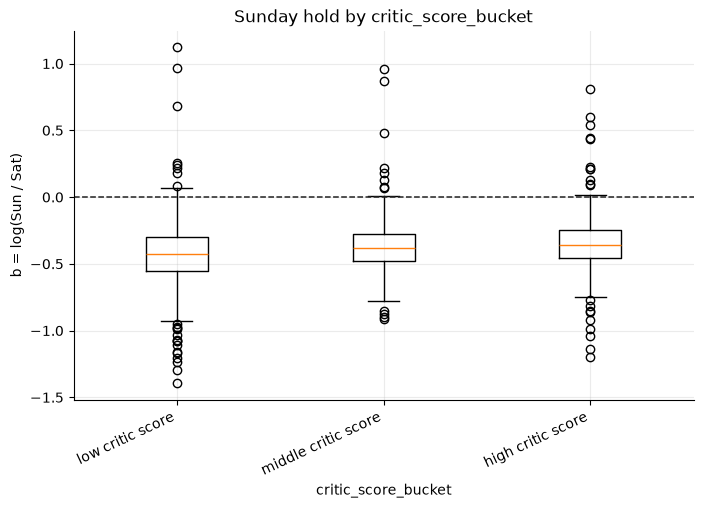

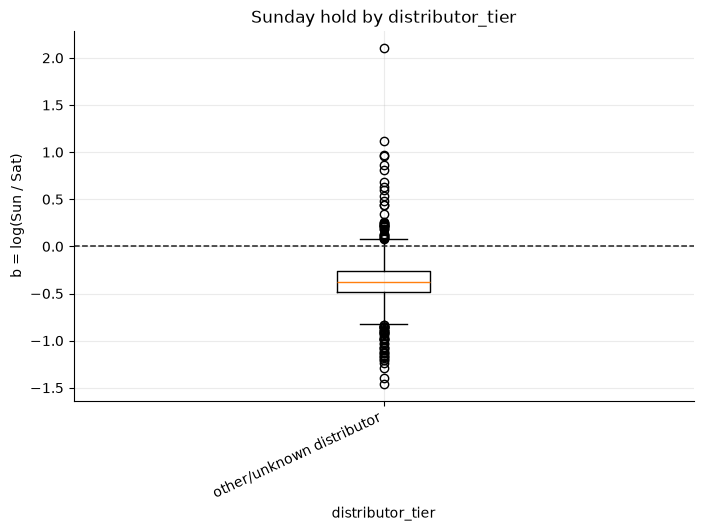

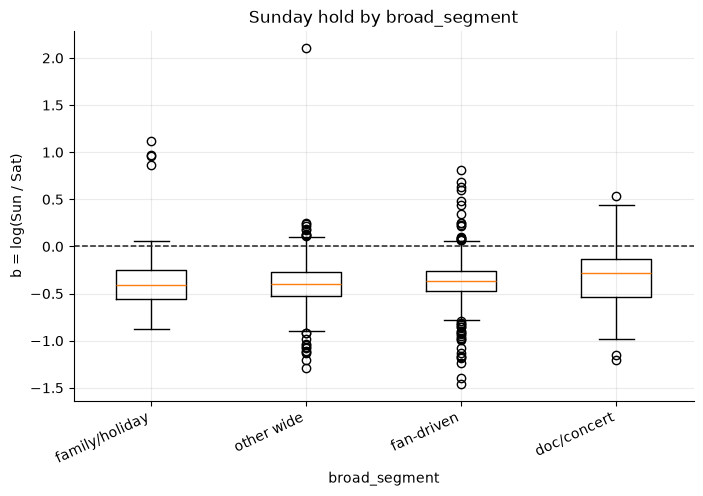

In [117]:
def boxplot_ordered(df, group_col, value_col, title, ylabel, min_n=5, rotation=25):
    plot_df = df[[group_col, value_col]].replace([np.inf, -np.inf], np.nan).dropna()
    counts = plot_df[group_col].value_counts()
    keep = counts[counts >= min_n].index
    plot_df = plot_df.loc[plot_df[group_col].isin(keep)].copy()
    if plot_df.empty:
        print(f"No data for {title}")
        return
    order = plot_df.groupby(group_col, observed=False)[value_col].median().sort_values().index.tolist()
    fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(order)), 4.8))
    ax.boxplot([plot_df.loc[plot_df[group_col].eq(g), value_col] for g in order], tick_labels=order, showfliers=True)
    ax.axhline(0, color="#222222", linestyle="--", linewidth=1.1)
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.show()

segment_cols = [
    "franchise_group", "action_horror_group", "family_group", "holiday_group",
    "doc_concert_group", "estimate_size_group", "critic_score_bucket", "distributor_tier", "broad_segment",
]

for group_col in segment_cols:
    boxplot_ordered(shape_base, group_col, "log_fri_sat", f"Front-loadedness by {group_col}", "a = log(Fri / Sat)")

for group_col in segment_cols:
    boxplot_ordered(shape_base, group_col, "log_sun_sat", f"Sunday hold by {group_col}", "b = log(Sun / Sat)")


## Benchmark Policies

Benchmark 0 uses a global median profile. Benchmark 1 uses broad segment median shares. Benchmark 2 uses broad segment median log-ratios and converts back to coherent shares. Benchmark 3 uses a fallback hierarchy to avoid sparse cells.

The calibration pass adds one v1 candidate: `benchmark_1_broad_direct_logratio_calibrated`. It starts from the current best broad direct profile, converts predicted shares to $a=\log(Fri/Sat)$ and $b=\log(Sun/Sat)$, adds training-fold residual intercepts, and back-transforms to coherent shares. The intercepts are estimated from prior chronological forecast residuals inside the training fold, with an in-sample fallback only when there is not enough historical validation data.

In [118]:
SHARE_COLS = ["s_fri", "s_sat", "s_sun"]
PRED_SHARE_COLS = ["pred_friday_share", "pred_saturday_share", "pred_sunday_share"]
CALIBRATION_CENTER = "mean"


def direct_median_profile(train):
    med = train[SHARE_COLS].median().values
    norm = normalize_profile(med)
    return pd.Series(dict(zip(PRED_SHARE_COLS, norm)))


def logratio_median_profile(train):
    a = train["log_fri_sat"].median()
    b = train["log_sun_sat"].median()
    return shares_from_ab(a, b)


def profile_table(train, group_col, method="direct", min_n=MIN_GROUP_N):
    rows = []
    global_profile = logratio_median_profile(train) if method == "logratio" else direct_median_profile(train)
    for group, gdf in train.groupby(group_col, dropna=False, observed=False):
        if len(gdf) < min_n:
            continue
        profile = logratio_median_profile(gdf) if method == "logratio" else direct_median_profile(gdf)
        rows.append({"group": group, "n": len(gdf), **profile.to_dict()})
    table = pd.DataFrame(rows)
    return table, global_profile


def predict_global(test, train, method="direct"):
    profile = logratio_median_profile(train) if method == "logratio" else direct_median_profile(train)
    pred = pd.DataFrame([profile.to_dict()] * len(test), index=test.index)
    return pred


def predict_by_group(test, train, group_col="broad_segment", method="direct", min_n=MIN_GROUP_N):
    table, global_profile = profile_table(train, group_col, method=method, min_n=min_n)
    lookup = table.set_index("group")[PRED_SHARE_COLS].to_dict("index") if not table.empty else {}
    rows = []
    for _, row in test.iterrows():
        profile = lookup.get(row[group_col], global_profile.to_dict())
        rows.append(profile)
    return pd.DataFrame(rows, index=test.index)


def hierarchy_condition(df, label):
    if label == "doc/concert":
        return df["is_doc_concert"]
    if label == "holiday family":
        return df["is_holiday_family"]
    if label == "fan-driven":
        return df["is_fan_driven"] & ~df["is_doc_concert"]
    if label == "other wide":
        return df["is_other_wide"]
    raise ValueError(label)


HIERARCHY = [
    ("doc/concert", DOC_CONCERT_MIN_N),
    ("holiday family", MIN_GROUP_N),
    ("fan-driven", MIN_GROUP_N),
    ("other wide", MIN_GROUP_N),
]


def predict_hierarchy(test, train):
    global_profile = logratio_median_profile(train).to_dict()
    profiles = {}
    for label, min_n in HIERARCHY:
        gdf = train.loc[hierarchy_condition(train, label)]
        if len(gdf) >= min_n:
            profiles[label] = logratio_median_profile(gdf).to_dict() | {"profile_n": len(gdf)}
    rows = []
    for _, row in test.iterrows():
        chosen = None
        for label, _ in HIERARCHY:
            if label in profiles and bool(hierarchy_condition(pd.DataFrame([row]), label).iloc[0]):
                chosen = profiles[label]
                break
        if chosen is None:
            chosen = global_profile | {"profile_n": len(train)}
        rows.append({k: v for k, v in chosen.items() if k in PRED_SHARE_COLS})
    return pd.DataFrame(rows, index=test.index)


def predicted_logratios(pred):
    pred = pred.copy()
    return pd.DataFrame(
        {
            "pred_log_fri_sat": np.log(pred["pred_friday_share"] / pred["pred_saturday_share"]),
            "pred_log_sun_sat": np.log(pred["pred_sunday_share"] / pred["pred_saturday_share"]),
        },
        index=pred.index,
    )


def calibration_from_residuals(residuals, center=CALIBRATION_CENTER):
    residuals = residuals.replace([np.inf, -np.inf], np.nan).dropna(subset=["e_a", "e_b"])
    if center == "median":
        c_a = residuals["e_a"].median()
        c_b = residuals["e_b"].median()
    elif center == "mean":
        c_a = residuals["e_a"].mean()
        c_b = residuals["e_b"].mean()
    else:
        raise ValueError("center must be 'mean' or 'median'")
    return {
        "calibration_center": center,
        "calibration_c_a": c_a,
        "calibration_c_b": c_b,
        "train_mean_e_a_before_calibration": residuals["e_a"].mean(),
        "train_mean_e_b_before_calibration": residuals["e_b"].mean(),
        "train_median_e_a_before_calibration": residuals["e_a"].median(),
        "train_median_e_b_before_calibration": residuals["e_b"].median(),
        "calibration_residual_n": len(residuals),
    }


def calibration_residuals_from_predictions(actual, pred):
    ratios = predicted_logratios(pred)
    return pd.DataFrame(
        {
            "e_a": actual["log_fri_sat"].reset_index(drop=True) - ratios["pred_log_fri_sat"].reset_index(drop=True),
            "e_b": actual["log_sun_sat"].reset_index(drop=True) - ratios["pred_log_sun_sat"].reset_index(drop=True),
        }
    )


def calibrate_logratio_intercepts(train, train_pred, center=CALIBRATION_CENTER):
    residuals = calibration_residuals_from_predictions(train, train_pred)
    calibration = calibration_from_residuals(residuals, center=center)
    calibration["calibration_method"] = "training_in_sample"
    return calibration


def calibrate_logratio_intercepts_from_prior_oos(train, center=CALIBRATION_CENTER):
    residual_frames = []
    for validation_year in sorted(train["release_year"].dropna().astype(int).unique()):
        inner_train = train.loc[train["release_year"] < validation_year].copy()
        inner_test = train.loc[train["release_year"].eq(validation_year)].copy()
        if len(inner_train) < MIN_TRAIN_MOVIES or inner_test.empty:
            continue
        inner_pred = predict_by_group(inner_test, inner_train, method="direct", min_n=MIN_GROUP_N)
        residuals = calibration_residuals_from_predictions(inner_test, inner_pred)
        residuals["validation_year"] = validation_year
        residual_frames.append(residuals)
    if not residual_frames:
        train_pred = predict_by_group(train, train, method="direct", min_n=MIN_GROUP_N)
        return calibrate_logratio_intercepts(train, train_pred, center=center)
    residuals = pd.concat(residual_frames, ignore_index=True)
    calibration = calibration_from_residuals(residuals, center=center)
    calibration["calibration_method"] = "training_prior_oos"
    calibration["calibration_first_validation_year"] = residuals["validation_year"].min()
    calibration["calibration_last_validation_year"] = residuals["validation_year"].max()
    return calibration


def apply_logratio_calibration(pred, calibration):
    ratios = predicted_logratios(pred)
    calibrated = pd.DataFrame(index=pred.index)
    calibrated["calibrated_pred_log_fri_sat"] = ratios["pred_log_fri_sat"] + calibration["calibration_c_a"]
    calibrated["calibrated_pred_log_sun_sat"] = ratios["pred_log_sun_sat"] + calibration["calibration_c_b"]
    shares = calibrated.apply(
        lambda row: shares_from_ab(row["calibrated_pred_log_fri_sat"], row["calibrated_pred_log_sun_sat"]),
        axis=1,
    )
    for col in PRED_SHARE_COLS:
        calibrated[col] = shares[col]
    for key, value in calibration.items():
        calibrated[key] = value
    return calibrated


def predict_broad_direct_logratio_calibrated(test, train):
    test_pred = predict_by_group(test, train, method="direct", min_n=MIN_GROUP_N)
    calibration = calibrate_logratio_intercepts_from_prior_oos(train.reset_index(drop=True))
    return apply_logratio_calibration(test_pred, calibration)


def add_prediction_errors(test, pred, model):
    out = test.reset_index(drop=True).copy()
    pred = pred.reset_index(drop=True).copy()
    out[PRED_SHARE_COLS] = pred[PRED_SHARE_COLS]
    extra_pred_cols = [col for col in pred.columns if col not in PRED_SHARE_COLS]
    for col in extra_pred_cols:
        out[col] = pred[col]
    out["model"] = model
    out["fri_share_error"] = out["s_fri"] - out["pred_friday_share"]
    out["sat_share_error"] = out["s_sat"] - out["pred_saturday_share"]
    out["sun_share_error"] = out["s_sun"] - out["pred_sunday_share"]
    out["total_abs_share_error"] = out[["fri_share_error", "sat_share_error", "sun_share_error"]].abs().sum(axis=1)
    out["pred_log_fri_sat"] = np.log(out["pred_friday_share"] / out["pred_saturday_share"])
    out["pred_log_sun_sat"] = np.log(out["pred_sunday_share"] / out["pred_saturday_share"])
    out["log_fri_sat_error"] = out["log_fri_sat"] - out["pred_log_fri_sat"]
    out["log_sun_sat_error"] = out["log_sun_sat"] - out["pred_log_sun_sat"]
    out["pred_friday_gross_shape_only"] = out["opening_weekend_gross_usd"] * out["pred_friday_share"]
    out["pred_saturday_gross_shape_only"] = out["opening_weekend_gross_usd"] * out["pred_saturday_share"]
    out["pred_sunday_gross_shape_only"] = out["opening_weekend_gross_usd"] * out["pred_sunday_share"]
    out["friday_dollar_error_shape_only"] = out["friday_gross_usd"] - out["pred_friday_gross_shape_only"]
    out["saturday_dollar_error_shape_only"] = out["saturday_gross_usd"] - out["pred_saturday_gross_shape_only"]
    out["sunday_dollar_error_shape_only"] = out["sunday_gross_usd"] - out["pred_sunday_gross_shape_only"]
    return out


## Chronological Validation

Each test-year forecast is produced from movies released before that year. Segment medians and log-ratio calibration intercepts are computed only from the training releases available before the test year.

In [119]:
def rolling_shape_predictions(df):
    years = sorted(y for y in df["release_year"].dropna().astype(int).unique() if y >= ROLLING_TEST_START_YEAR)
    all_predictions = []
    for test_year in years:
        train = df.loc[df["release_year"] < test_year].copy()
        test = df.loc[df["release_year"].eq(test_year)].copy()
        if len(train) < MIN_TRAIN_MOVIES or test.empty:
            continue
        fold = f"train_before_{test_year}__test_{test_year}"
        model_preds = {
            "benchmark_0_global_direct": predict_global(test, train, method="direct"),
            "benchmark_1_broad_direct": predict_by_group(test, train, method="direct", min_n=MIN_GROUP_N),
            "benchmark_1_broad_direct_logratio_calibrated": predict_broad_direct_logratio_calibrated(test, train),
            "benchmark_2_broad_logratio": predict_by_group(test, train, method="logratio", min_n=MIN_GROUP_N),
            "benchmark_3_hierarchy_logratio": predict_hierarchy(test, train),
        }
        for model, pred in model_preds.items():
            out = add_prediction_errors(test, pred, model)
            out["fold"] = fold
            out["train_n"] = len(train)
            out["test_year"] = test_year
            all_predictions.append(out)
    if not all_predictions:
        raise ValueError("No chronological folds were created. Lower ROLLING_TEST_START_YEAR or MIN_TRAIN_MOVIES.")
    return pd.concat(all_predictions, ignore_index=True)

shape_cv = rolling_shape_predictions(shape_base)
shape_cv[["model", "fold", "release_run_id", "title", "test_year", *PRED_SHARE_COLS]].head()


,model,fold,release_run_id,title,test_year,pred_friday_share,pred_saturday_share,pred_sunday_share
0,benchmark_0_global_direct,train_before_2023__test_2023,18,80 for Brady (2023),2023,0.361385,0.380633,0.257982
1,benchmark_0_global_direct,train_before_2023__test_2023,323,The Chosen Season 3 Finale (2023),2023,0.361385,0.380633,0.257982
2,benchmark_0_global_direct,train_before_2023__test_2023,70,The Amazing Maurice (2022),2023,0.361385,0.380633,0.257982
3,benchmark_0_global_direct,train_before_2023__test_2023,92,Ant-Man and the Wasp: Quantumania (2023),2023,0.361385,0.380633,0.257982
4,benchmark_0_global_direct,train_before_2023__test_2023,348,Cocaine Bear (2023),2023,0.361385,0.380633,0.257982


In [120]:
def rmse(series):
    values = pd.to_numeric(series, errors="coerce").dropna()
    return np.sqrt(np.mean(np.square(values))) if len(values) else np.nan


def shape_metric_summary(df):
    rows = []
    for model, g in df.groupby("model"):
        daily_abs = pd.concat([
            g["friday_dollar_error_shape_only"].abs(),
            g["saturday_dollar_error_shape_only"].abs(),
            g["sunday_dollar_error_shape_only"].abs(),
        ], ignore_index=True)
        rows.append({
            "model": model,
            "n_movies": g["release_run_id"].nunique(),
            "avg_abs_daily_dollar_error": daily_abs.mean(),
            "rmse_daily_dollar_error": rmse(pd.concat([
                g["friday_dollar_error_shape_only"],
                g["saturday_dollar_error_shape_only"],
                g["sunday_dollar_error_shape_only"],
            ], ignore_index=True)),
            "avg_total_abs_share_error": g["total_abs_share_error"].mean(),
            "mae_fri_share": g["fri_share_error"].abs().mean(),
            "mae_sat_share": g["sat_share_error"].abs().mean(),
            "mae_sun_share": g["sun_share_error"].abs().mean(),
            "mae_log_fri_sat": g["log_fri_sat_error"].abs().mean(),
            "mae_log_sun_sat": g["log_sun_sat_error"].abs().mean(),
            "mean_e_a": g["log_fri_sat_error"].mean(),
            "mean_e_b": g["log_sun_sat_error"].mean(),
            "median_e_a": g["log_fri_sat_error"].median(),
            "median_e_b": g["log_sun_sat_error"].median(),
            "mean_calibration_c_a": g["calibration_c_a"].mean() if "calibration_c_a" in g else np.nan,
            "mean_calibration_c_b": g["calibration_c_b"].mean() if "calibration_c_b" in g else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["avg_abs_daily_dollar_error", "avg_total_abs_share_error"])

shape_summary = shape_metric_summary(shape_cv)
display(shape_summary)

calibration_diagnostics = (
    shape_cv.loc[shape_cv["model"].eq("benchmark_1_broad_direct_logratio_calibrated")]
    .groupby("fold")
    .agg(
        test_year=("test_year", "first"),
        train_n=("train_n", "first"),
        calibration_method=("calibration_method", "first"),
        calibration_residual_n=("calibration_residual_n", "first"),
        calibration_c_a=("calibration_c_a", "first"),
        calibration_c_b=("calibration_c_b", "first"),
        train_mean_e_a_before_calibration=("train_mean_e_a_before_calibration", "first"),
        train_mean_e_b_before_calibration=("train_mean_e_b_before_calibration", "first"),
        test_mean_e_a=("log_fri_sat_error", "mean"),
        test_mean_e_b=("log_sun_sat_error", "mean"),
    )
    .reset_index()
)
display(calibration_diagnostics)

best_shape_model = shape_summary.iloc[0]["model"]
best_shape_model


,model,n_movies,avg_abs_daily_dollar_error,rmse_daily_dollar_error,avg_total_abs_share_error,mae_fri_share,mae_sat_share,mae_sun_share,mae_log_fri_sat,mae_log_sun_sat,mean_e_a,mean_e_b,median_e_a,median_e_b,mean_calibration_c_a,mean_calibration_c_b
2,benchmark_1_broad_direct_logratio_calibrated,148,695373.479344,1.660428e+06,0.169741,0.075590,0.051970,0.042181,0.332585,0.173010,0.186852,0.075185,0.173975,0.052834,0.031366,0.028167
1,benchmark_1_broad_direct,148,740019.321062,1.789076e+06,0.175344,0.077710,0.056000,0.041634,0.348145,0.180549,0.218218,0.103353,0.205489,0.079514,NaN,NaN
4,benchmark_3_hierarchy_logratio,148,751319.480291,1.817428e+06,0.177014,0.078526,0.056490,0.041998,0.351454,0.181576,0.224833,0.101569,0.211482,0.080737,NaN,NaN
3,benchmark_2_broad_logratio,148,751586.118463,1.817014e+06,0.177300,0.078776,0.056451,0.042073,0.352246,0.181399,0.225457,0.100480,0.216682,0.080737,NaN,NaN
0,benchmark_0_global_direct,148,767018.198041,1.867008e+06,0.178275,0.079767,0.056846,0.041663,0.356964,0.180500,0.230437,0.109629,0.228448,0.079877,NaN,NaN


,fold,test_year,train_n,calibration_method,calibration_residual_n,calibration_c_a,calibration_c_b,train_mean_e_a_before_calibration,train_mean_e_b_before_calibration,test_mean_e_a,test_mean_e_b
0,train_before_2023__test_2023,2023,1440,training_prior_oos,1264.0,0.024629,0.024460,0.024629,0.024460,0.099521,0.093902
1,train_before_2024__test_2024,2024,1471,training_prior_oos,1295.0,0.027012,0.026708,0.027012,0.026708,0.188275,0.076573
2,train_before_2025__test_2025,2025,1509,training_prior_oos,1333.0,0.032379,0.028890,0.032379,0.028890,0.263002,0.101232
3,train_before_2026__test_2026,2026,1543,training_prior_oos,1367.0,0.038920,0.031408,0.038920,0.031408,0.188275,0.041440


'benchmark_1_broad_direct_logratio_calibrated'

## Pre-Weekend Baseline Refinement Grid

The current working baseline is `benchmark_1_broad_direct_logratio_calibrated`. Keep `benchmark_0_global_direct` as the benchmark reference, but treat the calibrated broad model as the first v1 candidate.

This section tests no-new-predictor refinements only:

- recent-window training histories;
- recency-weighted profiles;
- mean, median, and trimmed-mean profile summaries;
- direct-share and log-ratio summaries;
- simple segment trees;
- objective-tuned `(c_a, c_b)` calibration chosen from prior chronological validation predictions.

The calibration objective is the same shape-only daily dollar MAE used to choose the pre-weekend split model.

In [121]:
def weighted_quantile(values, weights=None, quantile=0.5):
    values = pd.to_numeric(pd.Series(values), errors="coerce")
    if weights is None:
        clean = values.dropna()
        return clean.quantile(quantile) if len(clean) else np.nan
    weights = pd.to_numeric(pd.Series(weights, index=values.index), errors="coerce")
    mask = values.notna() & weights.notna() & weights.gt(0)
    if not mask.any():
        return values.dropna().quantile(quantile) if values.notna().any() else np.nan
    order = np.argsort(values[mask].to_numpy())
    sorted_values = values[mask].to_numpy()[order]
    sorted_weights = weights[mask].to_numpy()[order]
    cume = np.cumsum(sorted_weights)
    cutoff = quantile * sorted_weights.sum()
    return sorted_values[np.searchsorted(cume, cutoff, side="left")]


def trimmed_mean(values, proportion=0.1):
    clean = pd.to_numeric(pd.Series(values), errors="coerce").dropna().sort_values()
    if clean.empty:
        return np.nan
    trim_n = int(np.floor(len(clean) * proportion))
    if trim_n > 0 and len(clean) > 2 * trim_n:
        clean = clean.iloc[trim_n:-trim_n]
    return clean.mean()


def weighted_mean(values, weights=None):
    values = pd.to_numeric(pd.Series(values), errors="coerce")
    if weights is None:
        return values.mean()
    weights = pd.to_numeric(pd.Series(weights, index=values.index), errors="coerce")
    mask = values.notna() & weights.notna() & weights.gt(0)
    if not mask.any():
        return values.mean()
    return np.average(values[mask], weights=weights[mask])


def aggregate_series(values, weights=None, aggregator="median"):
    if aggregator == "median":
        return weighted_quantile(values, weights, 0.5)
    if aggregator == "mean":
        return weighted_mean(values, weights)
    if aggregator == "trimmed_mean":
        return trimmed_mean(values)
    raise ValueError(f"Unknown aggregator: {aggregator}")


def add_refinement_segments(df):
    out = df.copy()
    out["segment_current_broad"] = out["broad_segment"]
    out["segment_ip_doc"] = np.select(
        [out["is_doc_concert"], out["is_franchise"]],
        ["doc/concert", "franchise/IP"],
        default="non-franchise commercial wide",
    )
    out["segment_ip_large_doc"] = np.select(
        [out["is_doc_concert"], out["is_very_large_estimate"], out["is_franchise"]],
        ["doc/concert", "very large estimate", "franchise/IP"],
        default="non-franchise commercial wide",
    )
    return out


shape_base = add_refinement_segments(shape_base)


def filter_training_window(train, forecast_year, window):
    if window == "all_prior":
        return train.copy()
    if window.startswith("since"):
        start_year = int(window.replace("since", ""))
        return train.loc[train["release_year"] >= start_year].copy()
    if window.startswith("last"):
        years = int(window.replace("last", "").replace("y", ""))
        return train.loc[train["release_year"] >= forecast_year - years].copy()
    raise ValueError(f"Unknown training window: {window}")


def historical_weights(train, forecast_year, weighting):
    if weighting == "unweighted":
        return None
    if weighting.startswith("recency_"):
        lam = float(weighting.split("_")[1])
        return lam ** (forecast_year - train["release_year"].astype(float))
    if weighting == "ow_weighted":
        return train["opening_weekend_gross_usd"].clip(lower=1)
    if weighting == "log_ow_weighted":
        return np.log1p(train["opening_weekend_gross_usd"].clip(lower=0))
    if weighting == "estimate_weighted":
        weights = train["latest_estimate_mid_usd"].copy()
        fallback = weights[weights > 0].median()
        if not np.isfinite(fallback):
            fallback = train["opening_weekend_gross_usd"].clip(lower=1).median()
        return weights.fillna(fallback).clip(lower=1)
    raise ValueError(f"Unknown weighting: {weighting}")


def profile_from_history(train, forecast_year, config):
    window_train = filter_training_window(train, forecast_year, config["window"])
    if len(window_train) < MIN_TRAIN_MOVIES:
        window_train = train.copy()
    weights = historical_weights(window_train, forecast_year, config["weighting"])
    representation = config["representation"]
    aggregator = config["aggregator"]
    if representation == "direct":
        values = [aggregate_series(window_train[col], weights, aggregator) for col in SHARE_COLS]
        profile = normalize_profile(values)
        return pd.Series(dict(zip(PRED_SHARE_COLS, profile)))
    if representation == "logratio":
        a = aggregate_series(window_train["log_fri_sat"], weights, aggregator)
        b = aggregate_series(window_train["log_sun_sat"], weights, aggregator)
        return shares_from_ab(a, b)
    raise ValueError(f"Unknown representation: {representation}")


def predict_refinement_candidate(test, train, config, forecast_year):
    segment_col = config["segment_col"]
    window_train = filter_training_window(train, forecast_year, config["window"])
    if len(window_train) < MIN_TRAIN_MOVIES:
        window_train = train.copy()
    global_profile = profile_from_history(window_train, forecast_year, config).to_dict()
    profiles = {}
    for group, gdf in window_train.groupby(segment_col, dropna=False, observed=False):
        min_n = DOC_CONCERT_MIN_N if group == "doc/concert" else MIN_GROUP_N
        if len(gdf) >= min_n:
            profiles[group] = profile_from_history(gdf, forecast_year, {**config, "window": "all_prior"}).to_dict()
    rows = []
    for _, row in test.iterrows():
        rows.append(profiles.get(row[segment_col], global_profile))
    return pd.DataFrame(rows, index=test.index)


def apply_logratio_constants(pred, c_a, c_b):
    ratios = predicted_logratios(pred)
    calibrated = pd.DataFrame(index=pred.index)
    calibrated["calibrated_pred_log_fri_sat"] = ratios["pred_log_fri_sat"] + c_a
    calibrated["calibrated_pred_log_sun_sat"] = ratios["pred_log_sun_sat"] + c_b
    exp_a = np.exp(calibrated["calibrated_pred_log_fri_sat"])
    exp_b = np.exp(calibrated["calibrated_pred_log_sun_sat"])
    denom = 1.0 + exp_a + exp_b
    calibrated["pred_friday_share"] = exp_a / denom
    calibrated["pred_saturday_share"] = 1.0 / denom
    calibrated["pred_sunday_share"] = exp_b / denom
    calibrated["calibration_c_a"] = c_a
    calibrated["calibration_c_b"] = c_b
    return calibrated


def build_prior_oos_predictions(train, config):
    frames = []
    for validation_year in sorted(train["release_year"].dropna().astype(int).unique()):
        inner_train = train.loc[train["release_year"] < validation_year].copy()
        inner_test = train.loc[train["release_year"].eq(validation_year)].copy()
        if len(inner_train) < MIN_TRAIN_MOVIES or inner_test.empty:
            continue
        pred = predict_refinement_candidate(inner_test, inner_train, config, validation_year)
        out = add_prediction_errors(inner_test, pred, config["model"])
        out["validation_year"] = validation_year
        frames.append(out)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def evaluate_calibrated_prior_oos(prior_oos, c_a, c_b, objective="daily_mae"):
    pred = prior_oos[PRED_SHARE_COLS].copy()
    calibrated = apply_logratio_constants(pred, c_a, c_b)
    eval_df = add_prediction_errors(prior_oos, calibrated, "calibration_grid")
    if objective == "daily_mae":
        return pd.concat(
            [
                eval_df["friday_dollar_error_shape_only"].abs(),
                eval_df["saturday_dollar_error_shape_only"].abs(),
                eval_df["sunday_dollar_error_shape_only"].abs(),
            ],
            ignore_index=True,
        ).mean()
    if objective == "share_error":
        return eval_df["total_abs_share_error"].mean()
    raise ValueError(f"Unknown calibration objective: {objective}")


def tune_calibration_grid(train, config):
    prior_oos = build_prior_oos_predictions(train, config)
    if prior_oos.empty:
        return {"calibration_c_a": 0.0, "calibration_c_b": 0.0, "calibration_objective_value": np.nan, "calibration_residual_n": 0}
    c_a_grid = np.round(np.arange(-0.05, 0.3001, 0.025), 3)
    c_b_grid = np.round(np.arange(-0.05, 0.1501, 0.025), 3)
    best = {"calibration_objective_value": np.inf}
    for c_a in c_a_grid:
        for c_b in c_b_grid:
            score = evaluate_calibrated_prior_oos(prior_oos, c_a, c_b, objective=config.get("calibration_objective", "daily_mae"))
            if score < best["calibration_objective_value"]:
                best = {
                    "calibration_c_a": c_a,
                    "calibration_c_b": c_b,
                    "calibration_objective_value": score,
                    "calibration_residual_n": len(prior_oos),
                }
    return best


REFINEMENT_CONFIGS = [
    {
        "model": "benchmark_4_recent_weighted_broad_logratio_calibrated",
        "segment_col": "segment_current_broad",
        "window": "all_prior",
        "weighting": "recency_0.95",
        "representation": "logratio",
        "aggregator": "mean",
        "calibration_objective": "daily_mae",
    },
    *[
        {
            "model": f"refine_window_{window}_broad_direct_median_grid_calibrated",
            "segment_col": "segment_current_broad",
            "window": window,
            "weighting": "unweighted",
            "representation": "direct",
            "aggregator": "median",
            "calibration_objective": "daily_mae",
        }
        for window in ["all_prior", "since2010", "since2015", "since2018", "since2022", "last5y", "last3y"]
    ],
    *[
        {
            "model": f"refine_recency_{lam}_broad_logratio_mean_grid_calibrated",
            "segment_col": "segment_current_broad",
            "window": "all_prior",
            "weighting": f"recency_{lam}",
            "representation": "logratio",
            "aggregator": "mean",
            "calibration_objective": "daily_mae",
        }
        for lam in ["0.90", "0.97"]
    ],
    *[
        {
            "model": f"refine_{weighting}_broad_logratio_mean_grid_calibrated",
            "segment_col": "segment_current_broad",
            "window": "all_prior",
            "weighting": weighting,
            "representation": "logratio",
            "aggregator": "mean",
            "calibration_objective": "daily_mae",
        }
        for weighting in ["ow_weighted", "log_ow_weighted", "estimate_weighted"]
    ],
    *[
        {
            "model": f"refine_broad_{representation}_{aggregator}_grid_calibrated",
            "segment_col": "segment_current_broad",
            "window": "all_prior",
            "weighting": "unweighted",
            "representation": representation,
            "aggregator": aggregator,
            "calibration_objective": "daily_mae",
        }
        for representation in ["direct", "logratio"]
        for aggregator in ["mean", "trimmed_mean"]
    ],
    *[
        {
            "model": f"refine_{segment_col}_direct_median_grid_calibrated",
            "segment_col": segment_col,
            "window": "all_prior",
            "weighting": "unweighted",
            "representation": "direct",
            "aggregator": "median",
            "calibration_objective": "daily_mae",
        }
        for segment_col in ["segment_ip_doc", "segment_ip_large_doc"]
    ],
]


def rolling_refinement_predictions(df, configs=REFINEMENT_CONFIGS):
    frames = []
    for test_year in sorted(y for y in df["release_year"].dropna().astype(int).unique() if y >= ROLLING_TEST_START_YEAR):
        train = df.loc[df["release_year"] < test_year].copy()
        test = df.loc[df["release_year"].eq(test_year)].copy()
        if len(train) < MIN_TRAIN_MOVIES or test.empty:
            continue
        for config in configs:
            base_pred = predict_refinement_candidate(test, train, config, test_year)
            calibration = tune_calibration_grid(train, config)
            pred = apply_logratio_constants(base_pred, calibration["calibration_c_a"], calibration["calibration_c_b"])
            pred["calibration_objective_value"] = calibration["calibration_objective_value"]
            pred["calibration_residual_n"] = calibration["calibration_residual_n"]
            out = add_prediction_errors(test, pred, config["model"])
            out["fold"] = f"train_before_{test_year}__test_{test_year}"
            out["train_n"] = len(train)
            out["test_year"] = test_year
            out["segment_col"] = config["segment_col"]
            out["training_window"] = config["window"]
            out["weighting"] = config["weighting"]
            out["representation"] = config["representation"]
            out["aggregator"] = config["aggregator"]
            frames.append(out)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

refinement_cv = rolling_refinement_predictions(shape_base)
refinement_summary = shape_metric_summary(refinement_cv)
combined_preweekend_summary = pd.concat([shape_summary, refinement_summary], ignore_index=True).sort_values(
    ["avg_abs_daily_dollar_error", "avg_total_abs_share_error"]
)

display(combined_preweekend_summary.head(15))

preweekend_baseline_decision = combined_preweekend_summary.assign(
    role=np.select(
        [
            combined_preweekend_summary["model"].eq("benchmark_0_global_direct"),
            combined_preweekend_summary["model"].eq("benchmark_1_broad_direct_logratio_calibrated"),
            combined_preweekend_summary["model"].eq("benchmark_4_recent_weighted_broad_logratio_calibrated"),
        ],
        ["benchmark reference", "current working baseline", "next refinement candidate"],
        default="candidate",
    )
)
display(preweekend_baseline_decision.loc[preweekend_baseline_decision["role"].ne("candidate")])

best_preweekend_refinement_model = combined_preweekend_summary.iloc[0]["model"]
best_preweekend_refinement_model


,model,n_movies,avg_abs_daily_dollar_error,rmse_daily_dollar_error,avg_total_abs_share_error,mae_fri_share,mae_sat_share,mae_sun_share,mae_log_fri_sat,mae_log_sun_sat,mean_e_a,mean_e_b,median_e_a,median_e_b,mean_calibration_c_a,mean_calibration_c_b
5,refine_window_last5y_broad_direct_median_grid_...,148,497748.218489,1.152301e+06,0.152275,0.066814,0.042812,0.042649,0.286966,0.170523,0.021658,-0.023797,0.001867,-0.056654,0.100000,0.075
6,refine_window_since2022_broad_direct_median_gr...,148,525661.042220,1.244209e+06,0.154116,0.067916,0.044507,0.041693,0.294849,0.173571,-0.031477,-0.024680,-0.037390,-0.061788,0.125000,0.075
7,refine_window_last3y_broad_direct_median_grid_...,148,527581.352482,1.261178e+06,0.153775,0.067482,0.044179,0.042114,0.292614,0.173124,-0.009686,-0.023602,-0.016954,-0.059550,0.100000,0.075
8,refine_window_since2018_broad_direct_median_gr...,148,541550.595260,1.204854e+06,0.156687,0.069346,0.043683,0.043658,0.297793,0.168588,0.060902,-0.017323,0.046553,-0.045937,0.125000,0.075
9,refine_window_since2015_broad_direct_median_gr...,148,567623.334644,1.297126e+06,0.156156,0.069286,0.044576,0.042294,0.297556,0.163455,0.083256,0.014033,0.068417,-0.007620,0.119764,0.075
10,refine_estimate_weighted_broad_logratio_mean_g...,148,569116.647675,1.294370e+06,0.155114,0.068668,0.044506,0.041940,0.296408,0.164540,0.073194,0.017704,0.061495,-0.000990,0.125000,0.075
11,refine_ow_weighted_broad_logratio_mean_grid_ca...,148,572822.892355,1.296639e+06,0.157800,0.069619,0.046575,0.041606,0.302465,0.166644,0.107544,0.043568,0.089833,0.021412,0.050000,0.025
12,refine_recency_0.90_broad_logratio_mean_grid_c...,148,578865.712124,1.323077e+06,0.155754,0.069063,0.044523,0.042169,0.297312,0.164174,0.075157,0.011467,0.073411,-0.011311,0.125000,0.075
13,refine_window_all_prior_broad_direct_median_gr...,148,584434.356670,1.330430e+06,0.157420,0.069909,0.045401,0.042110,0.300416,0.165113,0.093218,0.028353,0.080489,0.004514,0.125000,0.075
14,refine_window_since2010_broad_direct_median_gr...,148,587474.613620,1.353991e+06,0.157057,0.069622,0.045389,0.042045,0.299278,0.165037,0.096818,0.028529,0.084744,0.005106,0.119764,0.075


,model,n_movies,avg_abs_daily_dollar_error,rmse_daily_dollar_error,avg_total_abs_share_error,mae_fri_share,mae_sat_share,mae_sun_share,mae_log_fri_sat,mae_log_sun_sat,mean_e_a,mean_e_b,median_e_a,median_e_b,mean_calibration_c_a,mean_calibration_c_b,role
15,benchmark_4_recent_weighted_broad_logratio_cal...,148,589350.727011,1.351170e+06,0.156562,0.069531,0.044907,0.042124,0.299810,0.163974,0.083996,0.018374,0.080516,-0.000719,0.125000,0.075000,next refinement candidate
0,benchmark_1_broad_direct_logratio_calibrated,148,695373.479344,1.660428e+06,0.169741,0.075590,0.051970,0.042181,0.332585,0.173010,0.186852,0.075185,0.173975,0.052834,0.031366,0.028167,current working baseline
4,benchmark_0_global_direct,148,767018.198041,1.867008e+06,0.178275,0.079767,0.056846,0.041663,0.356964,0.180500,0.230437,0.109629,0.228448,0.079877,NaN,NaN,benchmark reference


'refine_window_last5y_broad_direct_median_grid_calibrated'

## Freeze-Readiness Shape Prior Checks

The refinement grid moved the practical baseline from an all-history broad profile to a recent-window calibrated shape prior. The current policy candidate is:

`WeekendShapePrior_v1 = refine_window_last5y_broad_direct_median_grid_calibrated`

This section runs the final narrow baseline checks before treating that prior as frozen:

- last five theatrical years, excluding 2020-2021 by counting actual eligible release years;
- post-2022 current-regime profiles with pre-COVID fallback;
- current/pre-COVID log-ratio blends;
- current-regime segment profiles shrunk toward the current global profile.

These are still baseline refinements. They do not add new movie-level predictors.

In [122]:
def last_theatrical_years(train, forecast_year, n_years=5):
    years = sorted(
        y for y in train["release_year"].dropna().astype(int).unique()
        if y < forecast_year and y not in EXCLUDED_RELEASE_YEARS
    )
    return years[-n_years:]


def direct_profile_from_frame(df):
    return direct_median_profile(df)


def logratio_profile_from_values(a, b):
    return shares_from_ab(a, b)


def median_logratios(df):
    return df["log_fri_sat"].median(), df["log_sun_sat"].median()


def segment_profile_lookup(train, segment_col, profile_func, min_n=MIN_GROUP_N):
    profiles = {}
    for group, gdf in train.groupby(segment_col, dropna=False, observed=False):
        group_min_n = DOC_CONCERT_MIN_N if group == "doc/concert" else min_n
        if len(gdf) >= group_min_n:
            profiles[group] = profile_func(gdf).to_dict()
    return profiles


def predict_last_theatrical_direct(test, train, forecast_year, segment_col="segment_current_broad", n_years=5):
    years = last_theatrical_years(train, forecast_year, n_years=n_years)
    recent = train.loc[train["release_year"].isin(years)].copy()
    if len(recent) < MIN_TRAIN_MOVIES:
        recent = train.copy()
    global_profile = direct_profile_from_frame(recent).to_dict()
    profiles = segment_profile_lookup(recent, segment_col, direct_profile_from_frame)
    return pd.DataFrame([profiles.get(row[segment_col], global_profile) for _, row in test.iterrows()], index=test.index)


def predict_current_precovid_fallback(test, train, forecast_year, segment_col="segment_current_broad"):
    current = train.loc[train["release_year"] >= 2022].copy()
    theatrical_years = last_theatrical_years(train, forecast_year, n_years=5)
    recent_non_covid = train.loc[train["release_year"].isin(theatrical_years)].copy()
    base = current if len(current) >= MIN_TRAIN_MOVIES else recent_non_covid
    if len(base) < MIN_TRAIN_MOVIES:
        base = train.copy()
    global_current = direct_profile_from_frame(base).to_dict()
    current_profiles = segment_profile_lookup(current, segment_col, direct_profile_from_frame) if not current.empty else {}
    recent_profiles = segment_profile_lookup(recent_non_covid, segment_col, direct_profile_from_frame) if not recent_non_covid.empty else {}
    rows = []
    for _, row in test.iterrows():
        group = row[segment_col]
        rows.append(current_profiles.get(group, recent_profiles.get(group, global_current)))
    return pd.DataFrame(rows, index=test.index)


def profile_logratio_for_segment(source, group, segment_col):
    gdf = source.loc[source[segment_col].eq(group)]
    if len(gdf) >= (DOC_CONCERT_MIN_N if group == "doc/concert" else MIN_GROUP_N):
        return median_logratios(gdf), len(gdf)
    return median_logratios(source), len(source)


def predict_current_precovid_blend(test, train, forecast_year, lam=0.8, segment_col="segment_current_broad"):
    current = train.loc[train["release_year"] >= 2022].copy()
    precovid = train.loc[train["release_year"] < 2020].copy()
    if len(current) < MIN_TRAIN_MOVIES:
        current = train.loc[train["release_year"].isin(last_theatrical_years(train, forecast_year, 5))].copy()
    if len(current) < MIN_TRAIN_MOVIES:
        current = train.copy()
    if len(precovid) < MIN_TRAIN_MOVIES:
        precovid = train.copy()
    rows = []
    for _, row in test.iterrows():
        group = row[segment_col]
        (a_cur, b_cur), _ = profile_logratio_for_segment(current, group, segment_col)
        (a_pre, b_pre), _ = profile_logratio_for_segment(precovid, group, segment_col)
        rows.append(logratio_profile_from_values(lam * a_cur + (1 - lam) * a_pre, lam * b_cur + (1 - lam) * b_pre).to_dict())
    return pd.DataFrame(rows, index=test.index)


def predict_current_shrunk(test, train, forecast_year, k=25, segment_col="segment_current_broad"):
    current = train.loc[train["release_year"] >= 2022].copy()
    if len(current) < MIN_TRAIN_MOVIES:
        current = train.loc[train["release_year"].isin(last_theatrical_years(train, forecast_year, 5))].copy()
    if len(current) < MIN_TRAIN_MOVIES:
        current = train.copy()
    global_a, global_b = median_logratios(current)
    rows = []
    for _, row in test.iterrows():
        group = row[segment_col]
        gdf = current.loc[current[segment_col].eq(group)]
        n_g = len(gdf)
        if n_g > 0:
            seg_a, seg_b = median_logratios(gdf)
        else:
            seg_a, seg_b = global_a, global_b
        weight = n_g / (n_g + k) if n_g > 0 else 0.0
        rows.append(logratio_profile_from_values(weight * seg_a + (1 - weight) * global_a, weight * seg_b + (1 - weight) * global_b).to_dict())
    return pd.DataFrame(rows, index=test.index)


FREEZE_CHECK_CONFIGS = [
    {"model": "freeze_last5_theatrical_broad_direct_median_grid_calibrated", "kind": "last_theatrical", "n_years": 5},
    {"model": "freeze_current_precovid_fallback_broad_direct_grid_calibrated", "kind": "current_precovid_fallback"},
    *[
        {"model": f"freeze_current_precovid_blend_lambda_{str(lam).replace('.', '_')}_grid_calibrated", "kind": "blend", "lambda": lam}
        for lam in [0.50, 0.65, 0.80, 0.90, 1.00]
    ],
    *[
        {"model": f"freeze_current_shrink_k_{k}_grid_calibrated", "kind": "shrink", "k": k}
        for k in [10, 25, 50, 100]
    ],
]


def predict_freeze_candidate(test, train, config, forecast_year):
    kind = config["kind"]
    if kind == "last_theatrical":
        return predict_last_theatrical_direct(test, train, forecast_year, n_years=config.get("n_years", 5))
    if kind == "current_precovid_fallback":
        return predict_current_precovid_fallback(test, train, forecast_year)
    if kind == "blend":
        return predict_current_precovid_blend(test, train, forecast_year, lam=config["lambda"])
    if kind == "shrink":
        return predict_current_shrunk(test, train, forecast_year, k=config["k"])
    raise ValueError(kind)


def build_prior_oos_freeze_predictions(train, config):
    frames = []
    for validation_year in sorted(train["release_year"].dropna().astype(int).unique()):
        inner_train = train.loc[train["release_year"] < validation_year].copy()
        inner_test = train.loc[train["release_year"].eq(validation_year)].copy()
        if len(inner_train) < MIN_TRAIN_MOVIES or inner_test.empty:
            continue
        pred = predict_freeze_candidate(inner_test, inner_train, config, validation_year)
        out = add_prediction_errors(inner_test, pred, config["model"])
        out["validation_year"] = validation_year
        frames.append(out)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def tune_freeze_calibration(train, config):
    prior_oos = build_prior_oos_freeze_predictions(train, config)
    if prior_oos.empty:
        return {"calibration_c_a": 0.0, "calibration_c_b": 0.0, "calibration_objective_value": np.nan, "calibration_residual_n": 0}
    c_a_grid = np.round(np.arange(-0.05, 0.3001, 0.025), 3)
    c_b_grid = np.round(np.arange(-0.05, 0.1501, 0.025), 3)
    best = {"calibration_objective_value": np.inf}
    for c_a in c_a_grid:
        for c_b in c_b_grid:
            score = evaluate_calibrated_prior_oos(prior_oos, c_a, c_b, objective="daily_mae")
            if score < best["calibration_objective_value"]:
                best = {
                    "calibration_c_a": c_a,
                    "calibration_c_b": c_b,
                    "calibration_objective_value": score,
                    "calibration_residual_n": len(prior_oos),
                }
    return best


def rolling_freeze_check_predictions(df, configs=FREEZE_CHECK_CONFIGS):
    frames = []
    for test_year in sorted(y for y in df["release_year"].dropna().astype(int).unique() if y >= ROLLING_TEST_START_YEAR):
        train = df.loc[df["release_year"] < test_year].copy()
        test = df.loc[df["release_year"].eq(test_year)].copy()
        if len(train) < MIN_TRAIN_MOVIES or test.empty:
            continue
        for config in configs:
            base_pred = predict_freeze_candidate(test, train, config, test_year)
            calibration = tune_freeze_calibration(train, config)
            pred = apply_logratio_constants(base_pred, calibration["calibration_c_a"], calibration["calibration_c_b"])
            pred["calibration_objective_value"] = calibration["calibration_objective_value"]
            pred["calibration_residual_n"] = calibration["calibration_residual_n"]
            out = add_prediction_errors(test, pred, config["model"])
            out["fold"] = f"train_before_{test_year}__test_{test_year}"
            out["train_n"] = len(train)
            out["test_year"] = test_year
            out["freeze_check_kind"] = config["kind"]
            out["calibration_c_a"] = pred["calibration_c_a"].iloc[0]
            out["calibration_c_b"] = pred["calibration_c_b"].iloc[0]
            frames.append(out)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

freeze_check_cv = rolling_freeze_check_predictions(shape_base)
freeze_check_summary = shape_metric_summary(freeze_check_cv)

final_preweekend_summary = pd.concat(
    [combined_preweekend_summary, freeze_check_summary],
    ignore_index=True,
).sort_values(["avg_abs_daily_dollar_error", "avg_total_abs_share_error"])

final_shape_prior_model = final_preweekend_summary.iloc[0]["model"]
final_shape_prior_predictions = (
    freeze_check_cv if final_shape_prior_model in set(freeze_check_cv["model"]) else
    refinement_cv if final_shape_prior_model in set(refinement_cv["model"]) else
    shape_cv
)
final_shape_prior_predictions = final_shape_prior_predictions.loc[
    final_shape_prior_predictions["model"].eq(final_shape_prior_model)
].copy()

model_role_table = final_preweekend_summary.assign(
    role=np.select(
        [
            final_preweekend_summary["model"].eq("benchmark_0_global_direct"),
            final_preweekend_summary["model"].eq("benchmark_1_broad_direct_logratio_calibrated"),
            final_preweekend_summary["model"].eq("refine_window_last5y_broad_direct_median_grid_calibrated"),
            final_preweekend_summary["model"].eq(final_shape_prior_model),
        ],
        ["benchmark reference", "demoted old working baseline", "WeekendShapePrior v1 candidate", "best freeze-check candidate"],
        default="candidate",
    )
)

display(final_preweekend_summary.head(15))
display(model_role_table.loc[model_role_table["role"].ne("candidate")])
final_shape_prior_model


,model,n_movies,avg_abs_daily_dollar_error,rmse_daily_dollar_error,avg_total_abs_share_error,mae_fri_share,mae_sat_share,mae_sun_share,mae_log_fri_sat,mae_log_sun_sat,mean_e_a,mean_e_b,median_e_a,median_e_b,mean_calibration_c_a,mean_calibration_c_b
0,refine_window_last5y_broad_direct_median_grid_...,148,497748.218489,1.152301e+06,0.152275,0.066814,0.042812,0.042649,0.286966,0.170523,0.021658,-0.023797,0.001867,-0.056654,0.100000,0.075000
24,freeze_current_precovid_blend_lambda_0_65_grid...,148,523069.260840,1.206897e+06,0.153531,0.067336,0.043498,0.042697,0.290599,0.169138,0.029291,-0.017987,0.006769,-0.040542,0.125000,0.086655
25,freeze_current_precovid_fallback_broad_direct_...,148,523349.240910,1.225076e+06,0.155539,0.068380,0.044577,0.042582,0.296485,0.174305,0.004673,-0.026088,-0.004924,-0.056654,0.100000,0.075000
1,refine_window_since2022_broad_direct_median_gr...,148,525661.042220,1.244209e+06,0.154116,0.067916,0.044507,0.041693,0.294849,0.173571,-0.031477,-0.024680,-0.037390,-0.061788,0.125000,0.075000
26,freeze_current_shrink_k_25_grid_calibrated,148,526525.849567,1.233989e+06,0.154522,0.067594,0.043865,0.043064,0.290884,0.177341,0.000929,-0.036376,-0.011094,-0.068037,0.114020,0.081419
27,freeze_current_shrink_k_10_grid_calibrated,148,527310.954058,1.235165e+06,0.155380,0.068074,0.044143,0.043162,0.293280,0.176958,0.004021,-0.035926,-0.000150,-0.067474,0.106419,0.081419
28,freeze_current_shrink_k_50_grid_calibrated,148,527325.991459,1.233987e+06,0.154094,0.067268,0.043688,0.043138,0.289434,0.177860,0.003737,-0.037334,-0.011977,-0.069649,0.114020,0.081419
29,freeze_current_precovid_blend_lambda_0_9_grid_...,148,527476.484934,1.240705e+06,0.154277,0.067726,0.043834,0.042718,0.292332,0.173955,0.009633,-0.027006,-0.005830,-0.057372,0.114020,0.081419
2,refine_window_last3y_broad_direct_median_grid_...,148,527581.352482,1.261178e+06,0.153775,0.067482,0.044179,0.042114,0.292614,0.173124,-0.009686,-0.023602,-0.016954,-0.059550,0.100000,0.075000
30,freeze_current_precovid_blend_lambda_1_0_grid_...,148,527917.570005,1.244123e+06,0.154487,0.067678,0.044011,0.042798,0.293224,0.175905,0.004979,-0.032709,-0.003308,-0.064464,0.106419,0.081419


,model,n_movies,avg_abs_daily_dollar_error,rmse_daily_dollar_error,avg_total_abs_share_error,mae_fri_share,mae_sat_share,mae_sun_share,mae_log_fri_sat,mae_log_sun_sat,mean_e_a,mean_e_b,median_e_a,median_e_b,mean_calibration_c_a,mean_calibration_c_b,role
0,refine_window_last5y_broad_direct_median_grid_...,148,497748.218489,1.152301e+06,0.152275,0.066814,0.042812,0.042649,0.286966,0.170523,0.021658,-0.023797,0.001867,-0.056654,0.100000,0.075000,WeekendShapePrior v1 candidate
19,benchmark_1_broad_direct_logratio_calibrated,148,695373.479344,1.660428e+06,0.169741,0.075590,0.051970,0.042181,0.332585,0.173010,0.186852,0.075185,0.173975,0.052834,0.031366,0.028167,demoted old working baseline
23,benchmark_0_global_direct,148,767018.198041,1.867008e+06,0.178275,0.079767,0.056846,0.041663,0.356964,0.180500,0.230437,0.109629,0.228448,0.079877,NaN,NaN,benchmark reference


'refine_window_last5y_broad_direct_median_grid_calibrated'

## Residual Diagnostics

The diagnostic focus is on $a=\log(Fri/Sat)$ and $b=\log(Sun/Sat)$: front-loadedness and Sunday hold. Residuals are `actual - predicted`; after calibration, the residual means should be much closer to zero if the bias diagnosis was correct.

,model,avg_abs_daily_dollar_error,mean_e_a,mean_e_b,mae_log_fri_sat,mae_log_sun_sat
0,refine_window_last5y_broad_direct_median_grid_...,497748.218489,0.021658,-0.023797,0.286966,0.170523
19,benchmark_1_broad_direct_logratio_calibrated,695373.479344,0.186852,0.075185,0.332585,0.173010
23,benchmark_0_global_direct,767018.198041,0.230437,0.109629,0.356964,0.180500


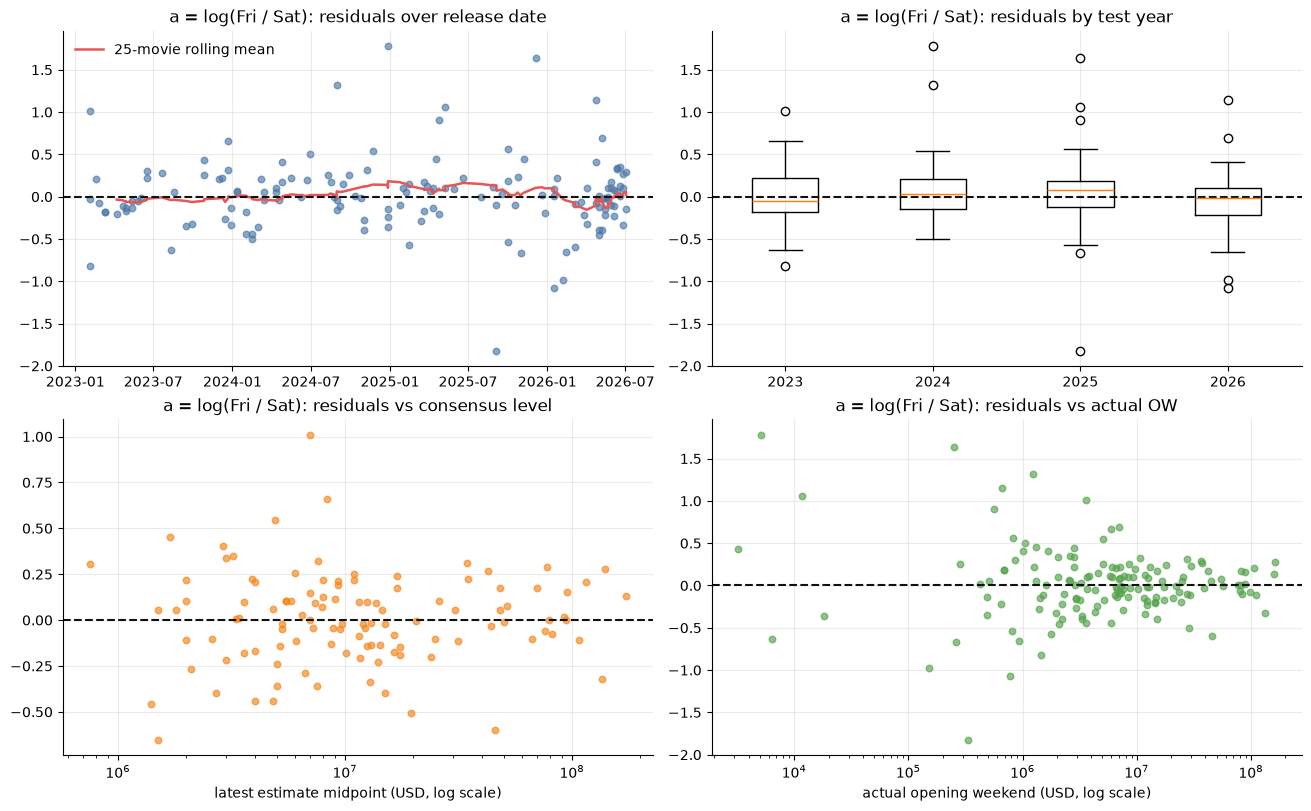

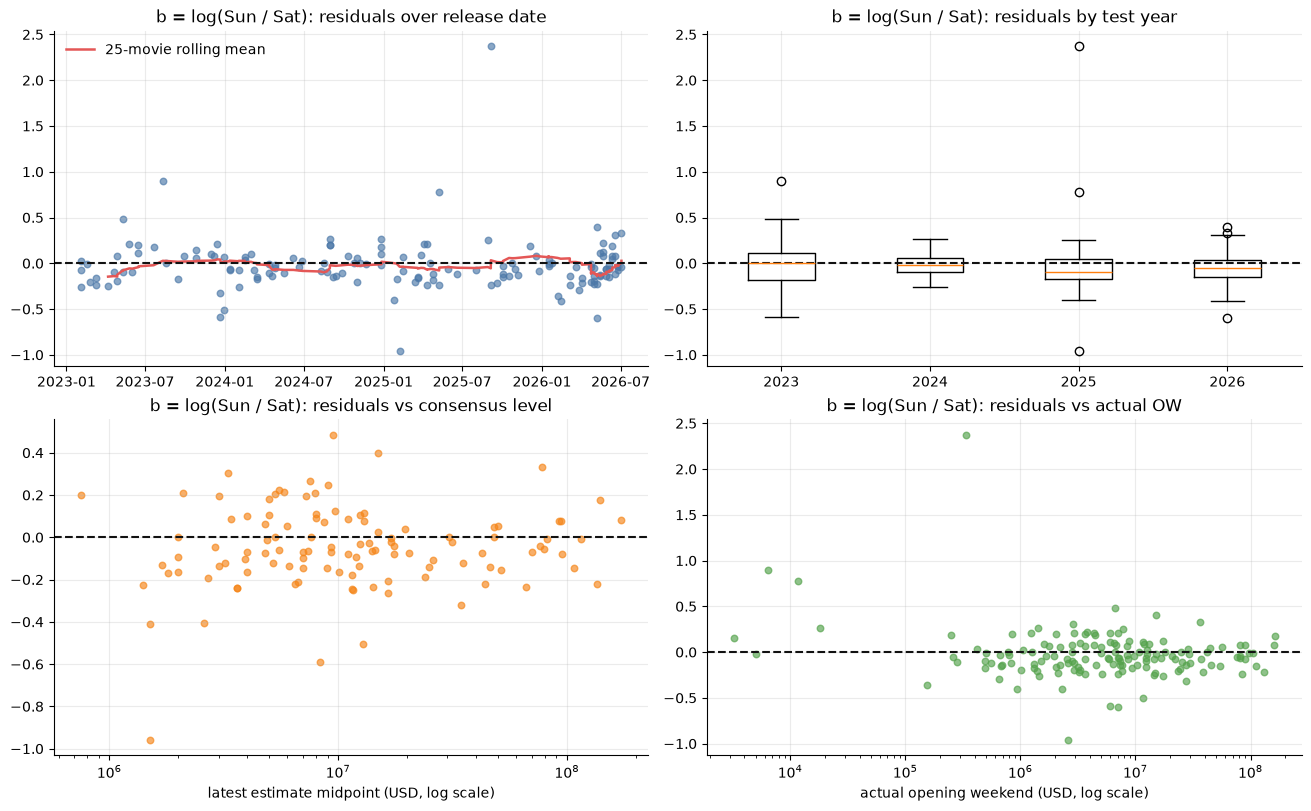

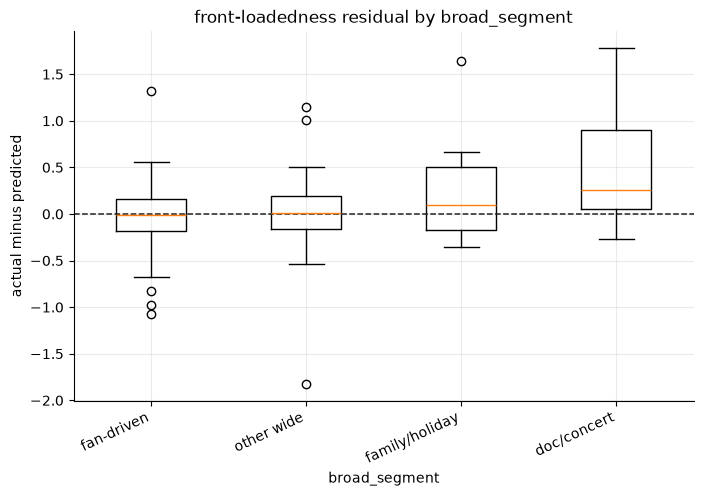

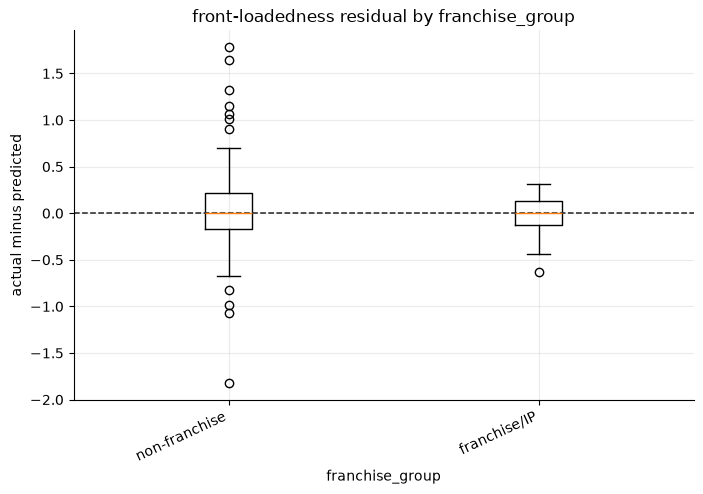

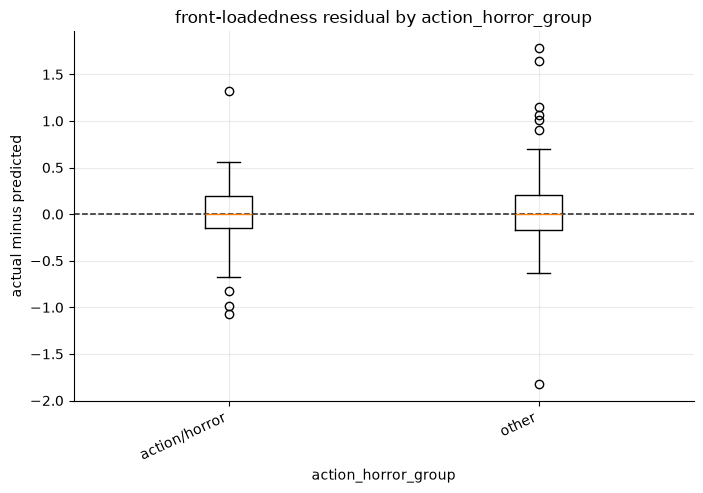

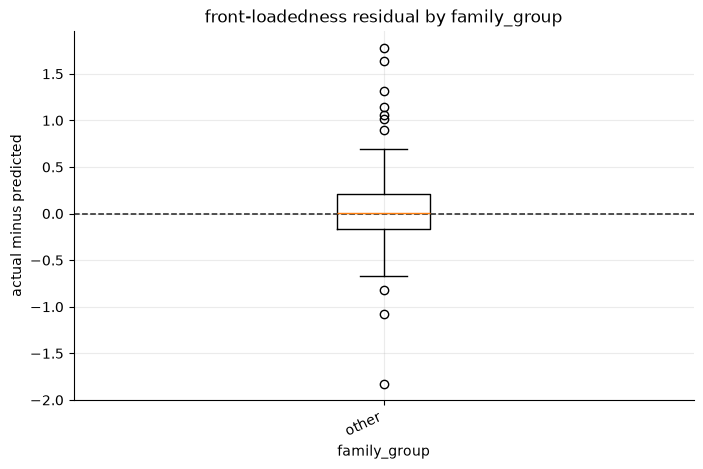

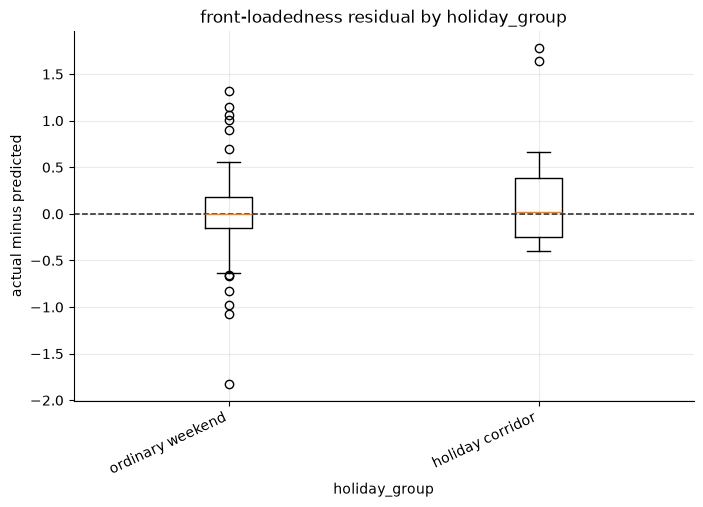

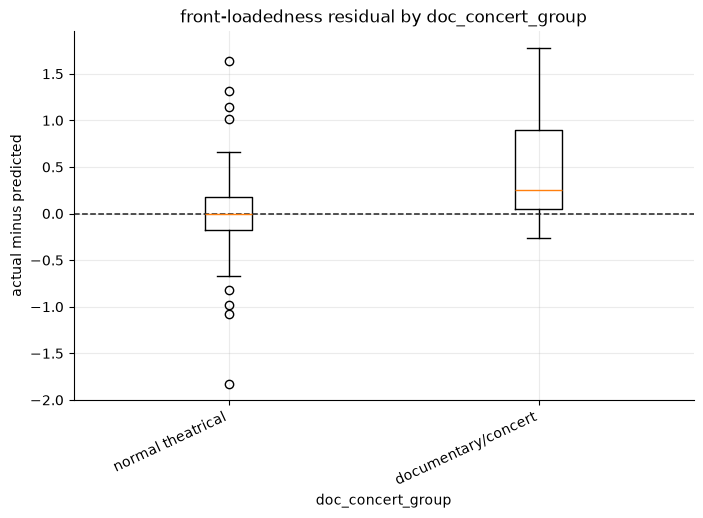

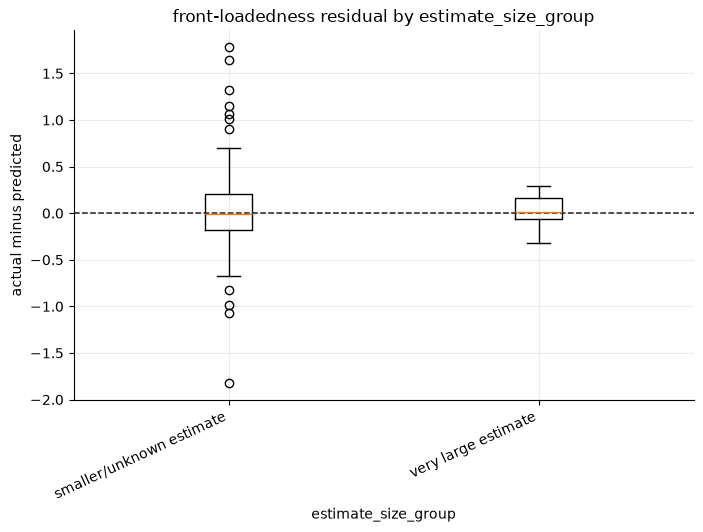

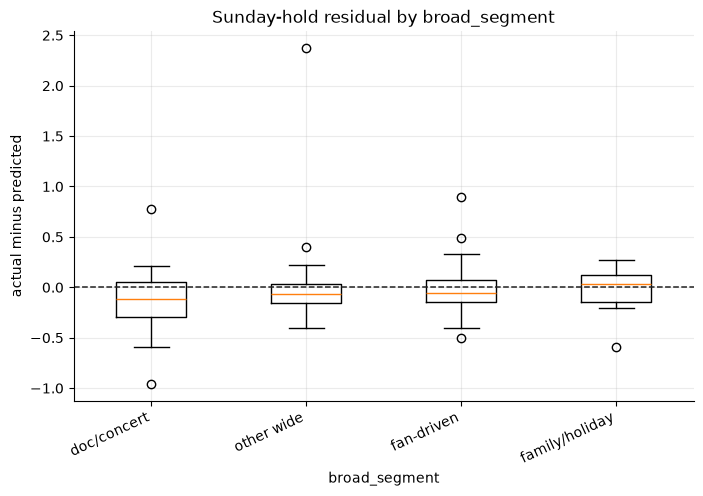

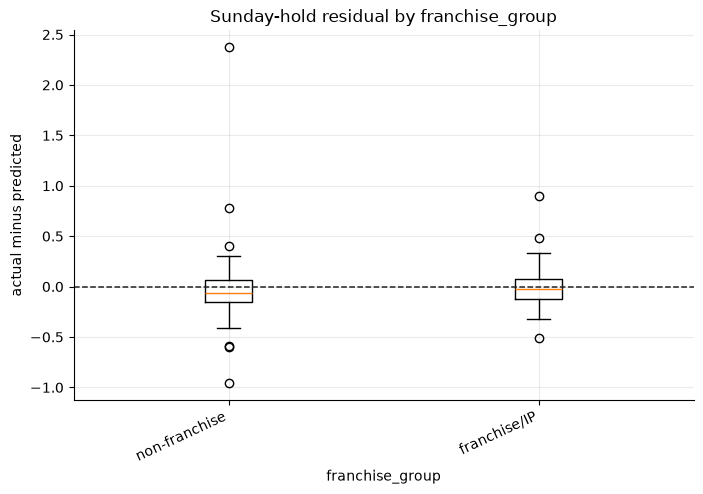

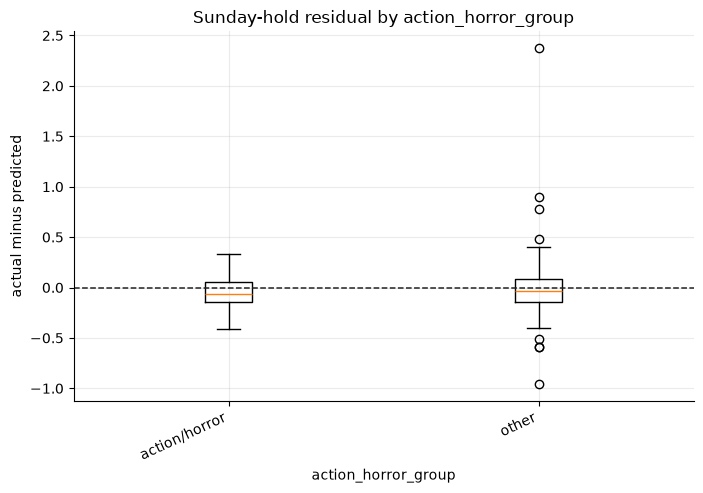

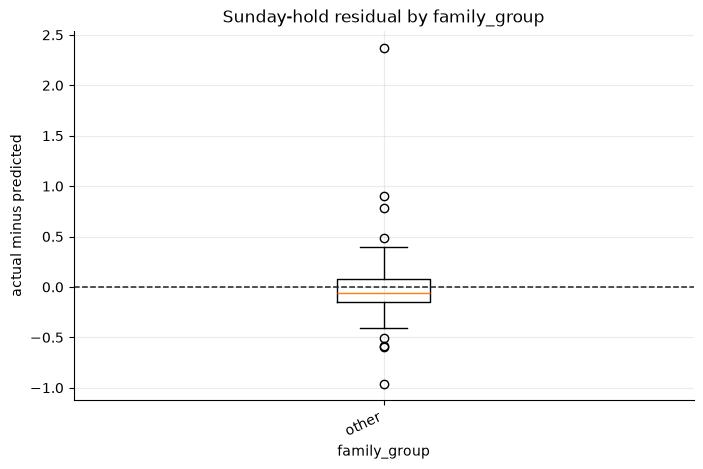

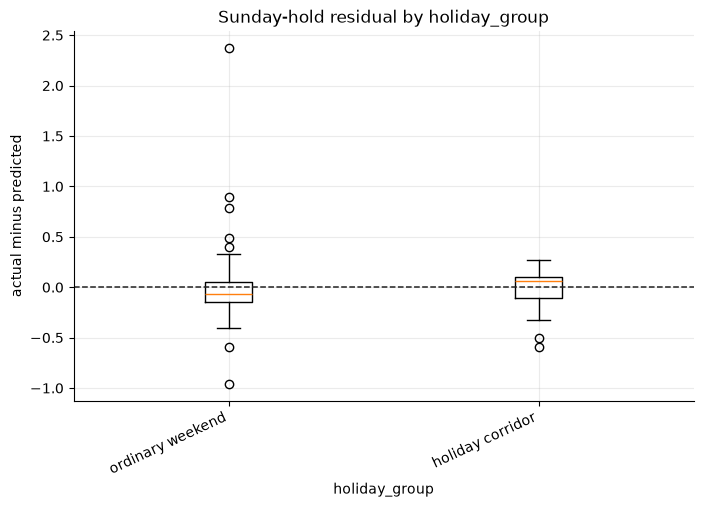

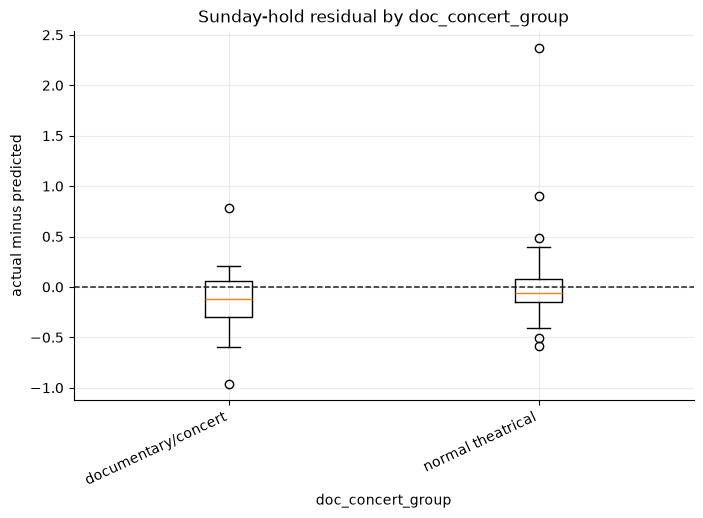

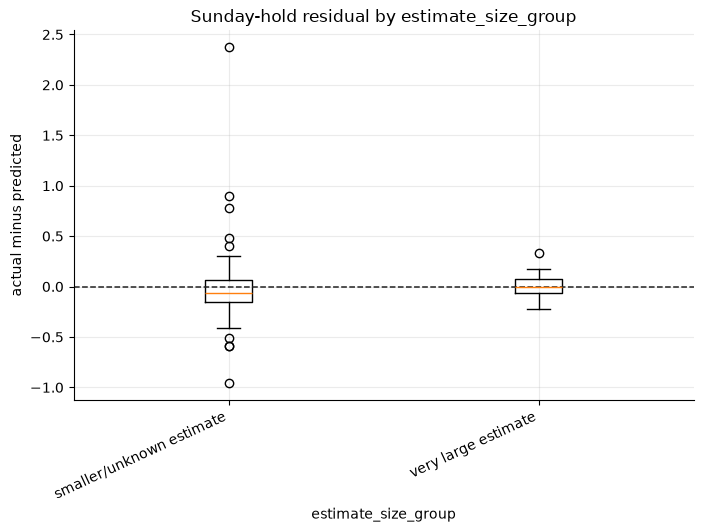

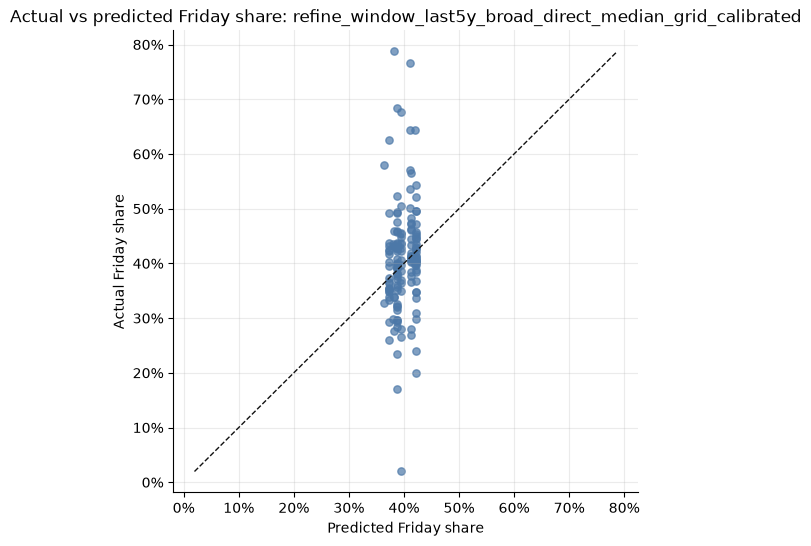

,test_year,broad_segment,n,mean_e_a,mean_e_b
0,2023,doc/concert,2,-0.005011,0.131499
1,2023,family/holiday,2,0.264596,-0.258680
2,2023,fan-driven,15,-0.031954,0.032544
3,2023,other wide,12,-0.007271,-0.046137
4,2024,doc/concert,2,0.963562,-0.082028
5,2024,family/holiday,4,-0.113699,0.042174
6,2024,fan-driven,23,0.029815,-0.006518
7,2024,other wide,9,0.102148,-0.036584
8,2025,doc/concert,3,0.672437,-0.098136
9,2025,family/holiday,2,1.045241,0.029102


In [123]:
diagnostic_model = globals().get("final_shape_prior_model", best_shape_model)
if "final_shape_prior_predictions" in globals() and diagnostic_model == final_shape_prior_model:
    shape_diag = final_shape_prior_predictions.copy()
else:
    shape_diag = shape_cv.loc[shape_cv["model"].eq(diagnostic_model)].copy()

residual_mean_check = final_preweekend_summary.loc[
    final_preweekend_summary["model"].isin([
        "benchmark_0_global_direct",
        "benchmark_1_broad_direct_logratio_calibrated",
        "refine_window_last5y_broad_direct_median_grid_calibrated",
        diagnostic_model,
    ]),
    ["model", "avg_abs_daily_dollar_error", "mean_e_a", "mean_e_b", "mae_log_fri_sat", "mae_log_sun_sat"],
].drop_duplicates()
display(residual_mean_check)


def residual_diagnostics(df, residual_col, title_prefix):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
    ax = axes[0, 0]
    ax.scatter(df["opening_weekend_start"], df[residual_col], s=22, alpha=0.65, color="#4c78a8")
    ordered = df.sort_values("opening_weekend_start")
    rolling = ordered[residual_col].rolling(25, min_periods=8).mean()
    ax.plot(ordered["opening_weekend_start"], rolling, color="#e45756", linewidth=1.8, label="25-movie rolling mean")
    ax.axhline(0, color="#111111", linestyle="--")
    ax.set_title(f"{title_prefix}: residuals over release date")
    ax.legend(frameon=False)
    ax = axes[0, 1]
    plot_df = df[["test_year", residual_col]].dropna()
    years = sorted(plot_df["test_year"].unique())
    ax.boxplot([plot_df.loc[plot_df["test_year"].eq(y), residual_col] for y in years], tick_labels=[str(int(y)) for y in years])
    ax.axhline(0, color="#111111", linestyle="--")
    ax.set_title(f"{title_prefix}: residuals by test year")
    ax = axes[1, 0]
    ax.scatter(df["latest_estimate_mid_usd"], df[residual_col], s=22, alpha=0.65, color="#f58518")
    ax.axhline(0, color="#111111", linestyle="--")
    ax.set_xscale("log")
    ax.set_title(f"{title_prefix}: residuals vs consensus level")
    ax.set_xlabel("latest estimate midpoint (USD, log scale)")
    ax = axes[1, 1]
    ax.scatter(df["opening_weekend_gross_usd"], df[residual_col], s=22, alpha=0.65, color="#54a24b")
    ax.axhline(0, color="#111111", linestyle="--")
    ax.set_xscale("log")
    ax.set_title(f"{title_prefix}: residuals vs actual OW")
    ax.set_xlabel("actual opening weekend (USD, log scale)")
    plt.show()

residual_diagnostics(shape_diag, "log_fri_sat_error", "a = log(Fri / Sat)")
residual_diagnostics(shape_diag, "log_sun_sat_error", "b = log(Sun / Sat)")

for residual_col, label in [("log_fri_sat_error", "front-loadedness residual"), ("log_sun_sat_error", "Sunday-hold residual")]:
    for group_col in ["broad_segment", "franchise_group", "action_horror_group", "family_group", "holiday_group", "doc_concert_group", "estimate_size_group"]:
        boxplot_ordered(shape_diag, group_col, residual_col, f"{label} by {group_col}", "actual minus predicted")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(shape_diag["pred_friday_share"], shape_diag["s_fri"], s=28, alpha=0.7, color="#4c78a8")
lo = min(shape_diag["pred_friday_share"].min(), shape_diag["s_fri"].min())
hi = max(shape_diag["pred_friday_share"].max(), shape_diag["s_fri"].max())
ax.plot([lo, hi], [lo, hi], color="#111111", linestyle="--", linewidth=1)
ax.set_title(f"Actual vs predicted Friday share: {diagnostic_model}")
ax.set_xlabel("Predicted Friday share")
ax.set_ylabel("Actual Friday share")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.show()

year_segment_residuals = (
    shape_diag.groupby(["test_year", "broad_segment"], observed=False)
    .agg(
        n=("release_run_id", "count"),
        mean_e_a=("log_fri_sat_error", "mean"),
        mean_e_b=("log_sun_sat_error", "mean"),
        mae_daily=("friday_dollar_error_shape_only", lambda s: np.nan),
    )
    .reset_index()
)
year_segment_residuals = year_segment_residuals.drop(columns=["mae_daily"])
display(year_segment_residuals)


## Operational Evaluation

Shape-only evaluation uses actual opening weekend gross to isolate the allocation model. Operational evaluation multiplies predicted shares by a late total forecast. If the by-origin late forecast export exists, this notebook uses raw consensus through day -3 and the log-rigor adjustment for later origins when available.

In [124]:
def load_operational_totals():
    if LATE_BY_ORIGIN_PATH.exists():
        panel = pd.read_csv(LATE_BY_ORIGIN_PATH)
        panel["opening_weekend_start"] = pd.to_datetime(panel["opening_weekend_start"], errors="coerce")
        panel["forecast_origin_day"] = pd.to_numeric(panel["forecast_origin_day"], errors="coerce")
        panel["total_forecast_usd"] = np.where(
            panel["forecast_origin_day"].le(-3),
            panel["origin_model_0_raw_forecast_usd"],
            panel["origin_model_1_log_rigor_forecast_usd"].fillna(panel["origin_model_0_raw_forecast_usd"]),
        )
        panel["total_forecast_source"] = "late_by_origin_common_predictions"
        return panel[[
            "release_run_id", "movie_id", "title", "opening_weekend_start", "forecast_origin_day",
            "forecast_origin_date", "actual_opening_weekend_gross_usd", "total_forecast_usd", "total_forecast_source",
        ]]
    if LATE_DAILY_ORIGIN_PATH.exists():
        panel = pd.read_csv(LATE_DAILY_ORIGIN_PATH)
        panel["opening_weekend_start"] = pd.to_datetime(panel["opening_weekend_start"], errors="coerce")
        panel["forecast_origin_day"] = pd.to_numeric(panel["forecast_origin_day"], errors="coerce")
        panel["total_forecast_usd"] = panel["consensus_estimate_origin_usd"]
        panel["total_forecast_source"] = "late_daily_origin_panel_raw_consensus"
        return panel[[
            "release_run_id", "movie_id", "title", "opening_weekend_start", "forecast_origin_day",
            "forecast_origin_date", "actual_opening_weekend_gross_usd", "total_forecast_usd", "total_forecast_source",
        ]]
    raise FileNotFoundError("No late forecast origin export found in data/diagnostics.")

operation_totals = load_operational_totals().dropna(subset=["release_run_id", "forecast_origin_day", "total_forecast_usd"])
operation_totals["release_run_id"] = operation_totals["release_run_id"].astype(float).astype(int)
operation_totals.shape, operation_totals["forecast_origin_day"].sort_values().unique()


((252, 9), array([-14,  -7,  -3,  -1]))

,forecast_origin_day,n_movies,mae_daily_dollar_error,rmse_daily_dollar_error,mean_total_forecast_error,mae_total_forecast_error
0,-14,49.0,2.478904e+06,3.972787e+06,-2.695322e+05,7.084519e+06
1,-7,50.0,2.101965e+06,3.182887e+06,-3.756478e+05,5.903396e+06
2,-3,50.0,2.102119e+06,3.154023e+06,-5.406478e+05,5.738396e+06
3,-1,103.0,1.386352e+06,2.600424e+06,1.455503e+06,3.388422e+06


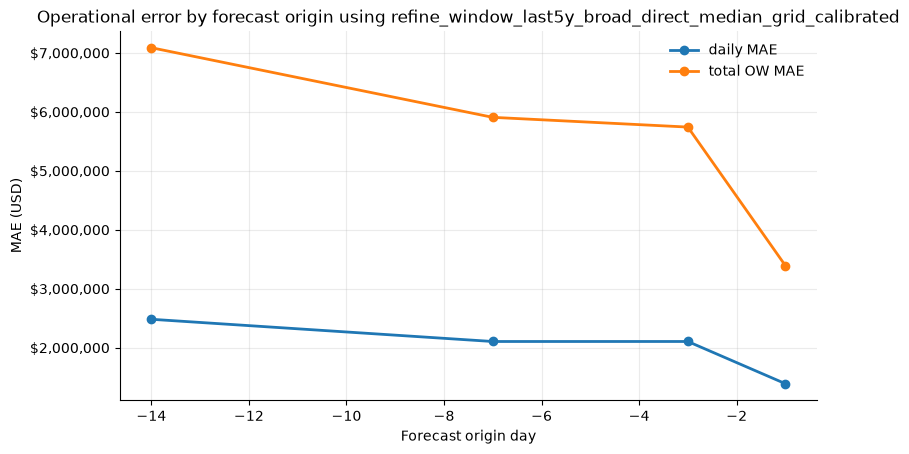

In [125]:
selected_preweekend_model = globals().get("final_shape_prior_model", globals().get("best_preweekend_refinement_model", best_shape_model))
if "freeze_check_cv" in globals() and selected_preweekend_model in set(freeze_check_cv["model"]):
    preweekend_prediction_source = freeze_check_cv
elif "refinement_cv" in globals() and selected_preweekend_model in set(refinement_cv["model"]):
    preweekend_prediction_source = refinement_cv
else:
    preweekend_prediction_source = shape_cv

shape_for_operation = preweekend_prediction_source.loc[preweekend_prediction_source["model"].eq(selected_preweekend_model), [
    "release_run_id", "model", "friday_gross_usd", "saturday_gross_usd", "sunday_gross_usd", *PRED_SHARE_COLS,
]].drop_duplicates("release_run_id")
shape_for_operation = shape_for_operation.rename(columns={"model": "shape_model"})

operational = operation_totals.merge(shape_for_operation, on="release_run_id", how="inner")
operational["pred_friday_gross"] = operational["total_forecast_usd"] * operational["pred_friday_share"]
operational["pred_saturday_gross"] = operational["total_forecast_usd"] * operational["pred_saturday_share"]
operational["pred_sunday_gross"] = operational["total_forecast_usd"] * operational["pred_sunday_share"]
operational["friday_error"] = operational["friday_gross_usd"] - operational["pred_friday_gross"]
operational["saturday_error"] = operational["saturday_gross_usd"] - operational["pred_saturday_gross"]
operational["sunday_error"] = operational["sunday_gross_usd"] - operational["pred_sunday_gross"]

op_summary = (
    operational.groupby("forecast_origin_day")
    .apply(lambda g: pd.Series({
        "n_movies": g["release_run_id"].nunique(),
        "mae_daily_dollar_error": pd.concat([
            g["friday_error"].abs(), g["saturday_error"].abs(), g["sunday_error"].abs()
        ], ignore_index=True).mean(),
        "rmse_daily_dollar_error": rmse(pd.concat([
            g["friday_error"], g["saturday_error"], g["sunday_error"]
        ], ignore_index=True)),
        "mean_total_forecast_error": (g["actual_opening_weekend_gross_usd"] - g["total_forecast_usd"]).mean(),
        "mae_total_forecast_error": (g["actual_opening_weekend_gross_usd"] - g["total_forecast_usd"]).abs().mean(),
    }))
    .reset_index()
    .sort_values("forecast_origin_day")
)

display(op_summary)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(op_summary["forecast_origin_day"], op_summary["mae_daily_dollar_error"], marker="o", linewidth=2, label="daily MAE")
ax.plot(op_summary["forecast_origin_day"], op_summary["mae_total_forecast_error"], marker="o", linewidth=2, label="total OW MAE")
ax.set_title(f"Operational error by forecast origin using {selected_preweekend_model}")
ax.set_xlabel("Forecast origin day")
ax.set_ylabel("MAE (USD)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.legend(frameon=False)
plt.show()


## In-Weekend Nowcast Baselines

The pre-weekend split model answers a different question from in-weekend nowcasting. Once Friday actuals are known, Friday belongs in the information set. Once Saturday actuals are known, only Sunday remains unknown.

This section evaluates three coherent historical-ratio baselines separately from the pre-weekend model:

- after Friday, share inversion: infer total weekend as `Friday / predicted Friday share`, then allocate the remaining weekend using the predicted Saturday/Sunday share split;
- after Friday, ratio model: predict `Saturday/Friday` and `Sunday/Friday` from historical log ratios;
- after Saturday, ratio model: predict `Sunday/Saturday` from historical log ratios.

These are not mixed with pre-release origin errors.

In [126]:
def median_logratio_by_segment(test, train, numerator_col, denominator_col, segment_col="segment_ip_doc", min_n=MIN_GROUP_N):
    train = train.copy()
    ratio_col = f"log_{numerator_col}_to_{denominator_col}"
    train[ratio_col] = np.log(train[numerator_col] / train[denominator_col])
    global_value = train[ratio_col].replace([np.inf, -np.inf], np.nan).dropna().median()
    segment_values = {}
    for group, gdf in train.groupby(segment_col, dropna=False, observed=False):
        clean = gdf[ratio_col].replace([np.inf, -np.inf], np.nan).dropna()
        min_group_n = DOC_CONCERT_MIN_N if group == "doc/concert" else min_n
        if len(clean) >= min_group_n:
            segment_values[group] = clean.median()
    return test[segment_col].map(segment_values).fillna(global_value)


def predict_after_friday_share_inversion(test, train):
    shares = predict_broad_direct_logratio_calibrated(test, train)
    pred = test[["release_run_id", "title", "test_year" if "test_year" in test.columns else "release_year"]].copy() if "test_year" in test.columns else test[["release_run_id", "title", "release_year"]].copy()
    friday_share = shares["pred_friday_share"].clip(lower=0.01)
    remaining_share = (shares["pred_saturday_share"] + shares["pred_sunday_share"]).clip(lower=0.01)
    pred["model"] = "nowcast_after_friday_share_inversion"
    pred["regime"] = "after_friday"
    pred["pred_friday_gross"] = test["friday_gross_usd"].values
    pred["pred_opening_weekend_gross"] = test["friday_gross_usd"].values / friday_share.values
    remaining_gross = (pred["pred_opening_weekend_gross"] - test["friday_gross_usd"].values).clip(lower=0)
    pred["pred_saturday_gross"] = remaining_gross * (shares["pred_saturday_share"].values / remaining_share.values)
    pred["pred_sunday_gross"] = remaining_gross * (shares["pred_sunday_share"].values / remaining_share.values)
    return pred


def predict_after_friday_ratio(test, train, segment_col="segment_ip_doc"):
    pred = test[["release_run_id", "title", "release_year"]].copy()
    sat_log = median_logratio_by_segment(test, train, "saturday_gross_usd", "friday_gross_usd", segment_col=segment_col)
    sun_log = median_logratio_by_segment(test, train, "sunday_gross_usd", "friday_gross_usd", segment_col=segment_col)
    pred["model"] = f"nowcast_after_friday_ratio_{segment_col}"
    pred["regime"] = "after_friday"
    pred["pred_friday_gross"] = test["friday_gross_usd"].values
    pred["pred_saturday_gross"] = test["friday_gross_usd"].values * np.exp(sat_log.values)
    pred["pred_sunday_gross"] = test["friday_gross_usd"].values * np.exp(sun_log.values)
    pred["pred_opening_weekend_gross"] = pred["pred_friday_gross"] + pred["pred_saturday_gross"] + pred["pred_sunday_gross"]
    return pred


def predict_after_saturday_ratio(test, train, segment_col="segment_ip_doc"):
    pred = test[["release_run_id", "title", "release_year"]].copy()
    sun_log = median_logratio_by_segment(test, train, "sunday_gross_usd", "saturday_gross_usd", segment_col=segment_col)
    pred["model"] = f"nowcast_after_saturday_ratio_{segment_col}"
    pred["regime"] = "after_saturday"
    pred["pred_friday_gross"] = test["friday_gross_usd"].values
    pred["pred_saturday_gross"] = test["saturday_gross_usd"].values
    pred["pred_sunday_gross"] = test["saturday_gross_usd"].values * np.exp(sun_log.values)
    pred["pred_opening_weekend_gross"] = pred["pred_friday_gross"] + pred["pred_saturday_gross"] + pred["pred_sunday_gross"]
    return pred


def add_nowcast_errors(actual, pred):
    out = pred.merge(
        actual[[
            "release_run_id", "opening_weekend_start", "release_year", "friday_gross_usd",
            "saturday_gross_usd", "sunday_gross_usd", "opening_weekend_gross_usd",
            "segment_ip_doc", "segment_ip_large_doc", "broad_segment",
        ]],
        on="release_run_id",
        how="left",
        suffixes=("", "_actual"),
    )
    out["friday_error"] = out["friday_gross_usd"] - out["pred_friday_gross"]
    out["saturday_error"] = out["saturday_gross_usd"] - out["pred_saturday_gross"]
    out["sunday_error"] = out["sunday_gross_usd"] - out["pred_sunday_gross"]
    out["opening_weekend_error"] = out["opening_weekend_gross_usd"] - out["pred_opening_weekend_gross"]
    return out


def rolling_nowcast_predictions(df):
    frames = []
    for test_year in sorted(y for y in df["release_year"].dropna().astype(int).unique() if y >= ROLLING_TEST_START_YEAR):
        train = df.loc[df["release_year"] < test_year].copy()
        test = df.loc[df["release_year"].eq(test_year)].copy()
        if len(train) < MIN_TRAIN_MOVIES or test.empty:
            continue
        preds = [
            predict_after_friday_share_inversion(test, train),
            predict_after_friday_ratio(test, train, segment_col="segment_ip_doc"),
            predict_after_friday_ratio(test, train, segment_col="segment_ip_large_doc"),
            predict_after_saturday_ratio(test, train, segment_col="segment_ip_doc"),
            predict_after_saturday_ratio(test, train, segment_col="segment_ip_large_doc"),
        ]
        for pred in preds:
            out = add_nowcast_errors(test, pred)
            out["fold"] = f"train_before_{test_year}__test_{test_year}"
            out["train_n"] = len(train)
            out["test_year"] = test_year
            frames.append(out)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

nowcast_cv = rolling_nowcast_predictions(shape_base)


def nowcast_metric_summary(df):
    rows = []
    for (regime, model), g in df.groupby(["regime", "model"]):
        if regime == "after_friday":
            remaining_errors = pd.concat([g["saturday_error"], g["sunday_error"]], ignore_index=True)
        else:
            remaining_errors = g["sunday_error"]
        rows.append({
            "regime": regime,
            "model": model,
            "n_movies": g["release_run_id"].nunique(),
            "mae_remaining_daily": remaining_errors.abs().mean(),
            "rmse_remaining_daily": rmse(remaining_errors),
            "mae_opening_weekend": g["opening_weekend_error"].abs().mean(),
            "mean_opening_weekend_error": g["opening_weekend_error"].mean(),
            "mae_saturday": g["saturday_error"].abs().mean() if regime == "after_friday" else np.nan,
            "mae_sunday": g["sunday_error"].abs().mean(),
        })
    return pd.DataFrame(rows).sort_values(["regime", "mae_remaining_daily", "mae_opening_weekend"])

nowcast_summary = nowcast_metric_summary(nowcast_cv)
display(nowcast_summary)


,regime,model,n_movies,mae_remaining_daily,rmse_remaining_daily,mae_opening_weekend,mean_opening_weekend_error,mae_saturday,mae_sunday
2,after_friday,nowcast_after_friday_share_inversion,148,1.312298e+06,3.064827e+06,2.567403e+06,-2.081656e+06,1.653523e+06,971072.924355
0,after_friday,nowcast_after_friday_ratio_segment_ip_doc,148,1.322985e+06,3.011330e+06,2.577881e+06,-2.123443e+06,1.724919e+06,921049.880136
1,after_friday,nowcast_after_friday_ratio_segment_ip_large_doc,148,1.434516e+06,3.503378e+06,2.829208e+06,-2.418549e+06,1.884225e+06,984807.102104
3,after_saturday,nowcast_after_saturday_ratio_segment_ip_doc,148,5.865574e+05,1.373714e+06,5.865574e+05,3.449019e+05,NaN,586557.430691
4,after_saturday,nowcast_after_saturday_ratio_segment_ip_large_doc,148,6.074907e+05,1.494321e+06,6.074907e+05,4.023861e+05,NaN,607490.673341


## In-Weekend Log-Bias Calibration and Intervals

The raw after-Friday and after-Saturday baselines are coherent, but their log residuals can still be biased. This section calibrates each nowcast model using only prior chronological nowcast errors inside the training fold.

- After Friday: calibrate opening-weekend gross with `log(actual OW / predicted OW)`, then allocate the calibrated remaining weekend across Saturday and Sunday using the raw future-day split.
- After Saturday: calibrate Sunday directly with `log(actual Sunday / predicted Sunday)`, then recompute opening weekend as Friday + Saturday + calibrated Sunday.

The same prior residual distributions provide simple empirical 80% and 95% prediction intervals for the relevant nowcast target. Log residuals are computed only where both the actual and predicted target are strictly positive; zero or negative values are invalid for this calibration and are excluded rather than clipped.

,regime,model,n_movies,mae_remaining_daily,rmse_remaining_daily,mae_opening_weekend,mean_opening_weekend_error,mae_saturday,mae_sunday
0,after_friday,nowcast_after_friday_share_inversion,148,1.312298e+06,3.064827e+06,2.567403e+06,-2.081656e+06,1.653523e+06,9.710729e+05
5,after_friday,nowcast_after_friday_ratio_segment_ip_doc_log_...,148,1.321442e+06,3.006530e+06,2.578380e+06,-2.122088e+06,1.723458e+06,9.194254e+05
1,after_friday,nowcast_after_friday_ratio_segment_ip_doc,148,1.322985e+06,3.011330e+06,2.577881e+06,-2.123443e+06,1.724919e+06,9.210499e+05
6,after_friday,nowcast_after_friday_share_inversion_log_bias_...,148,1.372948e+06,3.196710e+06,2.686421e+06,-2.236180e+06,1.723943e+06,1.021954e+06
2,after_friday,nowcast_after_friday_ratio_segment_ip_large_doc,148,1.434516e+06,3.503378e+06,2.829208e+06,-2.418549e+06,1.884225e+06,9.848071e+05
7,after_saturday,nowcast_after_saturday_ratio_segment_ip_doc_lo...,148,5.419970e+05,1.279848e+06,5.419970e+05,2.238745e+05,NaN,5.419970e+05
3,after_saturday,nowcast_after_saturday_ratio_segment_ip_doc,148,5.865574e+05,1.373714e+06,5.865574e+05,3.449019e+05,NaN,5.865574e+05
4,after_saturday,nowcast_after_saturday_ratio_segment_ip_large_doc,148,6.074907e+05,1.494321e+06,6.074907e+05,4.023861e+05,NaN,6.074907e+05


,regime,model,n,ow_80_coverage,ow_95_coverage,sun_80_coverage,sun_95_coverage,mean_log_bias_c,calibration_residual_n
0,after_friday,nowcast_after_friday_ratio_segment_ip_doc_log_...,148,0.560811,0.851351,NaN,NaN,0.000547,1319.128378
1,after_friday,nowcast_after_friday_share_inversion_log_bias_...,148,0.554054,0.878378,NaN,NaN,0.008406,1319.128378
2,after_saturday,nowcast_after_saturday_ratio_segment_ip_doc_lo...,148,0.770270,0.945946,0.77027,0.945946,0.028784,1319.128378


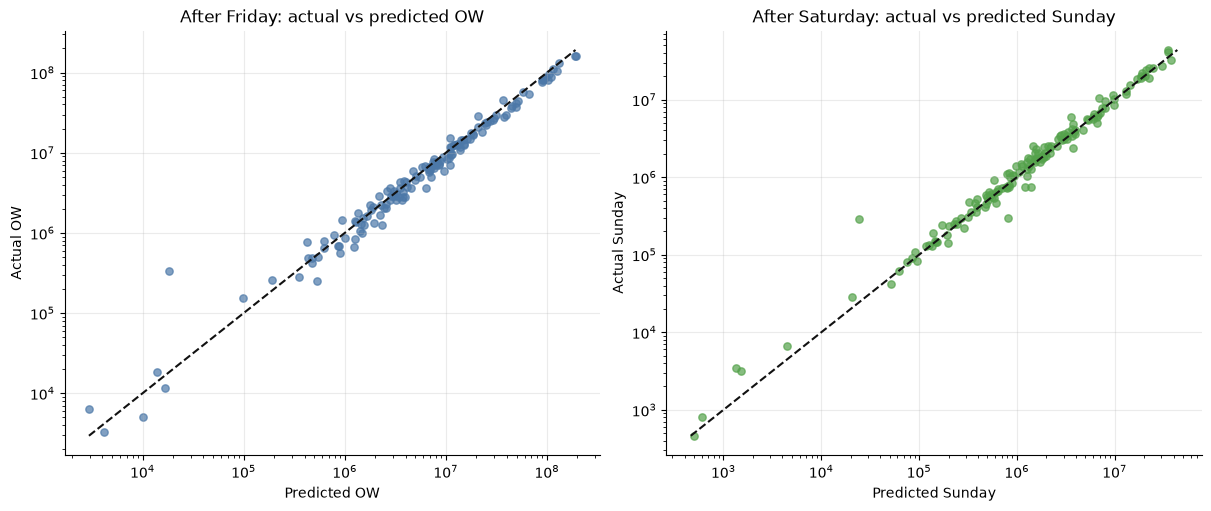

('nowcast_after_friday_share_inversion',
 'nowcast_after_saturday_ratio_segment_ip_doc_log_bias_calibrated')

In [127]:
NOWCAST_MODEL_SPECS = [
    {
        "model": "nowcast_after_friday_share_inversion",
        "regime": "after_friday",
        "predict": lambda test, train: predict_after_friday_share_inversion(test, train),
    },
    {
        "model": "nowcast_after_friday_ratio_segment_ip_doc",
        "regime": "after_friday",
        "predict": lambda test, train: predict_after_friday_ratio(test, train, segment_col="segment_ip_doc"),
    },
    {
        "model": "nowcast_after_saturday_ratio_segment_ip_doc",
        "regime": "after_saturday",
        "predict": lambda test, train: predict_after_saturday_ratio(test, train, segment_col="segment_ip_doc"),
    },
]


def nowcast_target_log_residuals(pred_with_actuals, regime):
    if regime == "after_friday":
        actual = pd.to_numeric(pred_with_actuals["opening_weekend_gross_usd"], errors="coerce")
        predicted = pd.to_numeric(pred_with_actuals["pred_opening_weekend_gross"], errors="coerce")
    elif regime == "after_saturday":
        actual = pd.to_numeric(pred_with_actuals["sunday_gross_usd"], errors="coerce")
        predicted = pd.to_numeric(pred_with_actuals["pred_sunday_gross"], errors="coerce")
    else:
        raise ValueError(regime)
    positive = actual.gt(0) & predicted.gt(0)
    residual = pd.Series(np.nan, index=pred_with_actuals.index, dtype="float64")
    residual.loc[positive] = np.log(actual.loc[positive] / predicted.loc[positive])
    return residual.replace([np.inf, -np.inf], np.nan)


def prior_nowcast_oos(train, spec):
    frames = []
    for validation_year in sorted(train["release_year"].dropna().astype(int).unique()):
        inner_train = train.loc[train["release_year"] < validation_year].copy()
        inner_test = train.loc[train["release_year"].eq(validation_year)].copy()
        if len(inner_train) < MIN_TRAIN_MOVIES or inner_test.empty:
            continue
        raw_pred = spec["predict"](inner_test, inner_train)
        out = add_nowcast_errors(inner_test, raw_pred)
        out["validation_year"] = validation_year
        frames.append(out)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def nowcast_calibration_from_prior(train, spec):
    prior = prior_nowcast_oos(train, spec)
    if prior.empty:
        return {
            "log_bias_c": 0.0,
            "interval_q10": np.nan,
            "interval_q90": np.nan,
            "interval_q025": np.nan,
            "interval_q975": np.nan,
            "calibration_residual_n": 0,
        }
    residual = nowcast_target_log_residuals(prior, spec["regime"]).dropna()
    if residual.empty:
        return {
            "log_bias_c": 0.0,
            "median_log_bias_c": np.nan,
            "interval_q10": np.nan,
            "interval_q90": np.nan,
            "interval_q025": np.nan,
            "interval_q975": np.nan,
            "calibration_residual_n": 0,
        }
    return {
        "log_bias_c": residual.mean(),
        "median_log_bias_c": residual.median(),
        "interval_q10": residual.quantile(0.10),
        "interval_q90": residual.quantile(0.90),
        "interval_q025": residual.quantile(0.025),
        "interval_q975": residual.quantile(0.975),
        "calibration_residual_n": len(residual),
    }


def apply_nowcast_log_calibration(raw_pred, calibration, regime):
    out = raw_pred.copy()
    c = calibration["log_bias_c"]
    if regime == "after_friday":
        raw_future = (out["pred_saturday_gross"] + out["pred_sunday_gross"]).clip(lower=1)
        sat_weight = out["pred_saturday_gross"] / raw_future
        sun_weight = out["pred_sunday_gross"] / raw_future
        out["pred_opening_weekend_gross"] = out["pred_opening_weekend_gross"] * np.exp(c)
        remaining = (out["pred_opening_weekend_gross"] - out["pred_friday_gross"]).clip(lower=0)
        out["pred_saturday_gross"] = remaining * sat_weight
        out["pred_sunday_gross"] = remaining * sun_weight
        for lo_col, q in [("ow_80_lower", calibration["interval_q10"]), ("ow_80_upper", calibration["interval_q90"]), ("ow_95_lower", calibration["interval_q025"]), ("ow_95_upper", calibration["interval_q975"] )]:
            out[lo_col] = out["pred_opening_weekend_gross"] * np.exp(q - c)
    elif regime == "after_saturday":
        out["pred_sunday_gross"] = out["pred_sunday_gross"] * np.exp(c)
        out["pred_opening_weekend_gross"] = out["pred_friday_gross"] + out["pred_saturday_gross"] + out["pred_sunday_gross"]
        out["sun_80_lower"] = out["pred_sunday_gross"] * np.exp(calibration["interval_q10"] - c)
        out["sun_80_upper"] = out["pred_sunday_gross"] * np.exp(calibration["interval_q90"] - c)
        out["sun_95_lower"] = out["pred_sunday_gross"] * np.exp(calibration["interval_q025"] - c)
        out["sun_95_upper"] = out["pred_sunday_gross"] * np.exp(calibration["interval_q975"] - c)
        out["ow_80_lower"] = out["pred_friday_gross"] + out["pred_saturday_gross"] + out["sun_80_lower"]
        out["ow_80_upper"] = out["pred_friday_gross"] + out["pred_saturday_gross"] + out["sun_80_upper"]
        out["ow_95_lower"] = out["pred_friday_gross"] + out["pred_saturday_gross"] + out["sun_95_lower"]
        out["ow_95_upper"] = out["pred_friday_gross"] + out["pred_saturday_gross"] + out["sun_95_upper"]
    else:
        raise ValueError(regime)
    out["model"] = out["model"] + "_log_bias_calibrated"
    for key, value in calibration.items():
        out[key] = value
    return out


def rolling_calibrated_nowcast_predictions(df, specs=NOWCAST_MODEL_SPECS):
    frames = []
    for test_year in sorted(y for y in df["release_year"].dropna().astype(int).unique() if y >= ROLLING_TEST_START_YEAR):
        train = df.loc[df["release_year"] < test_year].copy()
        test = df.loc[df["release_year"].eq(test_year)].copy()
        if len(train) < MIN_TRAIN_MOVIES or test.empty:
            continue
        for spec in specs:
            raw_pred = spec["predict"](test, train)
            calibration = nowcast_calibration_from_prior(train, spec)
            calibrated_pred = apply_nowcast_log_calibration(raw_pred, calibration, spec["regime"])
            out = add_nowcast_errors(test, calibrated_pred)
            out["fold"] = f"train_before_{test_year}__test_{test_year}"
            out["train_n"] = len(train)
            out["test_year"] = test_year
            out["calibration_target"] = "opening_weekend_log" if spec["regime"] == "after_friday" else "sunday_log"
            frames.append(out)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

nowcast_calibrated_cv = rolling_calibrated_nowcast_predictions(shape_base)
nowcast_calibrated_summary = nowcast_metric_summary(nowcast_calibrated_cv)
combined_nowcast_summary = pd.concat([nowcast_summary, nowcast_calibrated_summary], ignore_index=True).sort_values(
    ["regime", "mae_remaining_daily", "mae_opening_weekend"]
)
display(combined_nowcast_summary)


def interval_coverage_table(df):
    rows = []
    for (regime, model), g in df.groupby(["regime", "model"]):
        rows.append({
            "regime": regime,
            "model": model,
            "n": len(g),
            "ow_80_coverage": ((g["opening_weekend_gross_usd"] >= g["ow_80_lower"]) & (g["opening_weekend_gross_usd"] <= g["ow_80_upper"])).mean(),
            "ow_95_coverage": ((g["opening_weekend_gross_usd"] >= g["ow_95_lower"]) & (g["opening_weekend_gross_usd"] <= g["ow_95_upper"])).mean(),
            "sun_80_coverage": ((g["sunday_gross_usd"] >= g.get("sun_80_lower", np.nan)) & (g["sunday_gross_usd"] <= g.get("sun_80_upper", np.nan))).mean() if regime == "after_saturday" else np.nan,
            "sun_95_coverage": ((g["sunday_gross_usd"] >= g.get("sun_95_lower", np.nan)) & (g["sunday_gross_usd"] <= g.get("sun_95_upper", np.nan))).mean() if regime == "after_saturday" else np.nan,
            "mean_log_bias_c": g["log_bias_c"].mean(),
            "calibration_residual_n": g["calibration_residual_n"].mean(),
        })
    return pd.DataFrame(rows).sort_values(["regime", "model"])

nowcast_interval_coverage = interval_coverage_table(nowcast_calibrated_cv)
display(nowcast_interval_coverage)

best_after_friday_model = combined_nowcast_summary.loc[combined_nowcast_summary["regime"].eq("after_friday")].iloc[0]["model"]
best_after_saturday_model = combined_nowcast_summary.loc[combined_nowcast_summary["regime"].eq("after_saturday")].iloc[0]["model"]

nowcast_plot_source = pd.concat([nowcast_cv, nowcast_calibrated_cv], ignore_index=True, sort=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
after_friday_diag = nowcast_plot_source.loc[nowcast_plot_source["model"].eq(best_after_friday_model)].copy()
after_friday_diag = after_friday_diag.loc[
    after_friday_diag["pred_opening_weekend_gross"].gt(0)
    & after_friday_diag["opening_weekend_gross_usd"].gt(0)
]
axes[0].scatter(after_friday_diag["pred_opening_weekend_gross"], after_friday_diag["opening_weekend_gross_usd"], s=28, alpha=0.7, color="#4c78a8")
lo = min(after_friday_diag["pred_opening_weekend_gross"].min(), after_friday_diag["opening_weekend_gross_usd"].min())
hi = max(after_friday_diag["pred_opening_weekend_gross"].max(), after_friday_diag["opening_weekend_gross_usd"].max())
axes[0].plot([lo, hi], [lo, hi], color="#111111", linestyle="--")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("After Friday: actual vs predicted OW")
axes[0].set_xlabel("Predicted OW")
axes[0].set_ylabel("Actual OW")

after_saturday_diag = nowcast_plot_source.loc[nowcast_plot_source["model"].eq(best_after_saturday_model)].copy()
after_saturday_diag = after_saturday_diag.loc[
    after_saturday_diag["pred_sunday_gross"].gt(0)
    & after_saturday_diag["sunday_gross_usd"].gt(0)
]
axes[1].scatter(after_saturday_diag["pred_sunday_gross"], after_saturday_diag["sunday_gross_usd"], s=28, alpha=0.7, color="#54a24b")
lo = min(after_saturday_diag["pred_sunday_gross"].min(), after_saturday_diag["sunday_gross_usd"].min())
hi = max(after_saturday_diag["pred_sunday_gross"].max(), after_saturday_diag["sunday_gross_usd"].max())
axes[1].plot([lo, hi], [lo, hi], color="#111111", linestyle="--")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("After Saturday: actual vs predicted Sunday")
axes[1].set_xlabel("Predicted Sunday")
axes[1].set_ylabel("Actual Sunday")
plt.show()

best_after_friday_model, best_after_saturday_model


## Export Candidate Outputs

These exports let downstream notebooks compare shape-only performance and operational top-down daily forecasts without re-running every plot.

In [128]:
output_dir = DIAGNOSTICS_DIR
output_dir.mkdir(parents=True, exist_ok=True)

shape_base_export = output_dir / "weekend_shape_base.csv"
shape_cv_export = output_dir / "weekend_shape_chronological_predictions.csv"
shape_summary_export = output_dir / "weekend_shape_benchmark_summary.csv"
refinement_cv_export = output_dir / "weekend_shape_refinement_predictions.csv"
refinement_summary_export = output_dir / "weekend_shape_refinement_summary.csv"
operational_export = output_dir / "weekend_shape_operational_predictions.csv"
operational_summary_export = output_dir / "weekend_shape_operational_summary.csv"
nowcast_cv_export = output_dir / "weekend_shape_nowcast_predictions.csv"
nowcast_summary_export = output_dir / "weekend_shape_nowcast_summary.csv"
freeze_check_cv_export = output_dir / "weekend_shape_freeze_check_predictions.csv"
freeze_check_summary_export = output_dir / "weekend_shape_freeze_check_summary.csv"
nowcast_calibrated_cv_export = output_dir / "weekend_shape_nowcast_calibrated_predictions.csv"
nowcast_calibrated_summary_export = output_dir / "weekend_shape_nowcast_calibrated_summary.csv"
nowcast_interval_coverage_export = output_dir / "weekend_shape_nowcast_interval_coverage.csv"

shape_base.to_csv(shape_base_export, index=False)
shape_cv.to_csv(shape_cv_export, index=False)
shape_summary.to_csv(shape_summary_export, index=False)
operational.to_csv(operational_export, index=False)
op_summary.to_csv(operational_summary_export, index=False)

optional_exports = []
if "refinement_cv" in globals() and not refinement_cv.empty:
    refinement_cv.to_csv(refinement_cv_export, index=False)
    refinement_summary.to_csv(refinement_summary_export, index=False)
    optional_exports.extend([refinement_cv_export, refinement_summary_export])
if "freeze_check_cv" in globals() and not freeze_check_cv.empty:
    freeze_check_cv.to_csv(freeze_check_cv_export, index=False)
    freeze_check_summary.to_csv(freeze_check_summary_export, index=False)
    optional_exports.extend([freeze_check_cv_export, freeze_check_summary_export])
if "nowcast_cv" in globals() and not nowcast_cv.empty:
    nowcast_cv.to_csv(nowcast_cv_export, index=False)
    nowcast_summary.to_csv(nowcast_summary_export, index=False)
    optional_exports.extend([nowcast_cv_export, nowcast_summary_export])
if "nowcast_calibrated_cv" in globals() and not nowcast_calibrated_cv.empty:
    nowcast_calibrated_cv.to_csv(nowcast_calibrated_cv_export, index=False)
    nowcast_calibrated_summary.to_csv(nowcast_calibrated_summary_export, index=False)
    nowcast_interval_coverage.to_csv(nowcast_interval_coverage_export, index=False)
    optional_exports.extend([nowcast_calibrated_cv_export, nowcast_calibrated_summary_export, nowcast_interval_coverage_export])

exports = [
    shape_base_export,
    shape_cv_export,
    shape_summary_export,
    *optional_exports,
    operational_export,
    operational_summary_export,
]

pd.DataFrame({
    "artifact": [path.name for path in exports],
    "path": [str(path) for path in exports],
})


,artifact,path
0,weekend_shape_base.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...
1,weekend_shape_chronological_predictions.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...
2,weekend_shape_benchmark_summary.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...
3,weekend_shape_refinement_predictions.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...
4,weekend_shape_refinement_summary.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...
5,weekend_shape_freeze_check_predictions.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...
6,weekend_shape_freeze_check_summary.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...
7,weekend_shape_nowcast_predictions.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...
8,weekend_shape_nowcast_summary.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...
9,weekend_shape_nowcast_calibrated_predictions.csv,/Users/andreasboscariol/Desktop/PolyMarket/pm-...


## Reading the First Pass

The decision rule for this notebook is intentionally conservative:

1. Keep `benchmark_0_global_direct` as the benchmark reference.
2. Promote `refine_window_last5y_broad_direct_median_grid_calibrated` to `WeekendShapePrior v1` unless the freeze-readiness checks beat it on genuine shape-only validation without adding predictors.
3. Treat `benchmark_1_broad_direct_logratio_calibrated` as the demoted old working baseline.
4. Prefer pre-weekend priors by shape-only average absolute daily dollar error, with average absolute share error and residual means in $a=\log(Fri/Sat)$ and $b=\log(Sun/Sat)$ as diagnostics.
5. Evaluate after-Friday and after-Saturday nowcasts separately from pre-weekend allocation because they use different information sets and forecast horizons.
6. Before freezing, check per-year residual stability, segment residuals, size residuals, log-bias-calibrated nowcast performance, and interval coverage.
7. Do not add movie-level predictors until this baseline stack is frozen and documented as the hard-to-beat reference.

## Frozen Baseline Stack Diagnostics

This final reporting block freezes the baseline stack and produces the targeted diagnostics for the selected shape prior and in-weekend nowcasts.

,layer,choice
0,Benchmark reference,benchmark_0_global_direct
1,Demoted old baseline,benchmark_1_broad_direct_logratio_calibrated
2,Shape prior baseline,refine_window_last5y_broad_direct_median_grid_...
3,After-Friday OW nowcast,nowcast_after_friday_share_inversion
4,After-Saturday OW nowcast,nowcast_after_saturday_ratio_segment_ip_doc_lo...


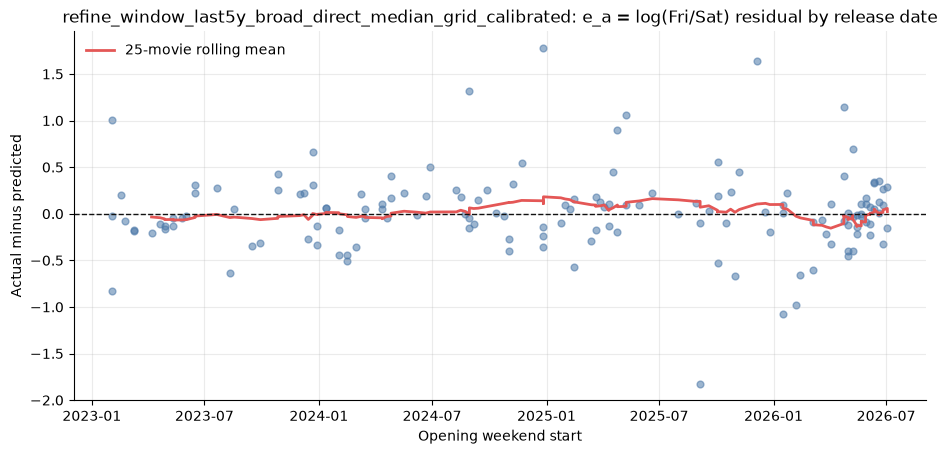

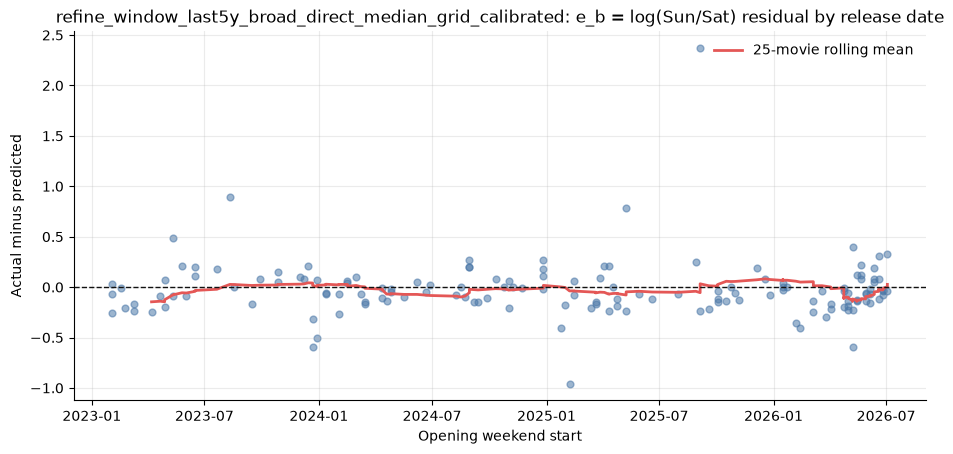

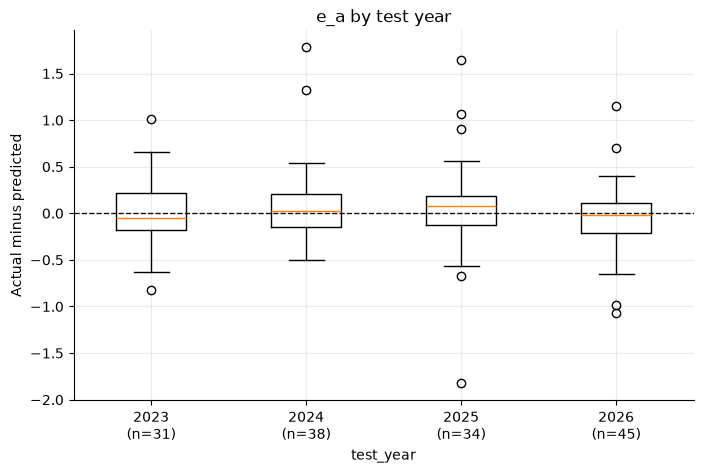

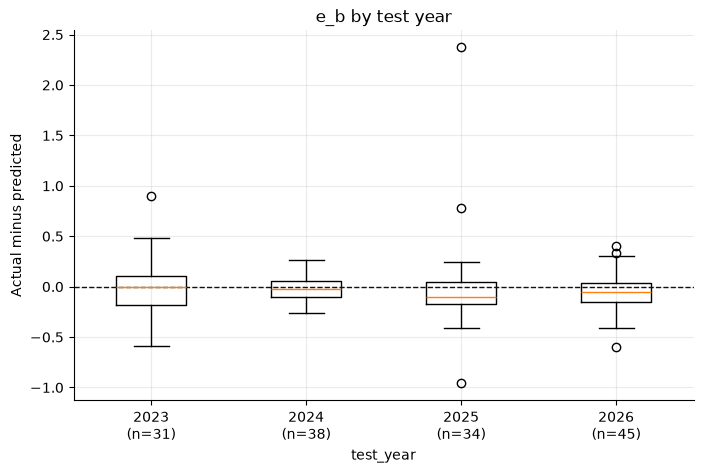

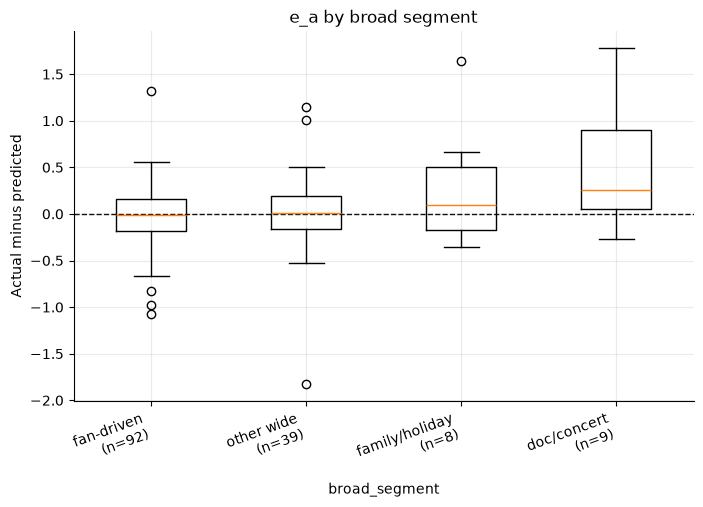

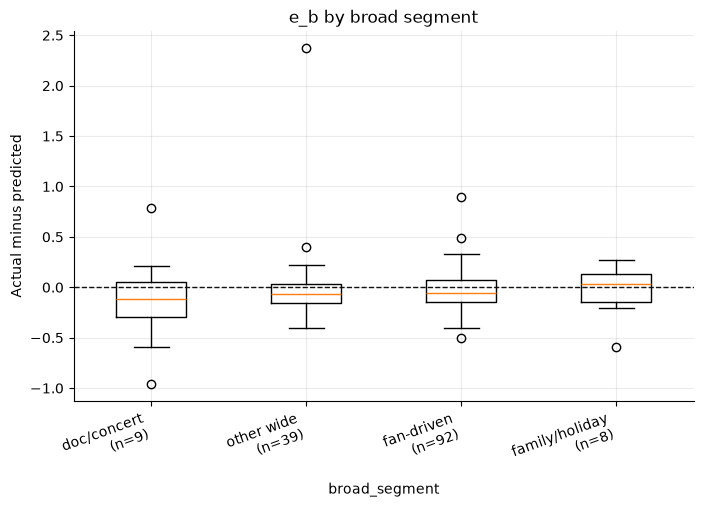

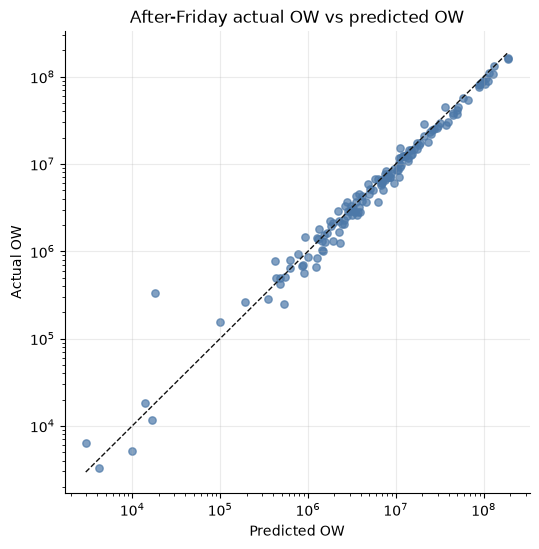

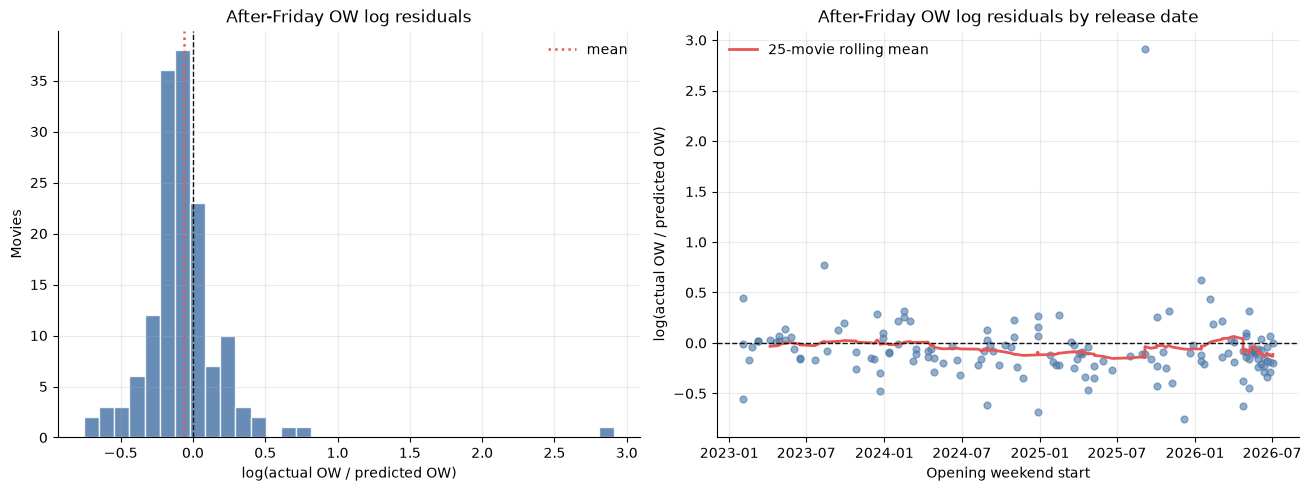

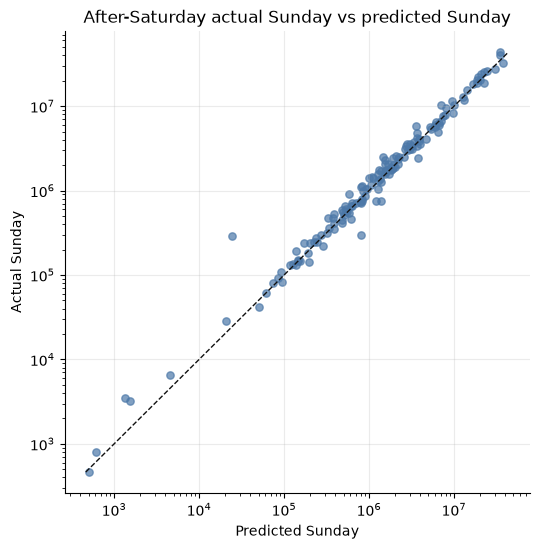

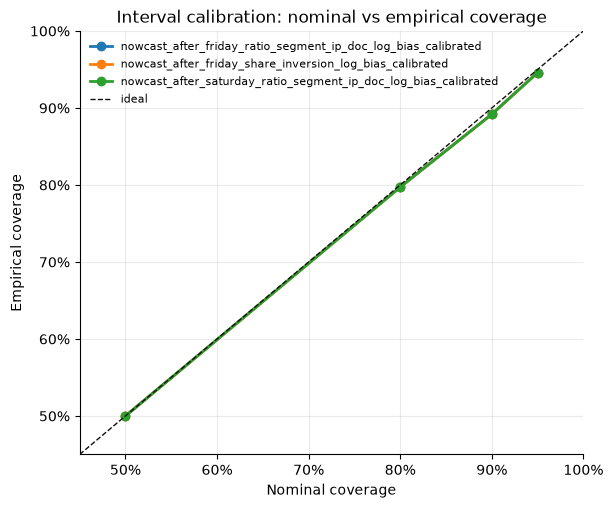

,regime,model,nominal_coverage,empirical_coverage,n
0,after_friday,nowcast_after_friday_share_inversion_log_bias_...,0.50,0.500000,148
1,after_friday,nowcast_after_friday_share_inversion_log_bias_...,0.80,0.797297,148
2,after_friday,nowcast_after_friday_share_inversion_log_bias_...,0.90,0.891892,148
3,after_friday,nowcast_after_friday_share_inversion_log_bias_...,0.95,0.945946,148
4,after_friday,nowcast_after_friday_ratio_segment_ip_doc_log_...,0.50,0.500000,148
5,after_friday,nowcast_after_friday_ratio_segment_ip_doc_log_...,0.80,0.797297,148
6,after_friday,nowcast_after_friday_ratio_segment_ip_doc_log_...,0.90,0.891892,148
7,after_friday,nowcast_after_friday_ratio_segment_ip_doc_log_...,0.95,0.945946,148
8,after_saturday,nowcast_after_saturday_ratio_segment_ip_doc_lo...,0.50,0.500000,148
9,after_saturday,nowcast_after_saturday_ratio_segment_ip_doc_lo...,0.80,0.797297,148


In [129]:
FROZEN_BASELINE_STACK = pd.DataFrame(
    [
        {"layer": "Benchmark reference", "choice": "benchmark_0_global_direct"},
        {"layer": "Demoted old baseline", "choice": "benchmark_1_broad_direct_logratio_calibrated"},
        {"layer": "Shape prior baseline", "choice": "refine_window_last5y_broad_direct_median_grid_calibrated"},
        {"layer": "After-Friday OW nowcast", "choice": "nowcast_after_friday_share_inversion"},
        {"layer": "After-Saturday OW nowcast", "choice": "nowcast_after_saturday_ratio_segment_ip_doc_log_bias_calibrated"},
    ]
)
display(FROZEN_BASELINE_STACK)

FROZEN_SHAPE_PRIOR = "refine_window_last5y_broad_direct_median_grid_calibrated"
FROZEN_AFTER_FRIDAY = "nowcast_after_friday_share_inversion"
FROZEN_AFTER_SATURDAY = "nowcast_after_saturday_ratio_segment_ip_doc_log_bias_calibrated"

if "refinement_cv" not in globals() or refinement_cv.empty:
    raise RuntimeError("Run the pre-weekend refinement grid before this reporting block.")
if "nowcast_cv" not in globals() or nowcast_cv.empty:
    raise RuntimeError("Run the in-weekend nowcast baseline block before this reporting block.")
if "nowcast_calibrated_cv" not in globals() or nowcast_calibrated_cv.empty:
    raise RuntimeError("Run the in-weekend log-bias calibration block before this reporting block.")

shape_prior_diag = refinement_cv.loc[refinement_cv["model"].eq(FROZEN_SHAPE_PRIOR)].copy()
if shape_prior_diag.empty:
    raise ValueError(f"No predictions found for {FROZEN_SHAPE_PRIOR}.")

after_friday_diag = nowcast_cv.loc[nowcast_cv["model"].eq(FROZEN_AFTER_FRIDAY)].copy()
after_saturday_diag = nowcast_calibrated_cv.loc[nowcast_calibrated_cv["model"].eq(FROZEN_AFTER_SATURDAY)].copy()
if after_friday_diag.empty:
    raise ValueError(f"No predictions found for {FROZEN_AFTER_FRIDAY}.")
if after_saturday_diag.empty:
    raise ValueError(f"No predictions found for {FROZEN_AFTER_SATURDAY}.")

# Shape-prior residuals by release date with rolling mean.
def plot_shape_residual_over_time(df, residual_col, label):
    ordered = df.sort_values("opening_weekend_start").copy()
    rolling = ordered[residual_col].rolling(25, min_periods=8).mean()
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.scatter(ordered["opening_weekend_start"], ordered[residual_col], s=24, alpha=0.55, color="#4c78a8")
    ax.plot(ordered["opening_weekend_start"], rolling, color="#e45756", linewidth=2, label="25-movie rolling mean")
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_title(f"{FROZEN_SHAPE_PRIOR}: {label} by release date")
    ax.set_xlabel("Opening weekend start")
    ax.set_ylabel("Actual minus predicted")
    ax.legend(frameon=False)
    plt.show()

plot_shape_residual_over_time(shape_prior_diag, "log_fri_sat_error", "e_a = log(Fri/Sat) residual")
plot_shape_residual_over_time(shape_prior_diag, "log_sun_sat_error", "e_b = log(Sun/Sat) residual")

# Boxplots by test year.
def boxplot_residual_by_group(df, residual_col, group_col, title, ylabel="Actual minus predicted", annotate_n=True):
    plot_df = df[[group_col, residual_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if plot_df.empty:
        print(f"No data for {title}")
        return
    if group_col == "test_year":
        order = sorted(plot_df[group_col].unique())
    else:
        order = plot_df.groupby(group_col, observed=False)[residual_col].median().sort_values().index.tolist()
    labels = []
    data = []
    for group in order:
        values = plot_df.loc[plot_df[group_col].eq(group), residual_col].dropna()
        if values.empty:
            continue
        data.append(values)
        label = str(int(group)) if group_col == "test_year" else str(group)
        if annotate_n:
            label = f"{label}\n(n={len(values)})"
        labels.append(label)
    fig, ax = plt.subplots(figsize=(max(8, 1.4 * len(labels)), 4.8))
    ax.boxplot(data, tick_labels=labels, showfliers=True)
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=20 if group_col != "test_year" else 0, ha="right" if group_col != "test_year" else "center")
    plt.show()

boxplot_residual_by_group(shape_prior_diag, "log_fri_sat_error", "test_year", "e_a by test year")
boxplot_residual_by_group(shape_prior_diag, "log_sun_sat_error", "test_year", "e_b by test year")
boxplot_residual_by_group(shape_prior_diag, "log_fri_sat_error", "broad_segment", "e_a by broad segment")
boxplot_residual_by_group(shape_prior_diag, "log_sun_sat_error", "broad_segment", "e_b by broad segment")

# After-Friday actual OW vs predicted OW.
def plot_actual_vs_predicted(df, actual_col, pred_col, title, xlabel, ylabel):
    plot_df = df[[actual_col, pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
    plot_df = plot_df.loc[plot_df[actual_col].gt(0) & plot_df[pred_col].gt(0)]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(plot_df[pred_col], plot_df[actual_col], s=28, alpha=0.7, color="#4c78a8")
    lo = min(plot_df[pred_col].min(), plot_df[actual_col].min())
    hi = max(plot_df[pred_col].max(), plot_df[actual_col].max())
    ax.plot([lo, hi], [lo, hi], color="#111111", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.show()

plot_actual_vs_predicted(
    after_friday_diag,
    "opening_weekend_gross_usd",
    "pred_opening_weekend_gross",
    "After-Friday actual OW vs predicted OW",
    "Predicted OW",
    "Actual OW",
)

# After-Friday log residuals: r_i = log(actual OW / predicted OW).
after_friday_positive = after_friday_diag.loc[
    after_friday_diag["opening_weekend_gross_usd"].gt(0)
    & after_friday_diag["pred_opening_weekend_gross"].gt(0)
].copy()
after_friday_positive["ow_log_residual"] = np.log(
    after_friday_positive["opening_weekend_gross_usd"] / after_friday_positive["pred_opening_weekend_gross"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].hist(after_friday_positive["ow_log_residual"].dropna(), bins=35, color="#4c78a8", alpha=0.85, edgecolor="white")
axes[0].axvline(0, color="#111111", linestyle="--", linewidth=1)
axes[0].axvline(after_friday_positive["ow_log_residual"].mean(), color="#e45756", linestyle=":", linewidth=1.8, label="mean")
axes[0].set_title("After-Friday OW log residuals")
axes[0].set_xlabel("log(actual OW / predicted OW)")
axes[0].set_ylabel("Movies")
axes[0].legend(frameon=False)
ordered = after_friday_positive.sort_values("opening_weekend_start")
axes[1].scatter(ordered["opening_weekend_start"], ordered["ow_log_residual"], s=24, alpha=0.6, color="#4c78a8")
axes[1].plot(
    ordered["opening_weekend_start"],
    ordered["ow_log_residual"].rolling(25, min_periods=8).mean(),
    color="#e45756",
    linewidth=2,
    label="25-movie rolling mean",
)
axes[1].axhline(0, color="#111111", linestyle="--", linewidth=1)
axes[1].set_title("After-Friday OW log residuals by release date")
axes[1].set_xlabel("Opening weekend start")
axes[1].set_ylabel("log(actual OW / predicted OW)")
axes[1].legend(frameon=False)
plt.show()

# After-Saturday actual Sunday vs predicted Sunday.
plot_actual_vs_predicted(
    after_saturday_diag,
    "sunday_gross_usd",
    "pred_sunday_gross",
    "After-Saturday actual Sunday vs predicted Sunday",
    "Predicted Sunday",
    "Actual Sunday",
)

# Interval calibration plot: nominal vs empirical coverage for calibrated nowcasts.
def empirical_interval_points(df, regime, model, nominals=(0.50, 0.80, 0.90, 0.95)):
    g = df.loc[df["model"].eq(model)].copy()
    if g.empty:
        return pd.DataFrame()
    residual = nowcast_target_log_residuals(g, regime)
    valid = residual.notna()
    g = g.loc[valid].copy()
    residual = residual.loc[valid]
    rows = []
    for nominal in nominals:
        alpha = (1.0 - nominal) / 2.0
        lo_q = residual.quantile(alpha)
        hi_q = residual.quantile(1.0 - alpha)
        if regime == "after_friday":
            actual = g["opening_weekend_gross_usd"]
            pred = g["pred_opening_weekend_gross"]
        elif regime == "after_saturday":
            actual = g["sunday_gross_usd"]
            pred = g["pred_sunday_gross"]
        else:
            raise ValueError(regime)
        lower = pred * np.exp(lo_q)
        upper = pred * np.exp(hi_q)
        rows.append({
            "regime": regime,
            "model": model,
            "nominal_coverage": nominal,
            "empirical_coverage": ((actual >= lower) & (actual <= upper)).mean(),
            "n": len(g),
        })
    return pd.DataFrame(rows)

interval_plot_df = pd.concat(
    [
        empirical_interval_points(nowcast_calibrated_cv, "after_friday", "nowcast_after_friday_share_inversion_log_bias_calibrated"),
        empirical_interval_points(nowcast_calibrated_cv, "after_friday", "nowcast_after_friday_ratio_segment_ip_doc_log_bias_calibrated"),
        empirical_interval_points(nowcast_calibrated_cv, "after_saturday", FROZEN_AFTER_SATURDAY),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for model, group in interval_plot_df.groupby("model"):
    ax.plot(group["nominal_coverage"], group["empirical_coverage"], marker="o", linewidth=2, label=model)
ax.plot([0.45, 1.0], [0.45, 1.0], color="#111111", linestyle="--", linewidth=1, label="ideal")
ax.set_title("Interval calibration: nominal vs empirical coverage")
ax.set_xlabel("Nominal coverage")
ax.set_ylabel("Empirical coverage")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_xlim(0.45, 1.0)
ax.set_ylim(0.45, 1.0)
ax.legend(frameon=False, fontsize=8)
plt.show()

display(interval_plot_df)


## Monthly Residual Time-Clustering Diagnostics

Movie-level residuals are irregular events, so this block aggregates residuals to release month before checking temporal clustering with a time plot, ACF, and Ljung-Box test.

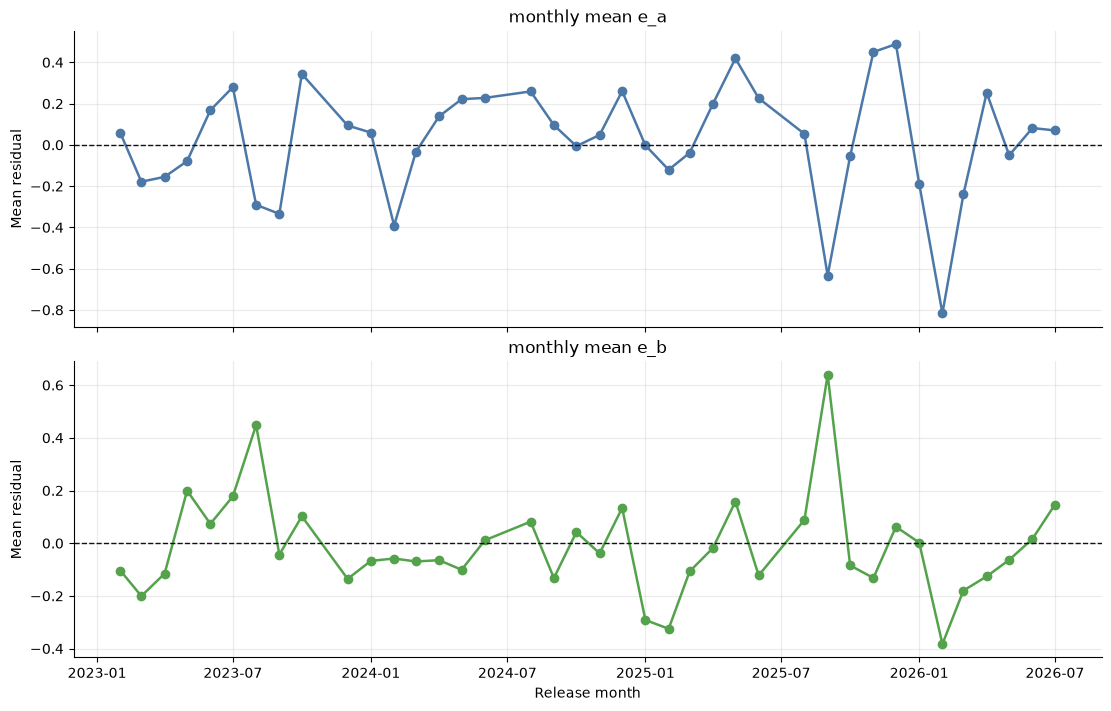

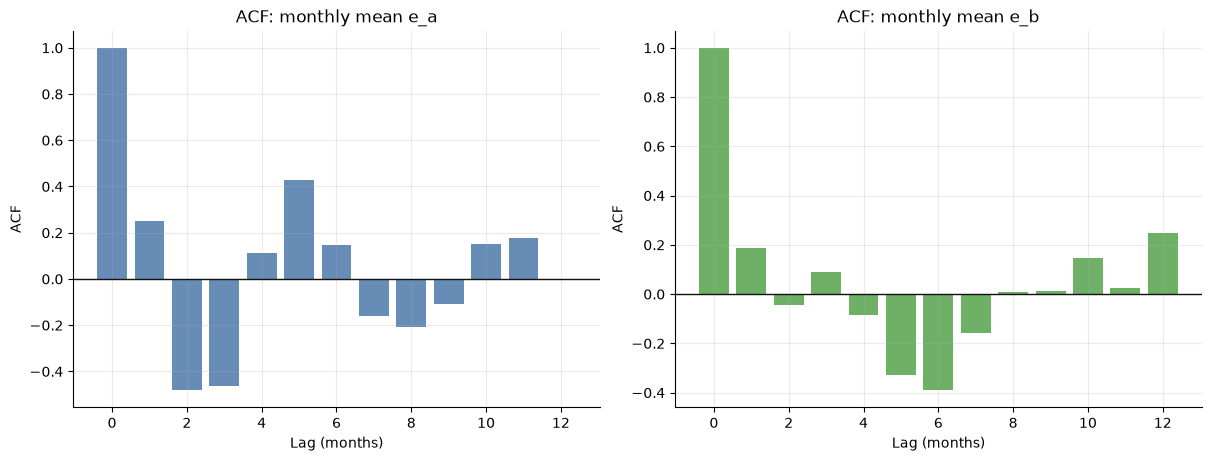

,release_month_period,n_movies,mean_e_a,mean_e_b
0,2023-02-01,5,0.057817,-0.103869
1,2023-03-01,2,-0.178714,-0.200606
2,2023-04-01,4,-0.155035,-0.115541
3,2023-05-01,3,-0.078803,0.199474
4,2023-06-01,3,0.167762,0.073408
5,2023-07-01,1,0.279749,0.177821
6,2023-08-01,2,-0.290446,0.448260
7,2023-09-01,2,-0.334558,-0.043266
8,2023-10-01,2,0.343591,0.102082
9,2023-12-01,7,0.093899,-0.135391


,lag,n,ljung_box_q,p_value,residual
0,6,39,32.339657,0.000014,mean_e_a
1,12,39,39.626929,0.000083,mean_e_a
2,6,39,14.734114,0.022429,mean_e_b
3,12,39,20.822327,0.053044,mean_e_b


In [130]:
if "shape_prior_diag" not in globals() or shape_prior_diag.empty:
    raise RuntimeError("Run the frozen baseline diagnostics block before this monthly clustering block.")

monthly_residuals = (
    shape_prior_diag.assign(release_month_period=shape_prior_diag["opening_weekend_start"].dt.to_period("M").dt.to_timestamp())
    .groupby("release_month_period")
    .agg(
        n_movies=("release_run_id", "count"),
        mean_e_a=("log_fri_sat_error", "mean"),
        mean_e_b=("log_sun_sat_error", "mean"),
    )
    .reset_index()
    .sort_values("release_month_period")
)

def acf_values(series, nlags=12):
    values = pd.to_numeric(pd.Series(series), errors="coerce").dropna().to_numpy(dtype=float)
    values = values - values.mean()
    denom = np.dot(values, values)
    rows = []
    for lag in range(nlags + 1):
        if lag == 0:
            acf = 1.0
        elif len(values) <= lag or denom == 0:
            acf = np.nan
        else:
            acf = np.dot(values[:-lag], values[lag:]) / denom
        rows.append({"lag": lag, "acf": acf})
    return pd.DataFrame(rows)

try:
    from scipy.stats import chi2
except Exception:
    chi2 = None


def ljung_box(series, lags=(6, 12)):
    values = pd.to_numeric(pd.Series(series), errors="coerce").dropna().to_numpy(dtype=float)
    n = len(values)
    acf_df = acf_values(values, nlags=max(lags)).set_index("lag")
    rows = []
    for lag in lags:
        usable = acf_df.loc[1:lag, "acf"].dropna()
        q = n * (n + 2) * sum((usable.loc[k] ** 2) / (n - k) for k in usable.index if n > k)
        p_value = 1 - chi2.cdf(q, df=lag) if chi2 is not None and np.isfinite(q) else np.nan
        rows.append({"lag": lag, "n": n, "ljung_box_q": q, "p_value": p_value})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)
for ax, col, label, color in [
    (axes[0], "mean_e_a", "monthly mean e_a", "#4c78a8"),
    (axes[1], "mean_e_b", "monthly mean e_b", "#54a24b"),
]:
    ax.plot(monthly_residuals["release_month_period"], monthly_residuals[col], marker="o", linewidth=1.8, color=color)
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_title(label)
    ax.set_ylabel("Mean residual")
axes[1].set_xlabel("Release month")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, col, title, color in [
    (axes[0], "mean_e_a", "ACF: monthly mean e_a", "#4c78a8"),
    (axes[1], "mean_e_b", "ACF: monthly mean e_b", "#54a24b"),
]:
    acf_df = acf_values(monthly_residuals[col], nlags=12)
    ax.bar(acf_df["lag"], acf_df["acf"], color=color, alpha=0.85)
    ax.axhline(0, color="#111111", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("ACF")
plt.show()

ljung_box_summary = pd.concat(
    [
        ljung_box(monthly_residuals["mean_e_a"]).assign(residual="mean_e_a"),
        ljung_box(monthly_residuals["mean_e_b"]).assign(residual="mean_e_b"),
    ],
    ignore_index=True,
)

display(monthly_residuals)
display(ljung_box_summary)


## Monthly Residual Robustness Checks

These checks stress-test the monthly residual autocorrelation result before interpreting it as a real time pattern: weighted monthly Ljung-Box, sparse-month exclusions, quarterly aggregation, excluding 2025, and broad calendar corridors.

,lag,n_periods,effective_n,ljung_box_q,p_value,residual,diagnostic,weight_by_n,min_month_n
0,6,39,39.000000,32.339657,0.000014,mean_e_a,monthly_unweighted,False,1
1,12,39,39.000000,39.626929,0.000083,mean_e_a,monthly_unweighted,False,1
2,6,39,39.000000,14.734114,0.022429,mean_e_b,monthly_unweighted,False,1
3,12,39,39.000000,20.822327,0.053044,mean_e_b,monthly_unweighted,False,1
4,6,39,25.004566,17.195565,0.008591,mean_e_a,monthly_weighted_by_movie_count,True,1
5,12,39,25.004566,22.159484,0.035771,mean_e_a,monthly_weighted_by_movie_count,True,1
6,6,39,25.004566,10.117951,0.119772,mean_e_b,monthly_weighted_by_movie_count,True,1
7,12,39,25.004566,17.212651,0.141772,mean_e_b,monthly_weighted_by_movie_count,True,1
8,6,25,25.000000,15.906649,0.014264,mean_e_a,monthly_min_n_3,False,3
9,12,25,25.000000,19.963036,0.067788,mean_e_a,monthly_min_n_3,False,3


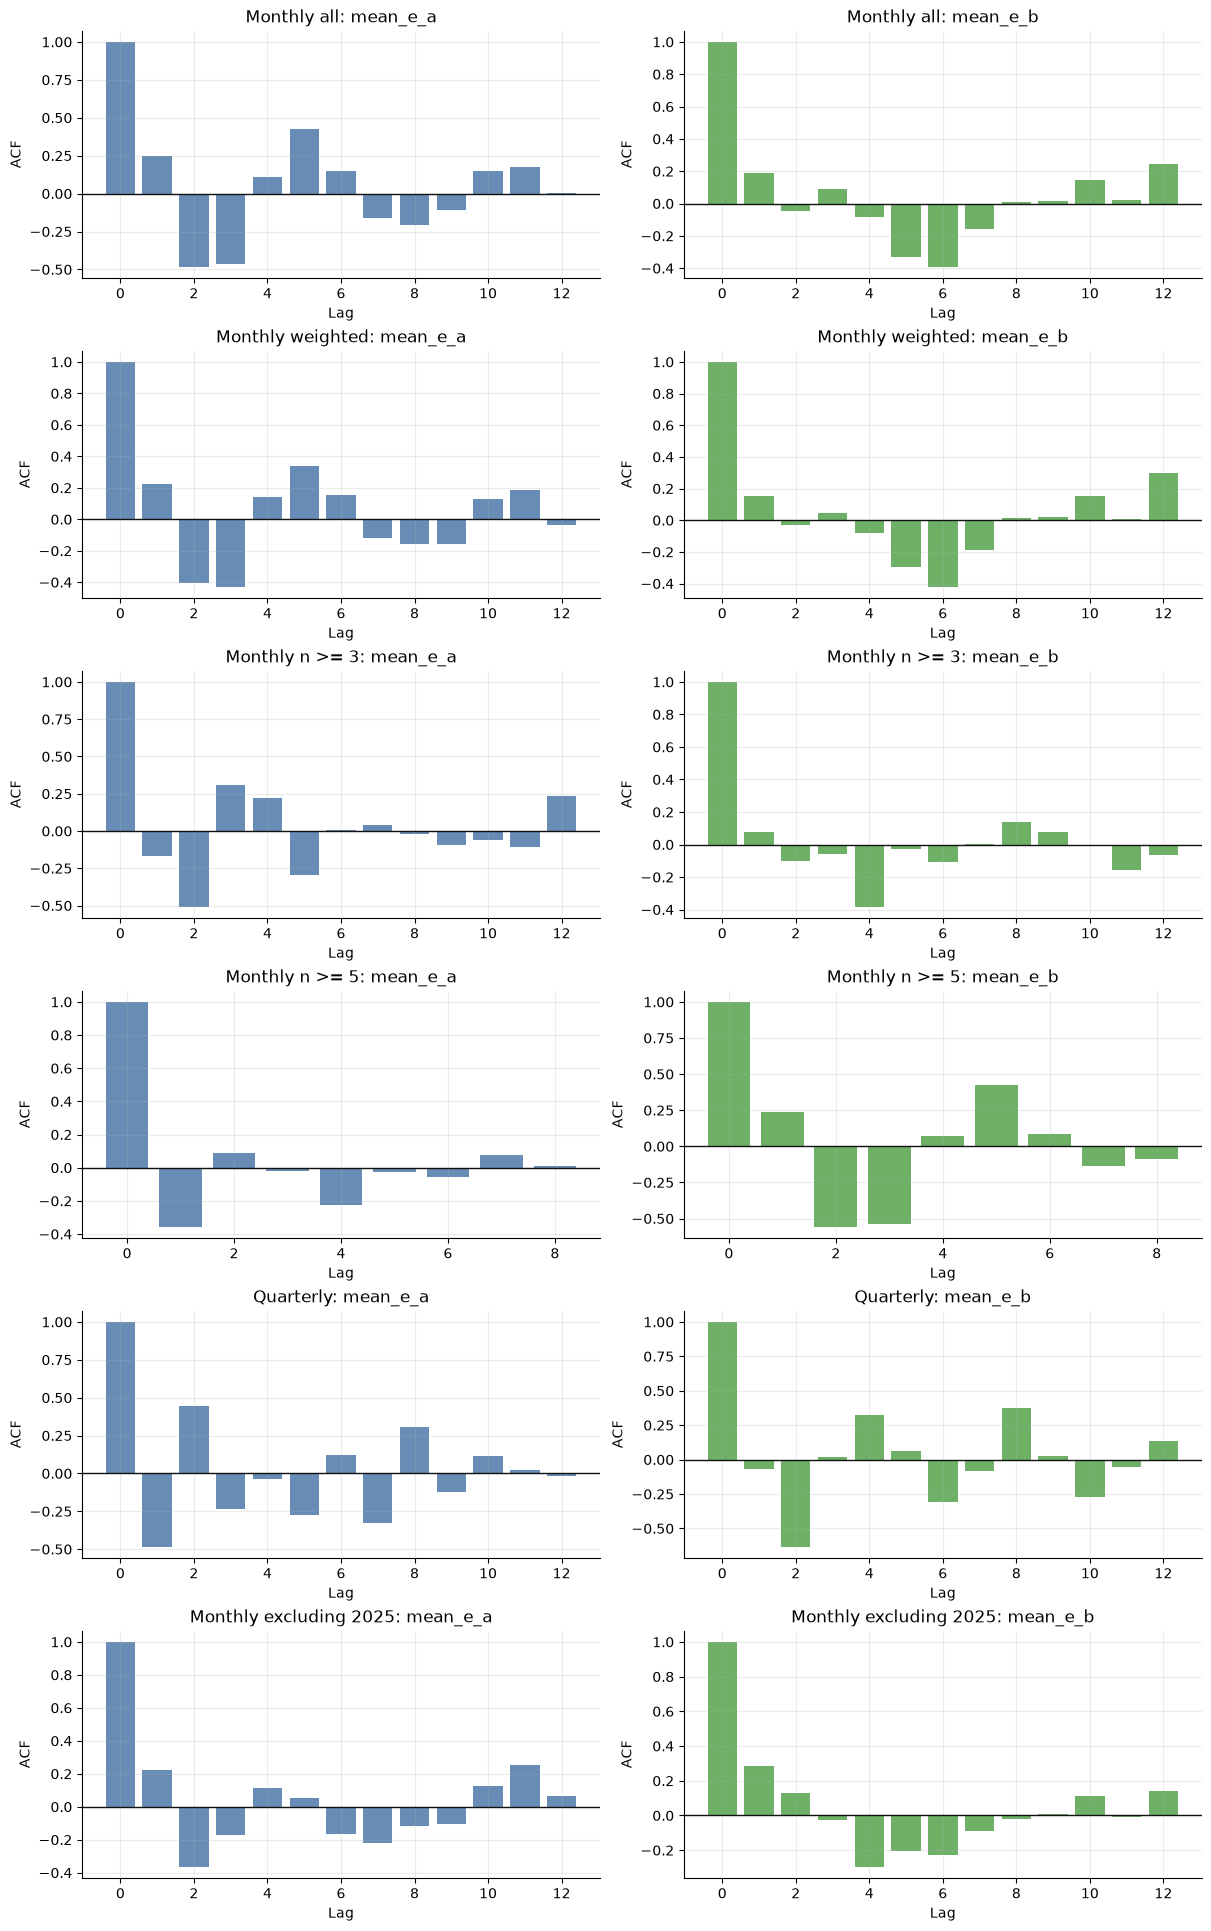

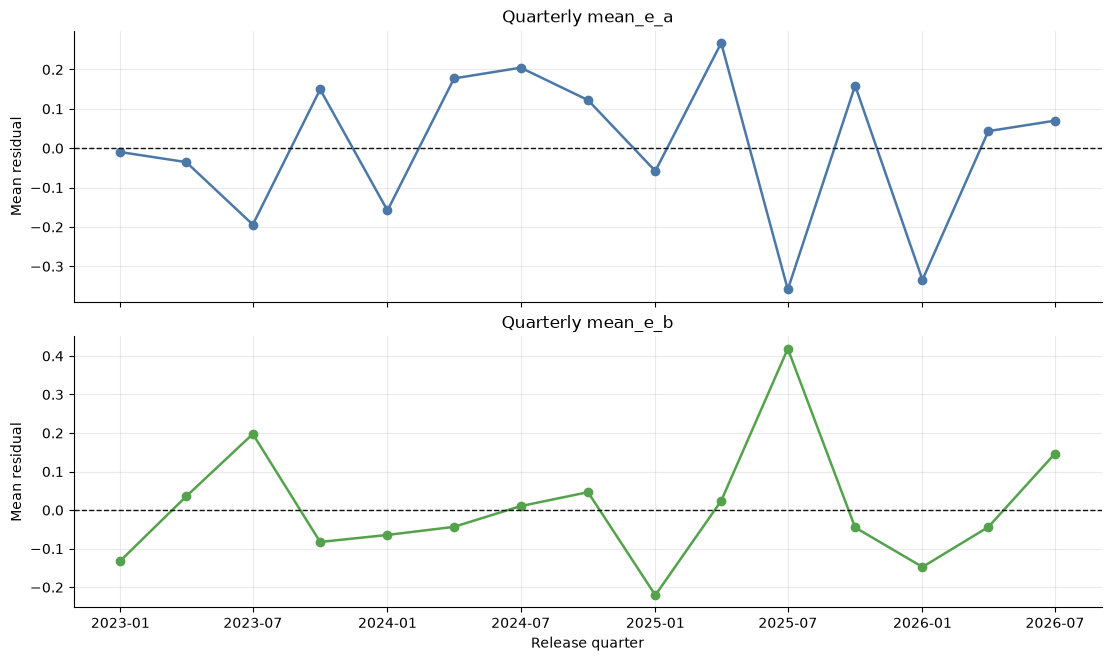

,test_year,calendar_corridor,n,mean_e_a,mean_e_b,mae_e_a,mae_e_b
0,2023,fall,4,0.004516,0.029408,0.339074,0.113788
5,2024,fall,5,0.055022,-0.062540,0.107043,0.096335
10,2025,fall,9,-0.247233,0.156835,0.471286,0.370844
1,2023,holiday,7,0.093899,-0.135391,0.305005,0.269069
6,2024,holiday,8,0.154345,0.047608,0.507308,0.107045
11,2025,holiday,4,0.478672,0.013753,0.574647,0.120035
2,2023,ordinary,5,0.057817,-0.103869,0.428420,0.114794
7,2024,ordinary,7,-0.258113,-0.037401,0.292137,0.096517
12,2025,ordinary,5,-0.073359,-0.311459,0.196046,0.337199
15,2026,ordinary,6,-0.397323,-0.125920,0.504950,0.138730


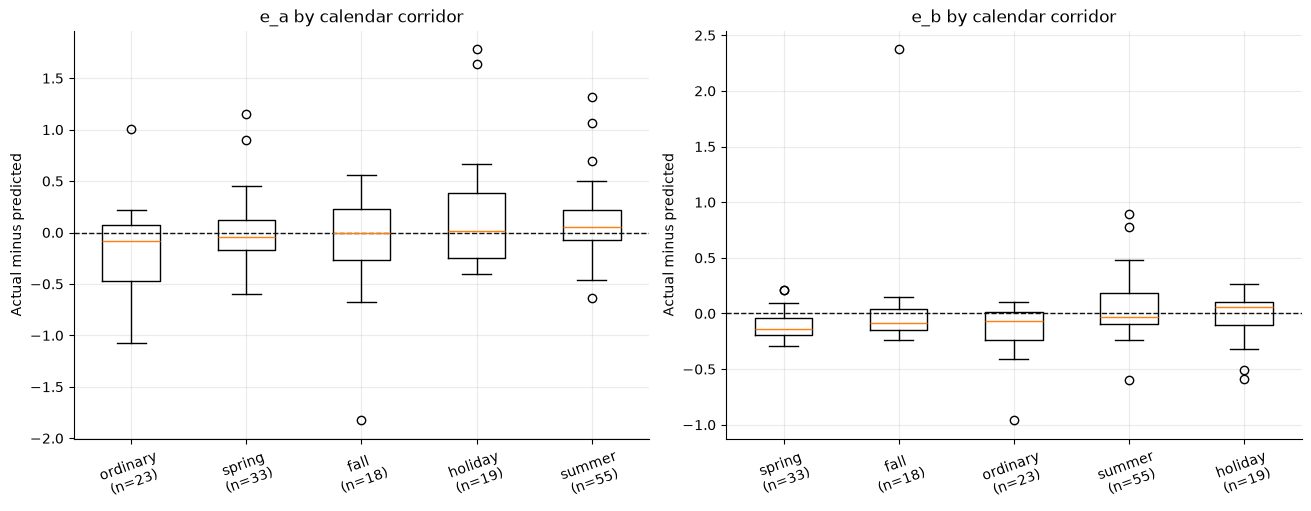

In [131]:
if "shape_prior_diag" not in globals() or shape_prior_diag.empty:
    raise RuntimeError("Run the frozen baseline diagnostics block before this robustness block.")


def weighted_acf_values(values, weights=None, nlags=12):
    x = pd.to_numeric(pd.Series(values), errors="coerce")
    if weights is None:
        w = pd.Series(1.0, index=x.index)
    else:
        w = pd.to_numeric(pd.Series(weights, index=x.index), errors="coerce")
    mask = x.notna() & w.notna() & w.gt(0)
    x = x.loc[mask].to_numpy(dtype=float)
    w = w.loc[mask].to_numpy(dtype=float)
    if len(x) == 0:
        return pd.DataFrame({"lag": range(nlags + 1), "acf": [np.nan] * (nlags + 1)})
    mean = np.average(x, weights=w)
    centered = x - mean
    denom = np.sum(w * centered * centered)
    rows = []
    for lag in range(nlags + 1):
        if lag == 0:
            acf = 1.0
        elif len(x) <= lag or denom == 0:
            acf = np.nan
        else:
            pair_w = np.sqrt(w[:-lag] * w[lag:])
            acf = np.sum(pair_w * centered[:-lag] * centered[lag:]) / denom
        rows.append({"lag": lag, "acf": acf})
    return pd.DataFrame(rows)


def weighted_ljung_box(values, weights=None, lags=(6, 12)):
    x = pd.to_numeric(pd.Series(values), errors="coerce")
    if weights is None:
        w = pd.Series(1.0, index=x.index)
    else:
        w = pd.to_numeric(pd.Series(weights, index=x.index), errors="coerce")
    mask = x.notna() & w.notna() & w.gt(0)
    n = int(mask.sum())
    effective_n = (w.loc[mask].sum() ** 2 / np.square(w.loc[mask]).sum()) if n else np.nan
    acf_df = weighted_acf_values(x.loc[mask], w.loc[mask], nlags=max(lags)).set_index("lag")
    rows = []
    for lag in lags:
        usable = acf_df.loc[1:lag, "acf"].dropna()
        q = effective_n * (effective_n + 2) * sum((usable.loc[k] ** 2) / (effective_n - k) for k in usable.index if effective_n > k)
        p_value = 1 - chi2.cdf(q, df=lag) if chi2 is not None and np.isfinite(q) else np.nan
        rows.append({"lag": lag, "n_periods": n, "effective_n": effective_n, "ljung_box_q": q, "p_value": p_value})
    return pd.DataFrame(rows)


def residual_period_table(df, freq="M", exclude_years=None):
    working = df.copy()
    if exclude_years:
        working = working.loc[~working["test_year"].isin(exclude_years)].copy()
    period_col = "release_period"
    working[period_col] = working["opening_weekend_start"].dt.to_period(freq).dt.to_timestamp()
    return (
        working.groupby(period_col)
        .agg(
            n_movies=("release_run_id", "count"),
            mean_e_a=("log_fri_sat_error", "mean"),
            mean_e_b=("log_sun_sat_error", "mean"),
        )
        .reset_index()
        .sort_values(period_col)
    )


def period_diagnostic_summary(table, label, weight_by_n=False, min_n=1, nlags=12):
    filtered = table.loc[table["n_movies"].ge(min_n)].copy()
    weights = filtered["n_movies"] if weight_by_n else None
    rows = []
    for residual_col in ["mean_e_a", "mean_e_b"]:
        lb = weighted_ljung_box(filtered[residual_col], weights=weights, lags=(min(6, max(1, len(filtered) - 1)), min(12, max(1, len(filtered) - 1))))
        lb["residual"] = residual_col
        lb["diagnostic"] = label
        lb["weight_by_n"] = weight_by_n
        lb["min_month_n"] = min_n
        rows.append(lb)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

monthly_all = residual_period_table(shape_prior_diag, freq="M")
quarterly_all = residual_period_table(shape_prior_diag, freq="Q")
monthly_ex_2025 = residual_period_table(shape_prior_diag, freq="M", exclude_years={2025})

robust_ljung_box = pd.concat(
    [
        period_diagnostic_summary(monthly_all, "monthly_unweighted", weight_by_n=False, min_n=1),
        period_diagnostic_summary(monthly_all, "monthly_weighted_by_movie_count", weight_by_n=True, min_n=1),
        period_diagnostic_summary(monthly_all, "monthly_min_n_3", weight_by_n=False, min_n=3),
        period_diagnostic_summary(monthly_all, "monthly_min_n_5", weight_by_n=False, min_n=5),
        period_diagnostic_summary(quarterly_all, "quarterly_unweighted", weight_by_n=False, min_n=1, nlags=8),
        period_diagnostic_summary(quarterly_all, "quarterly_weighted_by_movie_count", weight_by_n=True, min_n=1, nlags=8),
        period_diagnostic_summary(monthly_ex_2025, "monthly_excluding_2025", weight_by_n=False, min_n=1),
        period_diagnostic_summary(monthly_ex_2025, "monthly_excluding_2025_weighted", weight_by_n=True, min_n=1),
    ],
    ignore_index=True,
)
display(robust_ljung_box)

# ACF plots for sparse-month filters and quarterly residuals.
acf_cases = [
    ("Monthly all", monthly_all, 1, False),
    ("Monthly weighted", monthly_all, 1, True),
    ("Monthly n >= 3", monthly_all, 3, False),
    ("Monthly n >= 5", monthly_all, 5, False),
    ("Quarterly", quarterly_all, 1, False),
    ("Monthly excluding 2025", monthly_ex_2025, 1, False),
]

fig, axes = plt.subplots(len(acf_cases), 2, figsize=(12, 3.2 * len(acf_cases)), constrained_layout=True)
for row_idx, (case_label, table, min_n, weighted) in enumerate(acf_cases):
    filtered = table.loc[table["n_movies"].ge(min_n)].copy()
    weights = filtered["n_movies"] if weighted else None
    for col_idx, (residual_col, color) in enumerate([("mean_e_a", "#4c78a8"), ("mean_e_b", "#54a24b")]):
        acf_df = weighted_acf_values(filtered[residual_col], weights=weights, nlags=min(12, max(1, len(filtered) - 1)))
        ax = axes[row_idx, col_idx]
        ax.bar(acf_df["lag"], acf_df["acf"], color=color, alpha=0.85)
        ax.axhline(0, color="#111111", linewidth=1)
        ax.set_title(f"{case_label}: {residual_col}")
        ax.set_xlabel("Lag")
        ax.set_ylabel("ACF")
plt.show()

# Quarterly residual mean time plot.
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, constrained_layout=True)
for ax, residual_col, color in [(axes[0], "mean_e_a", "#4c78a8"), (axes[1], "mean_e_b", "#54a24b")]:
    ax.plot(quarterly_all["release_period"], quarterly_all[residual_col], marker="o", linewidth=1.8, color=color)
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_title(f"Quarterly {residual_col}")
    ax.set_ylabel("Mean residual")
axes[1].set_xlabel("Release quarter")
plt.show()

# Calendar corridor residuals.
def calendar_corridor(row):
    month = int(row["release_month"])
    if row.get("season_bucket") == "holiday" or month in [11, 12]:
        return "holiday"
    if month in [5, 6, 7, 8]:
        return "summer"
    if month in [9, 10]:
        return "fall"
    if month in [3, 4]:
        return "spring"
    return "ordinary"

corridor_diag = shape_prior_diag.copy()
corridor_diag["calendar_corridor"] = corridor_diag.apply(calendar_corridor, axis=1)

corridor_summary = (
    corridor_diag.groupby(["test_year", "calendar_corridor"], observed=False)
    .agg(
        n=("release_run_id", "count"),
        mean_e_a=("log_fri_sat_error", "mean"),
        mean_e_b=("log_sun_sat_error", "mean"),
        mae_e_a=("log_fri_sat_error", lambda s: s.abs().mean()),
        mae_e_b=("log_sun_sat_error", lambda s: s.abs().mean()),
    )
    .reset_index()
    .sort_values(["calendar_corridor", "test_year"])
)
display(corridor_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, residual_col, title, color in [
    (axes[0], "log_fri_sat_error", "e_a by calendar corridor", "#4c78a8"),
    (axes[1], "log_sun_sat_error", "e_b by calendar corridor", "#54a24b"),
]:
    order = corridor_diag.groupby("calendar_corridor")[residual_col].median().sort_values().index.tolist()
    data = []
    labels = []
    for corridor in order:
        values = corridor_diag.loc[corridor_diag["calendar_corridor"].eq(corridor), residual_col].dropna()
        data.append(values)
        labels.append(f"{corridor}\n(n={len(values)})")
    ax.boxplot(data, tick_labels=labels, showfliers=True)
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("Actual minus predicted")
    ax.tick_params(axis="x", rotation=20)
plt.show()


## Final Baseline Freeze Checks

This section freezes the baseline stack, audits leakage controls, keeps only the frozen-model comparison table, and records the residual caveat and predictor-improvement hurdle before moving on.

,component,frozen_model,estimated_from,audit_status,detail
0,Historical shape profiles,refine_window_last5y_broad_direct_median_grid_...,training releases with release_year < test_yea...,PASS,fold present=True; release_year == test_year=T...
1,Shape-prior grid calibration constants,refine_window_last5y_broad_direct_median_grid_...,prior rolling validation residuals inside each...,PASS,positive calibration residual counts=True; fol...
2,After-Friday nowcast profile,nowcast_after_friday_share_inversion,training releases with release_year < test_yea...,PASS,fold present=True; release_year == test_year=T...
3,After-Saturday log-bias constant and residual ...,nowcast_after_saturday_ratio_segment_ip_doc_lo...,prior chronological nowcast residuals inside e...,PASS,positive calibration residual counts=True; fol...
4,Prediction intervals,nowcast calibrated interval rows,residual quantiles from prior nowcast residual...,PASS,interval quantiles are generated by nowcast_ca...


,layer,model,primary_metric,primary_metric_value,secondary_metrics
0,Demoted old baseline,benchmark_1_broad_direct_logratio_calibrated,shape-only avg daily dollar MAE,695373.0,MAE log(Fri/Sat)=0.333; MAE log(Sun/Sat)=0.173
1,Benchmark reference,benchmark_0_global_direct,shape-only avg daily dollar MAE,767018.0,MAE log(Fri/Sat)=0.357; MAE log(Sun/Sat)=0.181
2,WeekendShapePrior_v1,refine_window_last5y_broad_direct_median_grid_...,shape-only avg daily dollar MAE,497748.0,MAE log(Fri/Sat)=0.287; MAE log(Sun/Sat)=0.171
3,AfterFridayNowcast_v1,nowcast_after_friday_share_inversion,after-Friday OW MAE,2567403.0,remaining daily MAE=1312298; OW MAE=2567403
4,AfterSaturdayNowcast_v1,nowcast_after_saturday_ratio_segment_ip_doc_lo...,after-Saturday Sunday/OW MAE,541997.0,remaining daily MAE=541997; OW MAE=541997


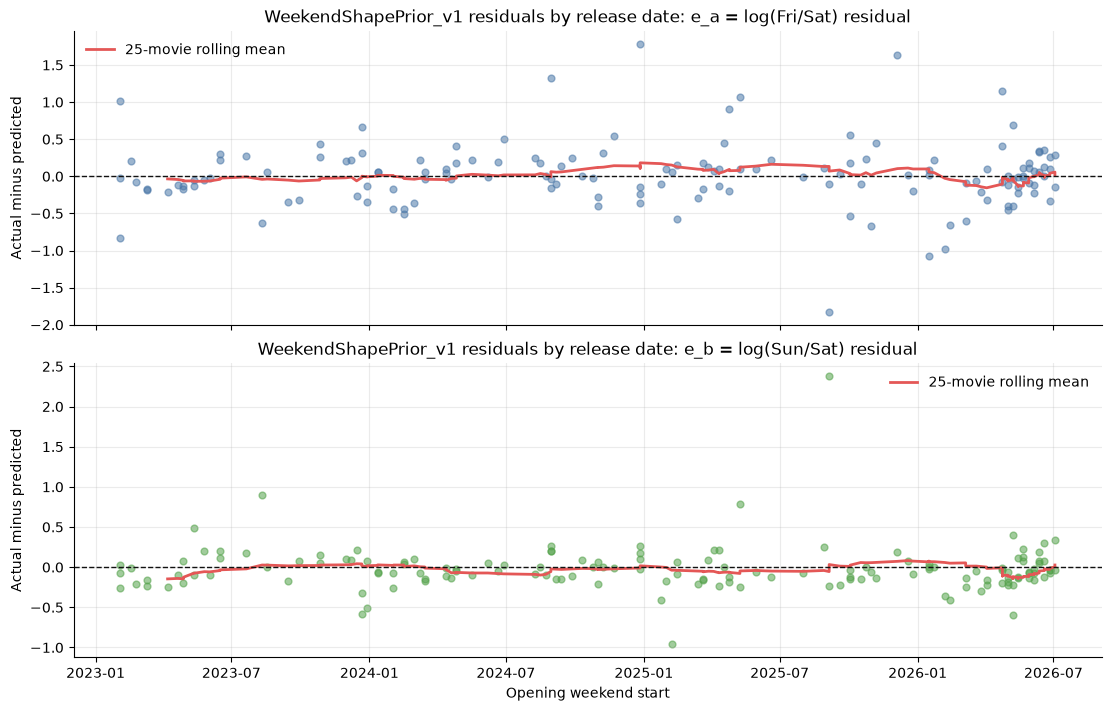

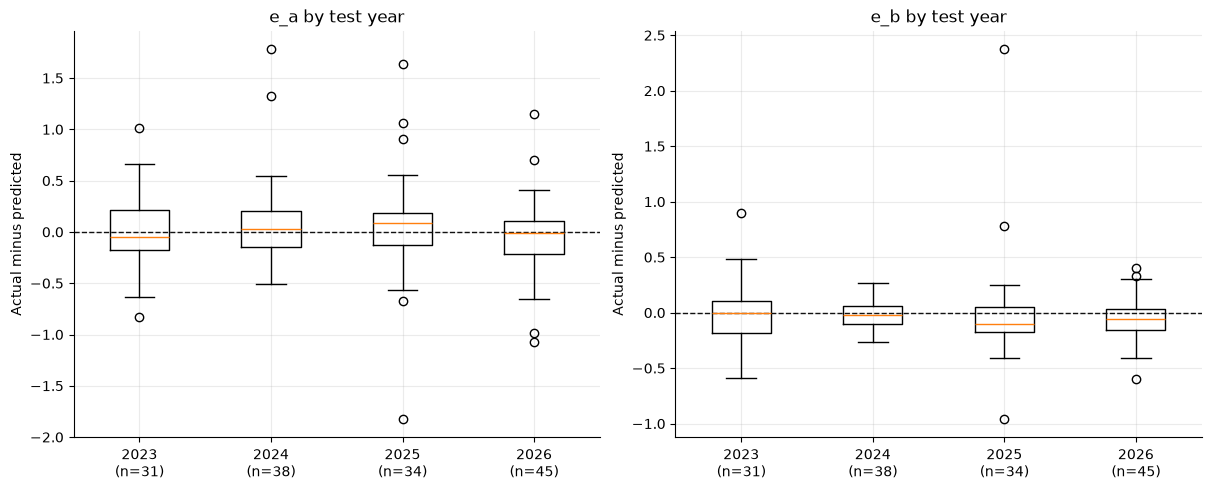

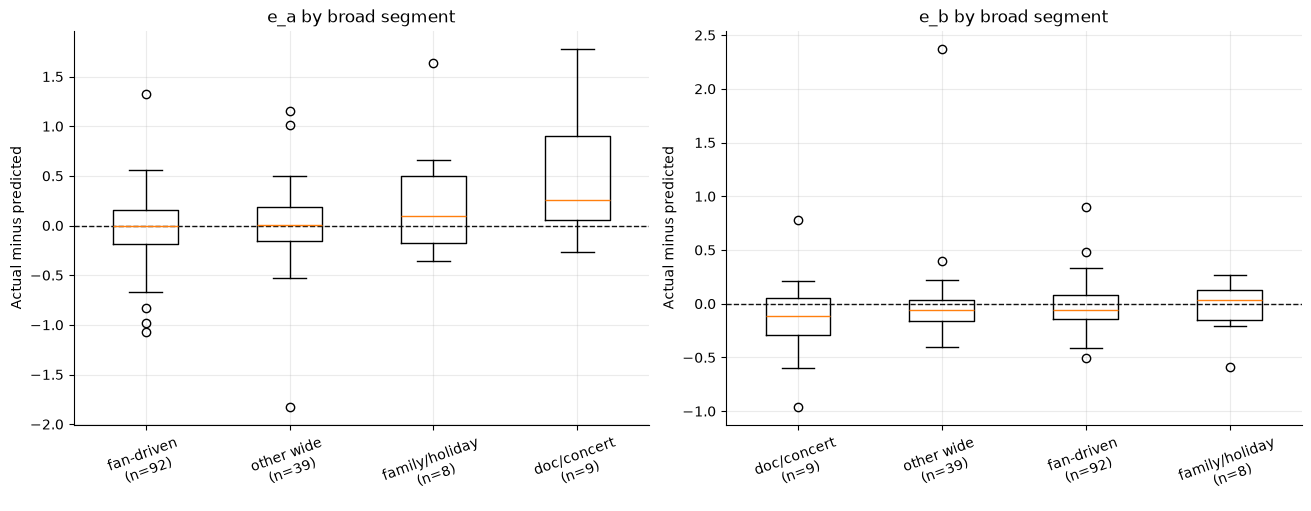

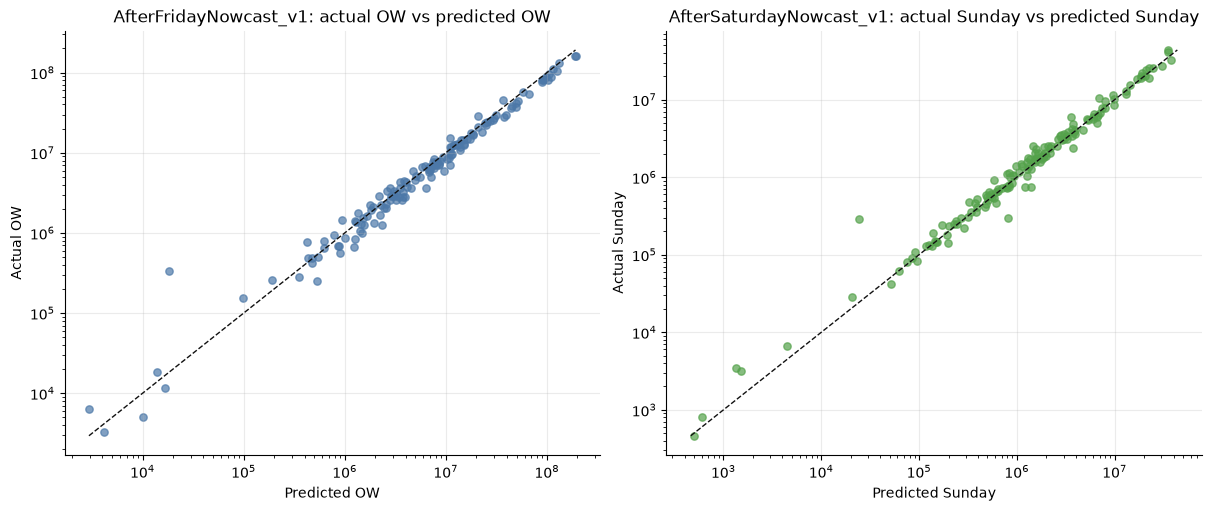

**Residual Caveat**

Monthly autocorrelation in e_a appears in the full monthly series, but it disappears when excluding 2025 and weakens under sparse-cell filtering. Because the pattern is not stable across years or corridors, it is treated as a diagnostic caveat rather than a reason to add another baseline adjustment.

**Predictor-Variable Improvement Hurdle**

,forecast_layer,minimum_improvement_to_keep,primary_metrics,interval_requirement
0,Shape prior,5% vs WeekendShapePrior_v1,"MAE(log(Fri/Sat)), MAE(log(Sun/Sat)), avg dail...",must not hurt interval calibration
1,After Friday,5% vs AfterFridayNowcast_v1,MAE(OW_afterFriday),must not hurt interval calibration
2,After Saturday,5% vs AfterSaturdayNowcast_v1,"MAE(Sunday), MAE(OW_afterSaturday)",must not hurt interval calibration


In [132]:
from IPython.display import Markdown

FROZEN_MODEL_NAMES = {
    "benchmark_reference": "benchmark_0_global_direct",
    "demoted_old_baseline": "benchmark_1_broad_direct_logratio_calibrated",
    "shape_prior_v1": "refine_window_last5y_broad_direct_median_grid_calibrated",
    "after_friday_v1": "nowcast_after_friday_share_inversion",
    "after_saturday_v1": "nowcast_after_saturday_ratio_segment_ip_doc_log_bias_calibrated",
}

required_globals = [
    "shape_cv", "refinement_cv", "combined_nowcast_summary", "nowcast_cv", "nowcast_calibrated_cv",
    "shape_prior_diag", "robust_ljung_box", "corridor_summary",
]
missing = [name for name in required_globals if name not in globals()]
if missing:
    raise RuntimeError(f"Run earlier baseline/diagnostic blocks first. Missing: {missing}")

# Leakage audit: row-level guards plus method audit of the rolling-origin functions used above.
def check_release_year_alignment(df, name):
    if df.empty:
        return False, f"{name} is empty"
    has_fold = df["fold"].notna().all() if "fold" in df.columns else False
    year_match = df["release_year"].astype(int).eq(df["test_year"].astype(int)).all() if {"release_year", "test_year"}.issubset(df.columns) else False
    return bool(has_fold and year_match), f"fold present={has_fold}; release_year == test_year={year_match}; rows={len(df):,}"

shape_ok, shape_detail = check_release_year_alignment(shape_cv, "shape_cv")
refine_ok, refine_detail = check_release_year_alignment(refinement_cv, "refinement_cv")
nowcast_ok, nowcast_detail = check_release_year_alignment(nowcast_cv, "nowcast_cv")
nowcast_cal_ok, nowcast_cal_detail = check_release_year_alignment(nowcast_calibrated_cv, "nowcast_calibrated_cv")

leakage_audit = pd.DataFrame(
    [
        {
            "component": "Historical shape profiles",
            "frozen_model": FROZEN_MODEL_NAMES["shape_prior_v1"],
            "estimated_from": "training releases with release_year < test_year; recent-window profile uses only those training rows",
            "audit_status": "PASS" if refine_ok else "CHECK",
            "detail": refine_detail,
        },
        {
            "component": "Shape-prior grid calibration constants",
            "frozen_model": FROZEN_MODEL_NAMES["shape_prior_v1"],
            "estimated_from": "prior rolling validation residuals inside each training fold, then applied to later test year",
            "audit_status": "PASS" if refine_ok and refinement_cv["calibration_residual_n"].gt(0).all() else "CHECK",
            "detail": f"positive calibration residual counts={refinement_cv['calibration_residual_n'].gt(0).all()}; {refine_detail}",
        },
        {
            "component": "After-Friday nowcast profile",
            "frozen_model": FROZEN_MODEL_NAMES["after_friday_v1"],
            "estimated_from": "training releases with release_year < test_year; Friday actual known only for the test movie at nowcast origin",
            "audit_status": "PASS" if nowcast_ok else "CHECK",
            "detail": nowcast_detail,
        },
        {
            "component": "After-Saturday log-bias constant and residual quantiles",
            "frozen_model": FROZEN_MODEL_NAMES["after_saturday_v1"],
            "estimated_from": "prior chronological nowcast residuals inside each training fold; logs use strictly positive actual/predicted targets only",
            "audit_status": "PASS" if nowcast_cal_ok and nowcast_calibrated_cv["calibration_residual_n"].gt(0).all() else "CHECK",
            "detail": f"positive calibration residual counts={nowcast_calibrated_cv['calibration_residual_n'].gt(0).all()}; {nowcast_cal_detail}",
        },
        {
            "component": "Prediction intervals",
            "frozen_model": "nowcast calibrated interval rows",
            "estimated_from": "residual quantiles from prior nowcast residuals inside each training fold, not from the test movie",
            "audit_status": "PASS" if nowcast_cal_ok else "CHECK",
            "detail": "interval quantiles are generated by nowcast_calibration_from_prior(train, spec) before each test-year prediction",
        },
    ]
)
display(leakage_audit)

if not leakage_audit["audit_status"].eq("PASS").all():
    raise AssertionError("Leakage audit has non-PASS rows; inspect leakage_audit before freezing.")

# Final frozen-model table only.
shape_summary_source = pd.concat([shape_summary, refinement_summary], ignore_index=True)
shape_rows = shape_summary_source.loc[
    shape_summary_source["model"].isin([
        FROZEN_MODEL_NAMES["benchmark_reference"],
        FROZEN_MODEL_NAMES["demoted_old_baseline"],
        FROZEN_MODEL_NAMES["shape_prior_v1"],
    ])
].copy()

shape_rows["layer"] = shape_rows["model"].map(
    {
        FROZEN_MODEL_NAMES["benchmark_reference"]: "Benchmark reference",
        FROZEN_MODEL_NAMES["demoted_old_baseline"]: "Demoted old baseline",
        FROZEN_MODEL_NAMES["shape_prior_v1"]: "WeekendShapePrior_v1",
    }
)
shape_rows["primary_metric"] = "shape-only avg daily dollar MAE"
shape_rows["primary_metric_value"] = shape_rows["avg_abs_daily_dollar_error"]
shape_rows["secondary_metrics"] = shape_rows.apply(
    lambda r: f"MAE log(Fri/Sat)={r['mae_log_fri_sat']:.3f}; MAE log(Sun/Sat)={r['mae_log_sun_sat']:.3f}",
    axis=1,
)

nowcast_frozen = combined_nowcast_summary.loc[
    combined_nowcast_summary["model"].isin([FROZEN_MODEL_NAMES["after_friday_v1"], FROZEN_MODEL_NAMES["after_saturday_v1"]])
].copy()
nowcast_frozen["layer"] = nowcast_frozen["model"].map(
    {
        FROZEN_MODEL_NAMES["after_friday_v1"]: "AfterFridayNowcast_v1",
        FROZEN_MODEL_NAMES["after_saturday_v1"]: "AfterSaturdayNowcast_v1",
    }
)
nowcast_frozen["primary_metric"] = np.where(
    nowcast_frozen["layer"].eq("AfterFridayNowcast_v1"),
    "after-Friday OW MAE",
    "after-Saturday Sunday/OW MAE",
)
nowcast_frozen["primary_metric_value"] = np.where(
    nowcast_frozen["layer"].eq("AfterFridayNowcast_v1"),
    nowcast_frozen["mae_opening_weekend"],
    nowcast_frozen["mae_sunday"],
)
nowcast_frozen["secondary_metrics"] = nowcast_frozen.apply(
    lambda r: f"remaining daily MAE={r['mae_remaining_daily']:.0f}; OW MAE={r['mae_opening_weekend']:.0f}",
    axis=1,
)

final_frozen_baseline_table = pd.concat(
    [
        shape_rows[["layer", "model", "primary_metric", "primary_metric_value", "secondary_metrics"]],
        nowcast_frozen[["layer", "model", "primary_metric", "primary_metric_value", "secondary_metrics"]],
    ],
    ignore_index=True,
)
final_frozen_baseline_table["primary_metric_value"] = final_frozen_baseline_table["primary_metric_value"].round(0)
display(final_frozen_baseline_table)

# Four final residual plots.
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)
ordered = shape_prior_diag.sort_values("opening_weekend_start")
for ax, residual_col, label, color in [
    (axes[0], "log_fri_sat_error", "e_a = log(Fri/Sat) residual", "#4c78a8"),
    (axes[1], "log_sun_sat_error", "e_b = log(Sun/Sat) residual", "#54a24b"),
]:
    ax.scatter(ordered["opening_weekend_start"], ordered[residual_col], s=24, alpha=0.55, color=color)
    ax.plot(ordered["opening_weekend_start"], ordered[residual_col].rolling(25, min_periods=8).mean(), color="#e45756", linewidth=2, label="25-movie rolling mean")
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_title(f"WeekendShapePrior_v1 residuals by release date: {label}")
    ax.set_ylabel("Actual minus predicted")
    ax.legend(frameon=False)
axes[1].set_xlabel("Opening weekend start")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
for ax, residual_col, title in [(axes[0], "log_fri_sat_error", "e_a by test year"), (axes[1], "log_sun_sat_error", "e_b by test year")]:
    years = sorted(shape_prior_diag["test_year"].dropna().astype(int).unique())
    data = [shape_prior_diag.loc[shape_prior_diag["test_year"].eq(year), residual_col].dropna() for year in years]
    labels = [f"{year}\n(n={len(vals)})" for year, vals in zip(years, data)]
    ax.boxplot(data, tick_labels=labels, showfliers=True)
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("Actual minus predicted")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, residual_col, title in [(axes[0], "log_fri_sat_error", "e_a by broad segment"), (axes[1], "log_sun_sat_error", "e_b by broad segment")]:
    order = shape_prior_diag.groupby("broad_segment", observed=False)[residual_col].median().sort_values().index.tolist()
    data = [shape_prior_diag.loc[shape_prior_diag["broad_segment"].eq(group), residual_col].dropna() for group in order]
    labels = [f"{group}\n(n={len(vals)})" for group, vals in zip(order, data)]
    ax.boxplot(data, tick_labels=labels, showfliers=True)
    ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("Actual minus predicted")
    ax.tick_params(axis="x", rotation=20)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
after_friday_final = nowcast_cv.loc[nowcast_cv["model"].eq(FROZEN_MODEL_NAMES["after_friday_v1"])].copy()
after_friday_final = after_friday_final.loc[after_friday_final["pred_opening_weekend_gross"].gt(0) & after_friday_final["opening_weekend_gross_usd"].gt(0)]
axes[0].scatter(after_friday_final["pred_opening_weekend_gross"], after_friday_final["opening_weekend_gross_usd"], s=28, alpha=0.7, color="#4c78a8")
lo = min(after_friday_final["pred_opening_weekend_gross"].min(), after_friday_final["opening_weekend_gross_usd"].min())
hi = max(after_friday_final["pred_opening_weekend_gross"].max(), after_friday_final["opening_weekend_gross_usd"].max())
axes[0].plot([lo, hi], [lo, hi], color="#111111", linestyle="--", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("AfterFridayNowcast_v1: actual OW vs predicted OW")
axes[0].set_xlabel("Predicted OW")
axes[0].set_ylabel("Actual OW")

after_saturday_final = nowcast_calibrated_cv.loc[nowcast_calibrated_cv["model"].eq(FROZEN_MODEL_NAMES["after_saturday_v1"])].copy()
after_saturday_final = after_saturday_final.loc[after_saturday_final["pred_sunday_gross"].gt(0) & after_saturday_final["sunday_gross_usd"].gt(0)]
axes[1].scatter(after_saturday_final["pred_sunday_gross"], after_saturday_final["sunday_gross_usd"], s=28, alpha=0.7, color="#54a24b")
lo = min(after_saturday_final["pred_sunday_gross"].min(), after_saturday_final["sunday_gross_usd"].min())
hi = max(after_saturday_final["pred_sunday_gross"].max(), after_saturday_final["sunday_gross_usd"].max())
axes[1].plot([lo, hi], [lo, hi], color="#111111", linestyle="--", linewidth=1)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("AfterSaturdayNowcast_v1: actual Sunday vs predicted Sunday")
axes[1].set_xlabel("Predicted Sunday")
axes[1].set_ylabel("Actual Sunday")
plt.show()

residual_caveat = (
    "Monthly autocorrelation in e_a appears in the full monthly series, but it disappears when excluding 2025 "
    "and weakens under sparse-cell filtering. Because the pattern is not stable across years or corridors, it is "
    "treated as a diagnostic caveat rather than a reason to add another baseline adjustment."
)

predictor_hurdle = pd.DataFrame(
    [
        {"forecast_layer": "Shape prior", "minimum_improvement_to_keep": "5% vs WeekendShapePrior_v1", "primary_metrics": "MAE(log(Fri/Sat)), MAE(log(Sun/Sat)), avg daily dollar error", "interval_requirement": "must not hurt interval calibration"},
        {"forecast_layer": "After Friday", "minimum_improvement_to_keep": "5% vs AfterFridayNowcast_v1", "primary_metrics": "MAE(OW_afterFriday)", "interval_requirement": "must not hurt interval calibration"},
        {"forecast_layer": "After Saturday", "minimum_improvement_to_keep": "5% vs AfterSaturdayNowcast_v1", "primary_metrics": "MAE(Sunday), MAE(OW_afterSaturday)", "interval_requirement": "must not hurt interval calibration"},
    ]
)

display(Markdown(f"**Residual Caveat**\n\n{residual_caveat}"))
display(Markdown("**Predictor-Variable Improvement Hurdle**"))
display(predictor_hurdle)
